# **Data Generators & Dataset Preparation**

In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------ Data Paths ------------------
BASE = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
TRAIN_DIR = os.path.join(BASE, "train")
TEST_DIR  = os.path.join(BASE, "test")
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists: ", os.path.exists(TEST_DIR))
print()

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

# ------------------ Generator Settings ------------------
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.20
)

test_datagen = ImageDataGenerator(rescale=1./255)

# ------------------ Generator ------------------
train_generator = train_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_generator = train_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")
print("\nClass indices (label -> index):")
print(train_generator.class_indices)

2025-12-09 16:09:53.672985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765296593.977370      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765296594.063504      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Train dir exists: True
Test dir exists:  True

Found 8723 images belonging to 6 classes.
Found 2178 images belonging to 6 classes.
Found 2698 images belonging to 6 classes.
Train samples: 8723
Validation samples: 2178
Test samples: 2698

Class indices (label -> index):
{'freshapples': 0, 'freshbanana': 1, 'freshoranges': 2, 'rottenapples': 3, 'rottenbanana': 4, 'rottenoranges': 5}


# **Dataset Class & Image Distribution**

In [2]:
import os
import pandas as pd

def folder_counts(path):
    """Return number of images per class and total image count."""
    if not os.path.exists(path):
        print(f"❌ Path does not exist: {path}")
        return {}, 0

    class_counts = {}
    total_images = 0

    # Only keep valid folders (exclude hidden/system files)
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)

        if os.path.isdir(cls_path):
            images = [
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            n_images = len(images)
            class_counts[cls] = n_images
            total_images += n_images

    return class_counts, total_images

# -------- Paths --------
TRAIN_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train"
TEST_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/test"

# -------- Get counts --------
train_counts, total_train = folder_counts(TRAIN_DIR)
test_counts, total_test   = folder_counts(TEST_DIR)

print("\n===== TRAINING SET SUMMARY =====")
print(f"Number of class folders: {len(train_counts)}")
print(f"Total training images: {total_train}\n")

display(pd.DataFrame(
    list(train_counts.items()),
    columns=["Class Name", "Image Count"]
))

print("\n===== TEST SET SUMMARY =====")
print(f"Number of class folders: {len(test_counts)}")
print(f"Total testing images: {total_test}\n")

display(pd.DataFrame(
    list(test_counts.items()),
    columns=["Class Name", "Image Count"]
))

# -------- Check for empty/missing class folders --------
empty_folders = [cls for cls, count in train_counts.items() if count == 0]

if empty_folders:
    print("⚠️ Warning: These training folders are empty:", empty_folders)
else:
    print("✔ All training class folders contain images.")

print(f"📊 TOTAL IMAGES IN DATASET (Train + Test): {total_train + total_test}")


===== TRAINING SET SUMMARY =====
Number of class folders: 6
Total training images: 10901



,Class Name,Image Count
0,freshapples,1693
1,freshbanana,1581
2,freshoranges,1466
3,rottenapples,2342
4,rottenbanana,2224
5,rottenoranges,1595



===== TEST SET SUMMARY =====
Number of class folders: 6
Total testing images: 2698



,Class Name,Image Count
0,freshapples,395
1,freshbanana,381
2,freshoranges,388
3,rottenapples,601
4,rottenbanana,530
5,rottenoranges,403


✔ All training class folders contain images.
📊 TOTAL IMAGES IN DATASET (Train + Test): 13599


# **Image Preprocessing Visualization**

Previewing 6 images (one per class) from /kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train



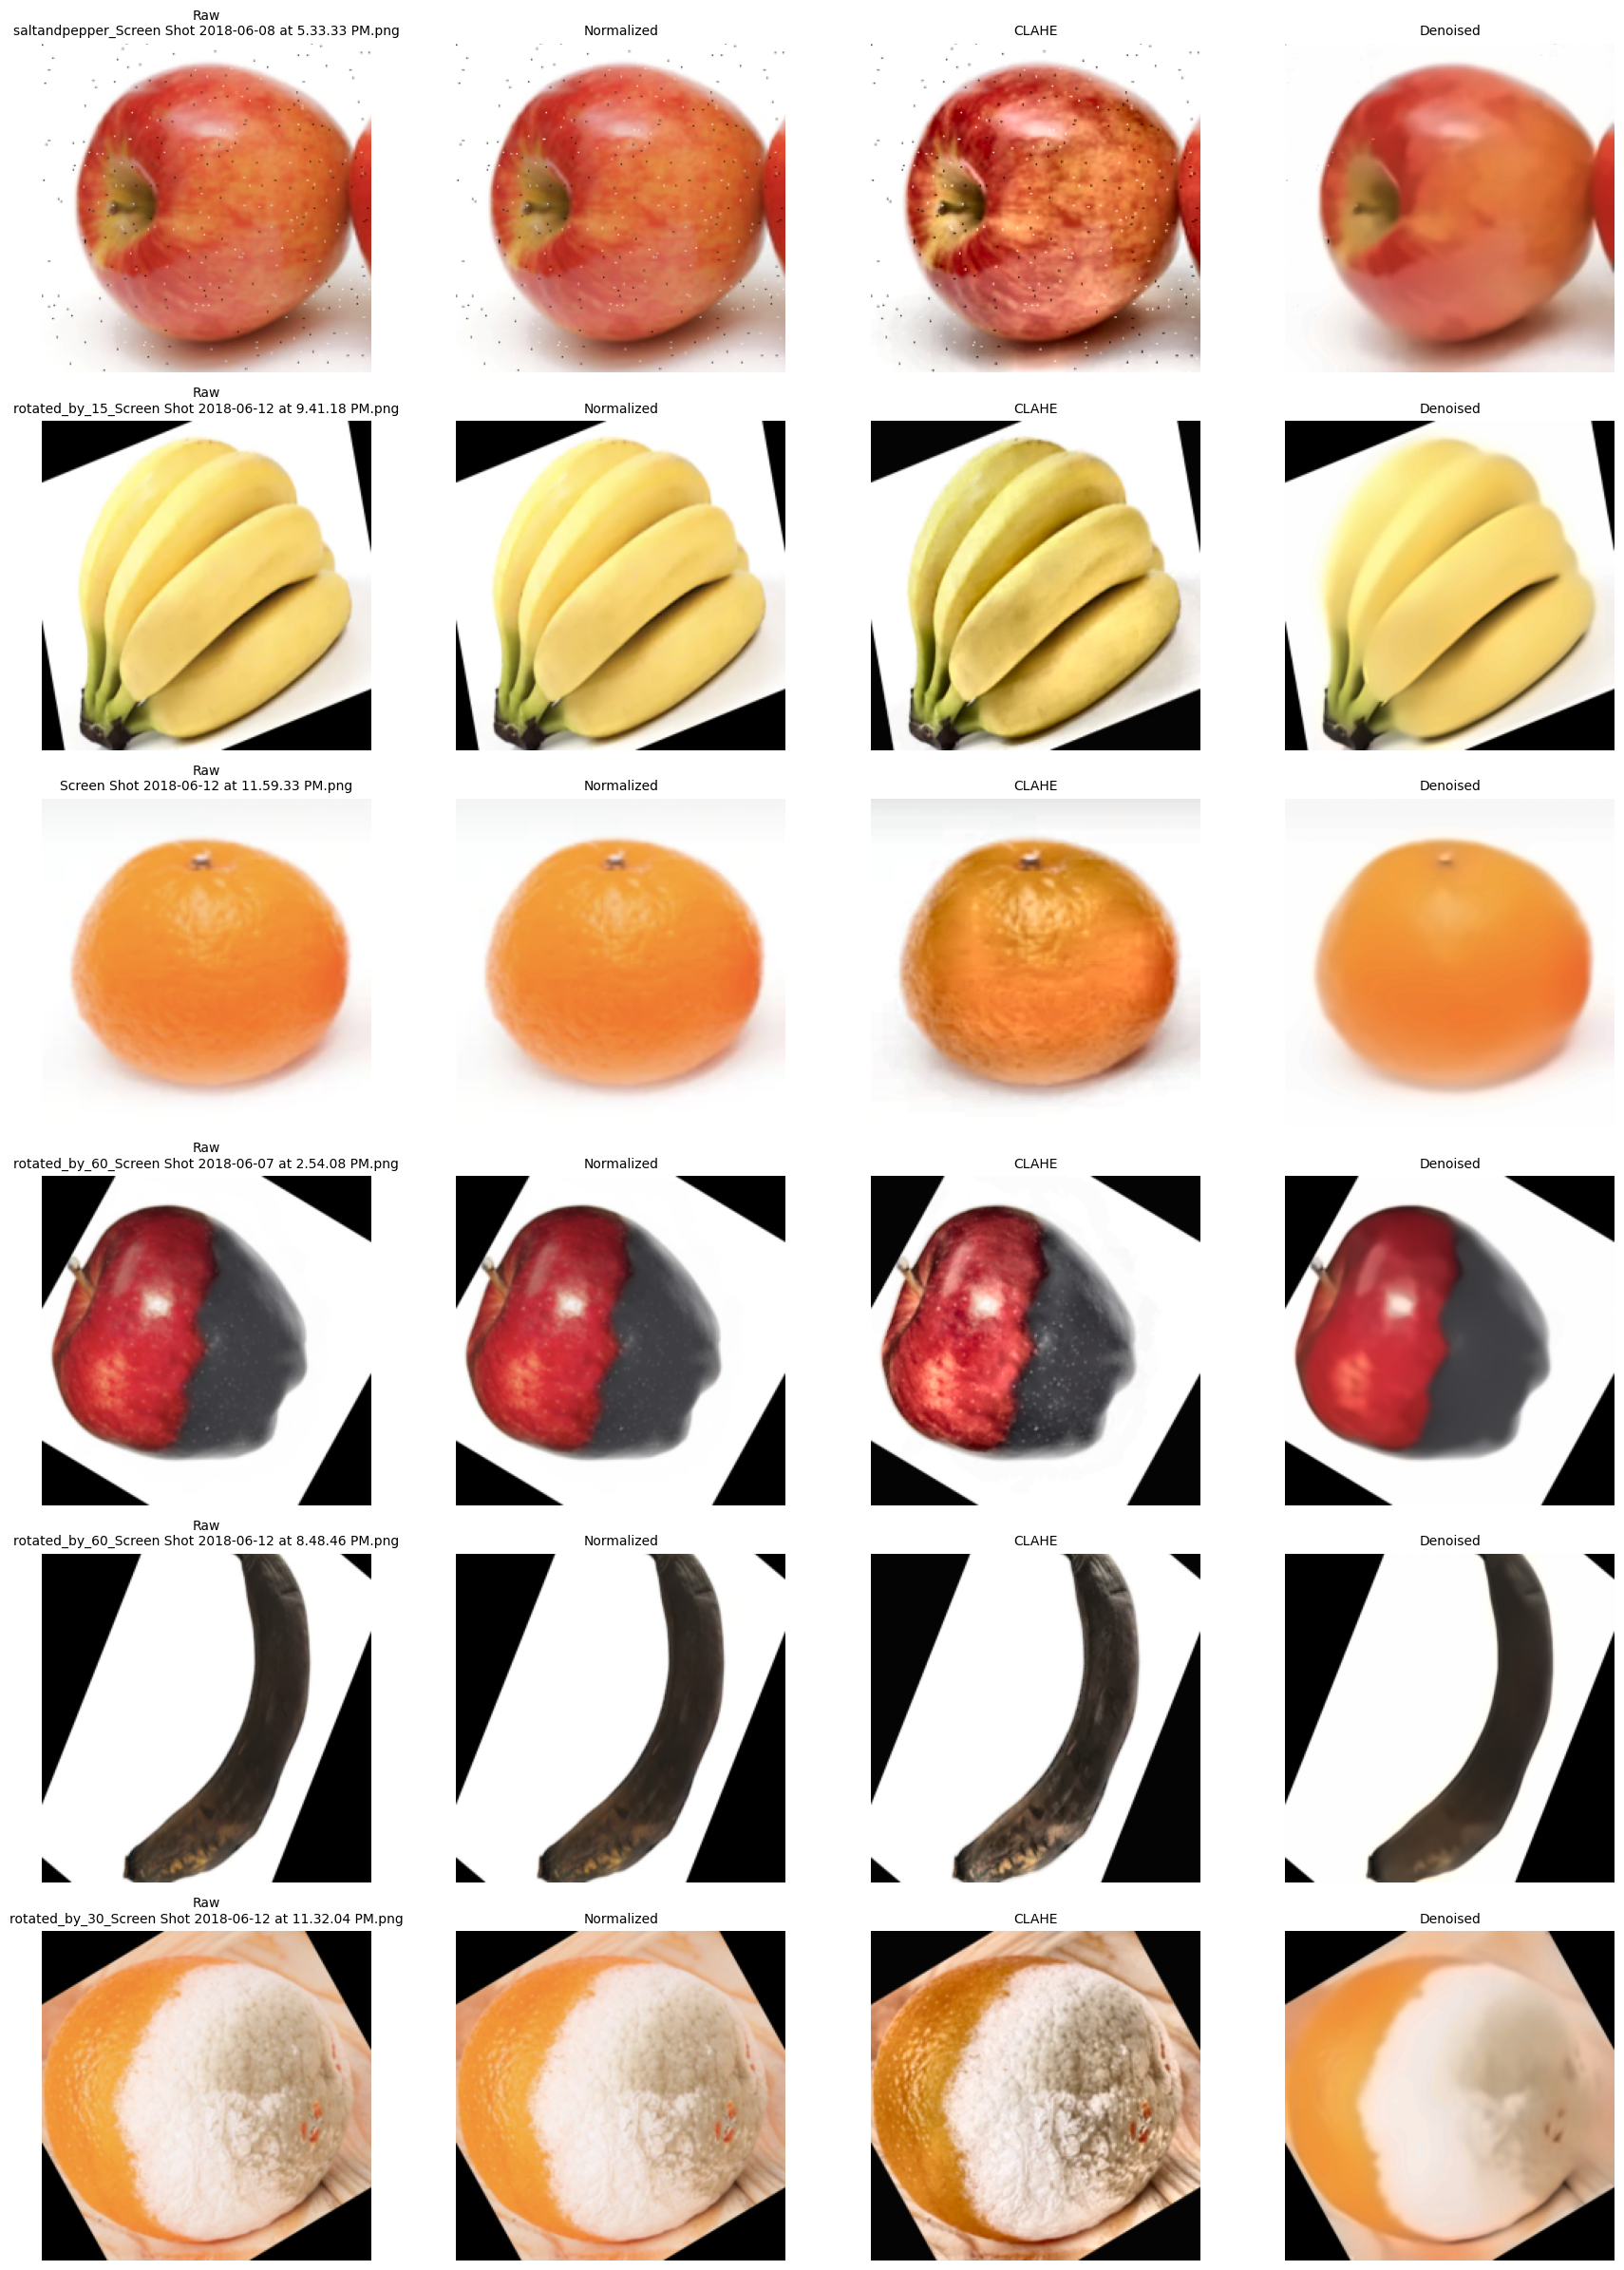

In [9]:
import os
import random
from pathlib import Path
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_ROOT = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TARGET_SIZE = (224, 224)   
N_SAMPLES = 6            
RANDOM_SEED = 42
USE_CLAHE_IN_PREPROCESS = False 
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ---------------- Helpers ----------------
def is_image_file(fname):
    return fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))

def resize_uint8(img, size):
    """Resize a numpy uint8 image (H,W,3) to target size (h,w) using INTER_AREA."""
    h, w = size
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

def to_uint8(pil_or_arr):
    """Convert PIL image or numpy array to uint8 RGB numpy array."""
    if isinstance(pil_or_arr, Image.Image):
        arr = np.array(pil_or_arr.convert("RGB"))
    else:
        arr = np.array(pil_or_arr)

    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)

    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = arr[..., :3]
    if arr.dtype != np.uint8:
        if arr.max() <= 1.0:
            arr = (arr * 255).astype(np.uint8)
        else:
            arr = arr.astype(np.uint8)
    return arr

def apply_clahe(img_uint8, clipLimit=2.0, tileGridSize=(8,8)):
    """
    Apply CLAHE on L channel in LAB color space.
    img_uint8: RGB uint8 array
    returns: RGB uint8 array after CLAHE
    """
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return rgb

def apply_denoise(img_uint8, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21):
    """Use OpenCV fastNlMeansDenoisingColored (expects uint8 BGR/RGB)"""
    den = cv2.fastNlMeansDenoisingColored(img_uint8, None, h, hColor, templateWindowSize, searchWindowSize)
    return den

# ---------------- Preprocess Function ----------------
def preprocess_image_for_model(pil_image, target_size=TARGET_SIZE, apply_clahe=False, normalize=True):
    arr = to_uint8(pil_image)
    arr = resize_uint8(arr, target_size)
    if apply_clahe:
        arr = apply_clahe(arr)
    # convert to float32 in [0,1]  -> normalization
    arr_f = arr.astype("float32") / 255.0
    return arr_f

# ---------------- Gather sample image paths: one per class ----------------
if not os.path.isdir(TRAIN_DIR):
    raise RuntimeError(f"TRAIN_DIR not found: {TRAIN_DIR}\nPlease check DATA_ROOT path.")

class_to_imgs = {}

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    imgs = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if is_image_file(f)
    ]
    if imgs:
        class_to_imgs[cls] = imgs

if len(class_to_imgs) == 0:
    raise RuntimeError("No images found under TRAIN_DIR. Check path and dataset presence.")

# Pick one random image per class (up to N_SAMPLES)
sample_paths = []
for cls in sorted(class_to_imgs.keys()):
    if len(sample_paths) >= N_SAMPLES:
        break
    sample_paths.append(random.choice(class_to_imgs[cls]))

print(f"Previewing {len(sample_paths)} images (one per class) from {TRAIN_DIR}\n")

# ---------------- Build and show preview grid ----------------
n_rows = len(sample_paths)
fig, axes = plt.subplots(n_rows, 4, figsize=(18, 4*n_rows))
if n_rows == 1:
    axes = np.expand_dims(axes, 0)

for i, path in enumerate(sample_paths):
    try:
        pil = Image.open(path).convert("RGB")
    except Exception as e:
        print(f"[skip] cannot open {path}: {e}")
        continue

    name = os.path.basename(path)

    # Raw uint8 resized
    raw_uint8 = resize_uint8(to_uint8(pil), TARGET_SIZE)
    raw_vis = raw_uint8.astype("float32") / 255.0

    # Normalized according to preprocess_image_for_model
    proc = preprocess_image_for_model(pil, target_size=TARGET_SIZE, apply_clahe=USE_CLAHE_IN_PREPROCESS)
    proc_vis = np.clip(proc, 0.0, 1.0)

    # CLAHE
    clahe_uint8 = apply_clahe(raw_uint8)
    clahe_vis = clahe_uint8.astype("float32") / 255.0

    # Denoised
    den_uint8 = apply_denoise(raw_uint8)
    den_vis = den_uint8.astype("float32") / 255.0

    # Plotting: Raw | Normalized | CLAHE | Denoised
    axes[i,0].imshow(raw_vis)
    axes[i,0].set_title(f"Raw\n{name}", fontsize=10)
    axes[i,0].axis("off")

    axes[i,1].imshow(proc_vis)
    axes[i,1].set_title("Normalized", fontsize=10)
    axes[i,1].axis("off")

    axes[i,2].imshow(clahe_vis)
    axes[i,2].set_title("CLAHE", fontsize=10)
    axes[i,2].axis("off")

    axes[i,3].imshow(den_vis)
    axes[i,3].set_title("Denoised", fontsize=10)
    axes[i,3].axis("off")

plt.tight_layout()
plt.show()


# **Image Quality Evaluation with PSNR & SSIM**

In [13]:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_ROOT = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
IMG_SIZE = (224, 224)
RND_SEED = 42
NOISE_SIGMA = 25
APPLY_CLAHE = True
SAVE_CSV = True
OUTPUT_CSV = "/kaggle/working/psnr_ssim_results.csv"

random.seed(RND_SEED)
np.random.seed(RND_SEED)

# ---------------- HELPER FUNCTIONS ----------------
def is_image_file(fname):
    return fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))

def to_uint8(img):
    if isinstance(img, Image.Image):
        arr = np.array(img.convert("RGB"))
    else:
        arr = np.array(img)

    if arr.ndim == 2:
        arr = np.stack([arr]*3, axis=-1)

    if arr.ndim == 3 and arr.shape[2] == 4:
        arr = arr[..., :3]

    if arr.dtype != np.uint8:
        if arr.max() <= 1:
            arr = (arr * 255).astype(np.uint8)
        else:
            arr = arr.astype(np.uint8)

    return arr

def resize_uint8(img, size):
    h, w = size
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

def apply_clahe_rgb(img_uint8):
    lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    lab2 = cv2.merge([l2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)

def add_gaussian_noise(img, sigma=25):
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def denoise_fastnlmeans(img):
    return cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

# ---------------- SAMPLE EXACTLY 1 IMAGE PER CLASS ----------------
all_images = [] 

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    files = [f for f in sorted(os.listdir(cls_path)) if is_image_file(f)]
    if len(files) == 0:
        continue

    chosen_file = random.choice(files)
    all_images.append((cls, os.path.join(cls_path, chosen_file)))

print(f"Total classes found: {len(all_images)} (should be 6)")
print(all_images)

# ---------------- PROCESS IMAGES ----------------
rows = []

for cls, path in all_images:
    pil = Image.open(path).convert("RGB")
    orig = resize_uint8(to_uint8(pil), IMG_SIZE)

    noisy = add_gaussian_noise(orig, sigma=NOISE_SIGMA)
    denoised = denoise_fastnlmeans(noisy)
    
    processed = denoised.copy()
    if APPLY_CLAHE:
        processed = apply_clahe_rgb(processed)

    psnr_before = psnr(orig, noisy, data_range=255)
    psnr_after = psnr(orig, denoised, data_range=255)

    ssim_before = ssim(orig, noisy, data_range=255, channel_axis=-1, win_size=7)
    ssim_after  = ssim(orig, denoised, data_range=255, channel_axis=-1, win_size=7)

    rows.append({
        "Class": cls,
        "Image": os.path.basename(path),
        "PSNR Before (dB)": round(float(psnr_before), 2),
        "PSNR After (dB)": round(float(psnr_after), 2),
        "SSIM Before": round(float(ssim_before), 4),
        "SSIM After": round(float(ssim_after), 4),
    })

df = pd.DataFrame(rows)
df = df.sort_values(["Class"]).reset_index(drop=True)

print("\n===   PSNR & SSIM RESULTS (1 sample per class)   ===\n")
display(df)

if SAVE_CSV:
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"Saved CSV: {OUTPUT_CSV}")


Total classes found: 6 (should be 6)
[('freshapples', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/freshapples/saltandpepper_Screen Shot 2018-06-08 at 5.33.33 PM.png'), ('freshbanana', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/freshbanana/rotated_by_15_Screen Shot 2018-06-12 at 9.41.18 PM.png'), ('freshoranges', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/freshoranges/Screen Shot 2018-06-12 at 11.59.33 PM.png'), ('rottenapples', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/rottenapples/rotated_by_60_Screen Shot 2018-06-07 at 2.54.08 PM.png'), ('rottenbanana', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/rottenbanana/rotated_by_60_Screen Shot 2018-06-12 at 8.48.46 PM.png'), ('rottenoranges', '/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset/train/rottenoranges/rotated_by_30_Screen Shot 2018-06-12 at 11.32.04 PM.png')]

===   PSNR & SS

,Class,Image,PSNR Before (dB),PSNR After (dB),SSIM Before,SSIM After
0,freshapples,saltandpepper_Screen Shot 2018-06-08 at 5.33.3...,20.94,26.11,0.3153,0.7184
1,freshbanana,rotated_by_15_Screen Shot 2018-06-12 at 9.41.1...,21.58,27.09,0.3257,0.8479
2,freshoranges,Screen Shot 2018-06-12 at 11.59.33 PM.png,21.59,30.08,0.2104,0.9168
3,rottenapples,rotated_by_60_Screen Shot 2018-06-07 at 2.54.0...,21.55,24.16,0.3051,0.6025
4,rottenbanana,rotated_by_60_Screen Shot 2018-06-12 at 8.48.4...,22.42,24.54,0.2853,0.6734
5,rottenoranges,rotated_by_30_Screen Shot 2018-06-12 at 11.32....,21.03,27.20,0.2720,0.6861


Saved CSV: /kaggle/working/psnr_ssim_results.csv


# **Stratified 80/10/10 Dataset Split**

In [9]:
# ------ Stratified 80/10/10 split ------
import os, shutil, random
from collections import defaultdict
from sklearn.model_selection import train_test_split
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ---------- CONFIG ----------
BASE_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"  
OUT_BASE = "/kaggle/working/split_dataset"  
SEED = 42
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
FORCE_OVERWRITE = True   
MAX_TRIES_STRATIFY = 3
random.seed(SEED)

# -------------------- Collect Dataset Images --------------------
def collect_images(dataset_root):
    imgs = []
    labels = []
    cand_roots = [dataset_root, os.path.join(dataset_root, "train"), os.path.join(dataset_root, "test")]
    seen_dirs = set()
    for root in cand_roots:
        if not os.path.isdir(root): continue
        for cls in sorted(os.listdir(root)):
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir): continue
            absdir = os.path.abspath(cls_dir)
            if absdir in seen_dirs: continue
            seen_dirs.add(absdir)
            for fn in sorted(os.listdir(cls_dir)):
                if fn.lower().endswith(IMG_EXTS):
                    imgs.append(os.path.join(cls_dir, fn))
                    labels.append(cls)
    return imgs, labels

def ensure_clean_outdir(out_base, force=False):
    if os.path.exists(out_base):
        if not force:
            raise RuntimeError(f"{out_base} already exists. Set FORCE_OVERWRITE=True to recreate.")
        shutil.rmtree(out_base)
    os.makedirs(out_base, exist_ok=True)
    for split in ("train","val","test"):
        os.makedirs(os.path.join(out_base, split), exist_ok=True)

# -------------------- Copy Images Without Filename Conflicts --------------------
def unique_copy(src_path, dest_dir):
    base = os.path.basename(src_path)
    name, ext = os.path.splitext(base)
    dest = os.path.join(dest_dir, base)
    i = 1
    while os.path.exists(dest):
        dest = os.path.join(dest_dir, f"{name}_{i}{ext}")
        i += 1
    shutil.copy2(src_path, dest)
    return dest

def write_split(images, labels, dest_root):
    for p, cls in zip(images, labels):
        out_cls = os.path.join(dest_root, cls)
        os.makedirs(out_cls, exist_ok=True)
        unique_copy(p, out_cls)

all_images, all_labels = collect_images(BASE_DIR)
if len(all_images) == 0:
    raise RuntimeError(f"No images found under {BASE_DIR}. Check the BASE_DIR path.")

print(f"Collected {len(all_images)} images across {len(set(all_labels))} classes.")

# -------------------- Perform Stratified Split --------------------
# First split: 90% train+validation and 10% test
# Second split: 90% train and 10% validation of the full dataset
stratify_suc = False
for attempt in range(MAX_TRIES_STRATIFY):
    try:
        imgs_trainval, imgs_test, y_trainval, y_test = train_test_split(
            all_images, all_labels, test_size=0.10, random_state=SEED+attempt, stratify=all_labels
        )
      
        val_rel = 0.10 / 0.90
        imgs_train, imgs_val, y_train, y_val = train_test_split(
            imgs_trainval, y_trainval, test_size=val_rel, random_state=SEED+attempt, stratify=y_trainval
        )
        stratify_suc = True
        break
    except Exception as e:
        print(f"Stratified split attempt {attempt+1} failed: {e}")
        continue

if not stratify_suc:
    print("Stratified split failed after attempts; falling back to random split.")
    imgs_trainval, imgs_test, y_trainval, y_test = train_test_split(
        all_images, all_labels, test_size=0.10, random_state=SEED, shuffle=True
    )
    val_rel = 0.10 / 0.90
    imgs_train, imgs_val, y_train, y_val = train_test_split(
        imgs_trainval, y_trainval, test_size=val_rel, random_state=SEED, shuffle=True
    )

# Verify Sizes
total_after = len(imgs_train) + len(imgs_val) + len(imgs_test)
assert total_after == len(all_images), "Split size mismatch!"

# Write to disk (clean)
ensure_clean_outdir(OUT_BASE, force=FORCE_OVERWRITE)
write_split(imgs_train, y_train, os.path.join(OUT_BASE, "train"))
write_split(imgs_val,   y_val,   os.path.join(OUT_BASE, "val"))
write_split(imgs_test,  y_test,  os.path.join(OUT_BASE, "test"))

# Result: per-class and percentages
def summarize_folder(root):
    d = {}
    tot = 0
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir): continue
        n = sum(1 for fn in os.listdir(cls_dir) if fn.lower().endswith(IMG_EXTS))
        d[cls] = n
        tot += n
    return d, tot

train_counts, train_total = summarize_folder(os.path.join(OUT_BASE, "train"))
val_counts, val_total     = summarize_folder(os.path.join(OUT_BASE, "val"))
test_counts, test_total   = summarize_folder(os.path.join(OUT_BASE, "test"))

overall_total = train_total + val_total + test_total

print("\nFINAL SPLIT SUMMARY:")
print(f"  Train: {train_total} images ({train_total/overall_total*100:.2f}%)")
print(f"  Val:   {val_total} images ({val_total/overall_total*100:.2f}%)")
print(f"  Test:  {test_total} images ({test_total/overall_total*100:.2f}%)")
print(f"  Total: {overall_total} images\n")

import pandas as pd
df = pd.DataFrame({
    "class": sorted(list(set(list(train_counts.keys())+list(val_counts.keys())+list(test_counts.keys()))))
})
df["train_count"] = df["class"].map(train_counts).fillna(0).astype(int)
df["val_count"]   = df["class"].map(val_counts).fillna(0).astype(int)
df["test_count"]  = df["class"].map(test_counts).fillna(0).astype(int)
df["total"] = df[["train_count","val_count","test_count"]].sum(axis=1)
df = df.sort_values("total", ascending=False).reset_index(drop=True)
display(df)
print("\nWrote split to:", OUT_BASE)

Collected 13599 images across 6 classes.

FINAL SPLIT SUMMARY:
  Train: 10879 images (80.00%)
  Val:   1360 images (10.00%)
  Test:  1360 images (10.00%)
  Total: 13599 images



,class,train_count,val_count,test_count,total
0,rottenapples,2355,294,294,2943
1,rottenbanana,2203,275,276,2754
2,freshapples,1670,209,209,2088
3,rottenoranges,1598,200,200,1998
4,freshbanana,1570,196,196,1962
5,freshoranges,1483,186,185,1854



Wrote split to: /kaggle/working/split_dataset


# **ResNet34 Model Training**

Device: cuda
Split counts (train,val,test): 10879 1360 1360
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/40  TrainLoss=0.17301 TrainAcc=0.9425  ValLoss=0.05029 ValAcc=0.9853  epoch_time=63.8s
 -> Saved best model to: /kaggle/working/checkpoints/resnet34_best.pth
Epoch 2/40  TrainLoss=0.07729 TrainAcc=0.9751  ValLoss=0.03817 ValAcc=0.9860  epoch_time=65.1s
 -> Saved best model to: /kaggle/working/checkpoints/resnet34_best.pth
Epoch 3/40  TrainLoss=0.04097 TrainAcc=0.9866  ValLoss=0.01118 ValAcc=0.9949  epoch_time=65.6s
 -> Saved best model to: /kaggle/working/checkpoints/resnet34_best.pth
Epoch 4/40  TrainLoss=0.03480 TrainAcc=0.9895  ValLoss=0.02732 ValAcc=0.9919  epoch_time=65.6s
Epoch 5/40  TrainLoss=0.05588 TrainAcc=0.9820  ValLoss=0.02854 ValAcc=0.9897  epoch_time=64.9s
Epoch 6/40  TrainLoss=0.03585 TrainAcc=0.9885  ValLoss=0.02189 ValAcc=0.9934  epoch_time=65.6s
Early stopping.


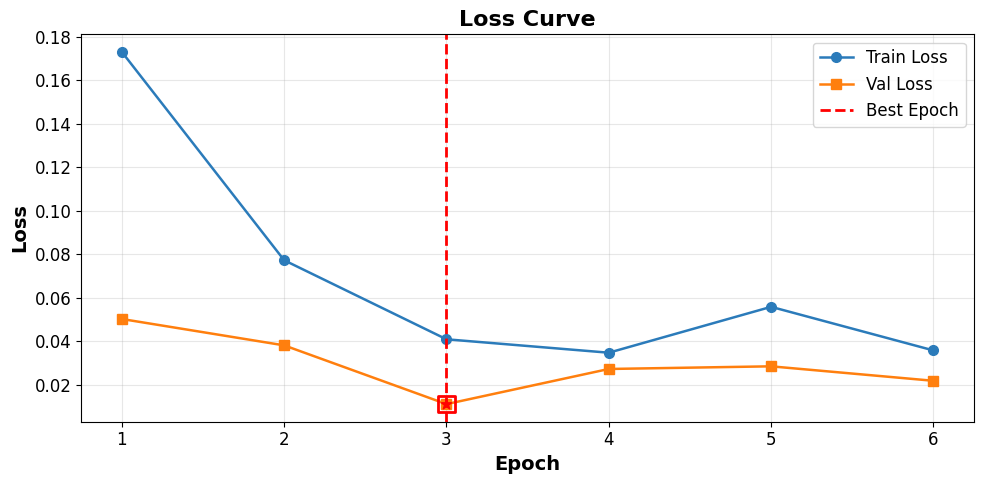

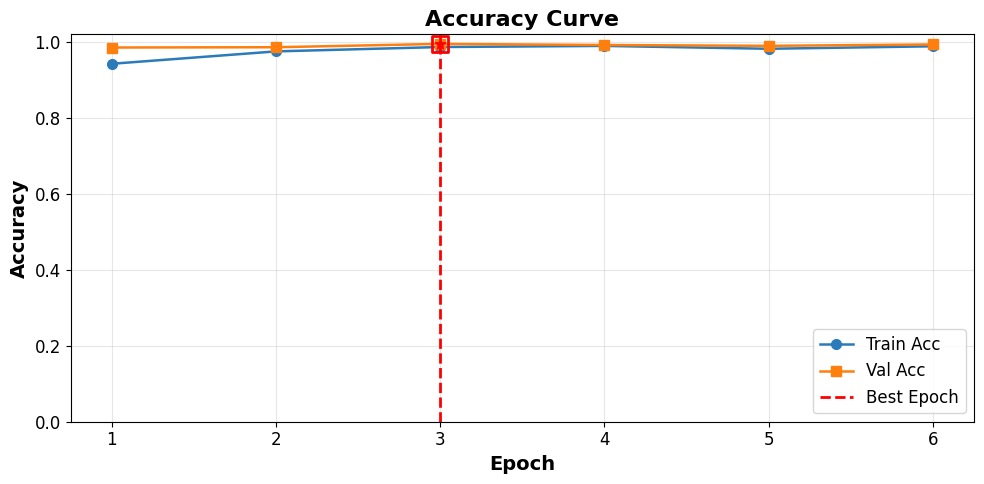

Saved plots: /kaggle/working/checkpoints/loss_curve.png /kaggle/working/checkpoints/accuracy_curve.png


        METRICS

=== TRAIN REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9958    0.9970    0.9964      1670
  freshbanana     0.9994    0.9994    0.9994      1570
 freshoranges     0.9960    1.0000    0.9980      1483
 rottenapples     0.9970    0.9962    0.9966      2355
 rottenbanana     1.0000    0.9991    0.9995      2203
rottenoranges     0.9975    0.9950    0.9962      1598

     accuracy                         0.9977     10879
    macro avg     0.9976    0.9978    0.9977     10879
 weighted avg     0.9977    0.9977    0.9977     10879



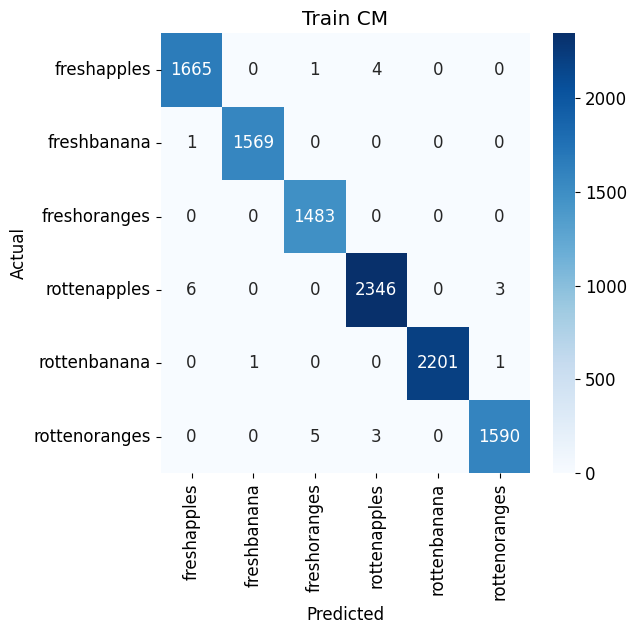

Mean PPV (Precision, macro): 0.9976
Cohen's Kappa: 0.9972
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 1.0000 / 1.0000
Inference time per image (train set): 4.609 ms
Accuracy: 0.9977  95% CI: [0.9968, 0.9986]

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    0.9856    0.9928       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9894    1.0000    0.9947       186
 rottenapples     0.9898    0.9932    0.9915       294
 rottenbanana     1.0000    1.0000    1.0000       275
rottenoranges     0.9900    0.9900    0.9900       200

     accuracy                         0.9949      1360
    macro avg     0.9949    0.9948    0.9948      1360
 weighted avg     0.9949    0.9949    0.9949      1360



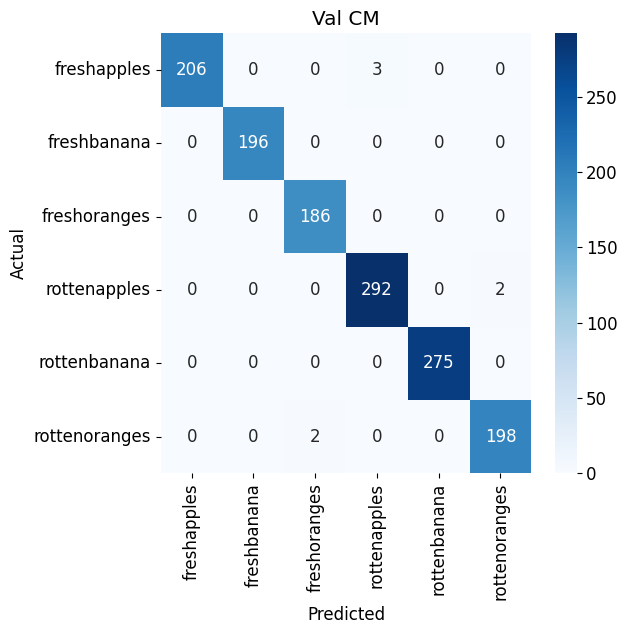

Mean PPV (Precision, macro): 0.9949
Cohen's Kappa: 0.9938
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 1.0000 / 1.0000
Inference time per image (val set): 2.746 ms
Accuracy: 0.9949  95% CI: [0.9910, 0.9987]

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    1.0000    1.0000       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9946    1.0000    0.9973       185
 rottenapples     1.0000    1.0000    1.0000       294
 rottenbanana     1.0000    1.0000    1.0000       276
rottenoranges     1.0000    0.9950    0.9975       200

     accuracy                         0.9993      1360
    macro avg     0.9991    0.9992    0.9991      1360
 weighted avg     0.9993    0.9993    0.9993      1360



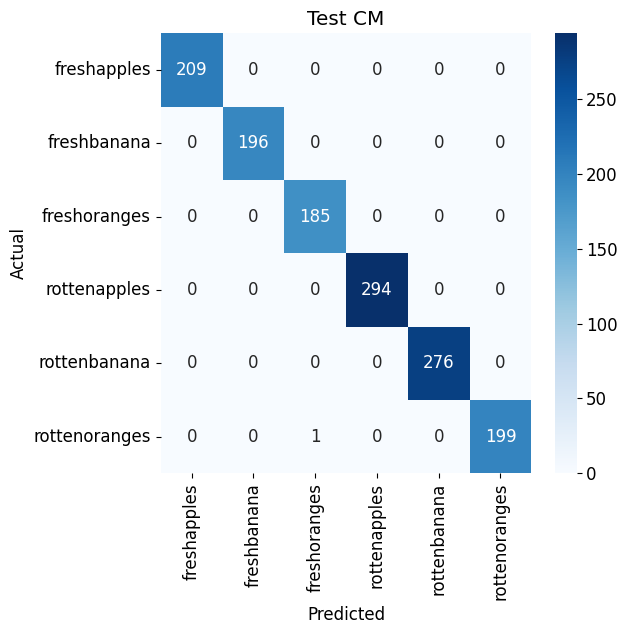

Mean PPV (Precision, macro): 0.9991
Cohen's Kappa: 0.9991
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 1.0000 / 1.0000
Inference time per image (test set): 2.714 ms
Accuracy: 0.9993  95% CI: [0.9978, 1.0000]


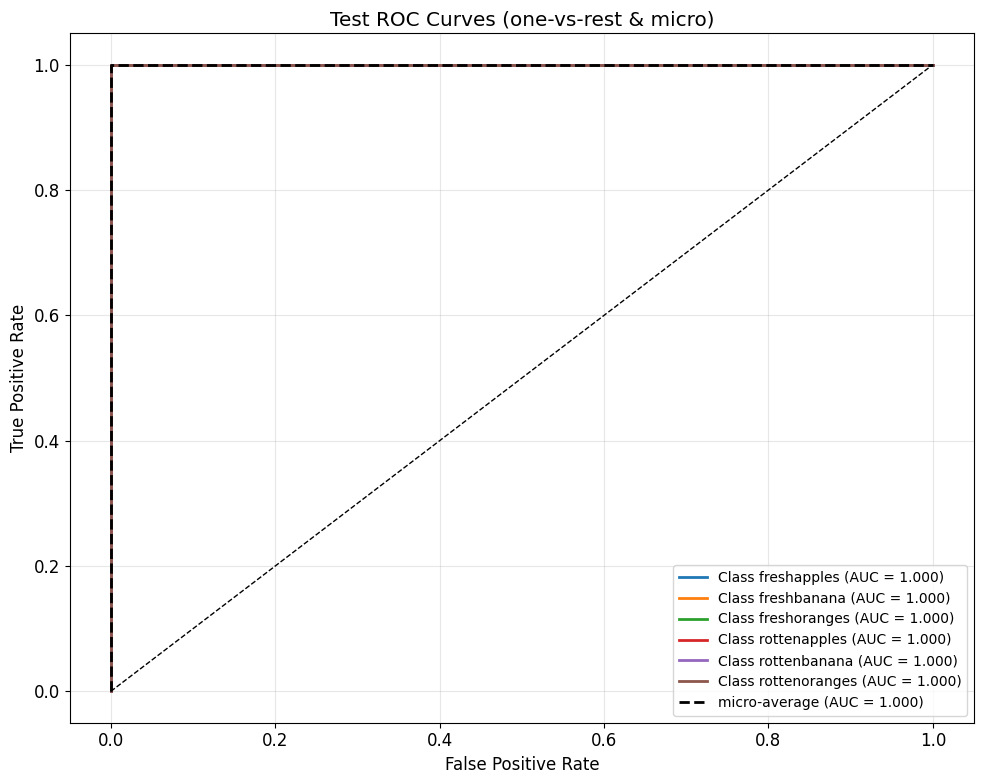

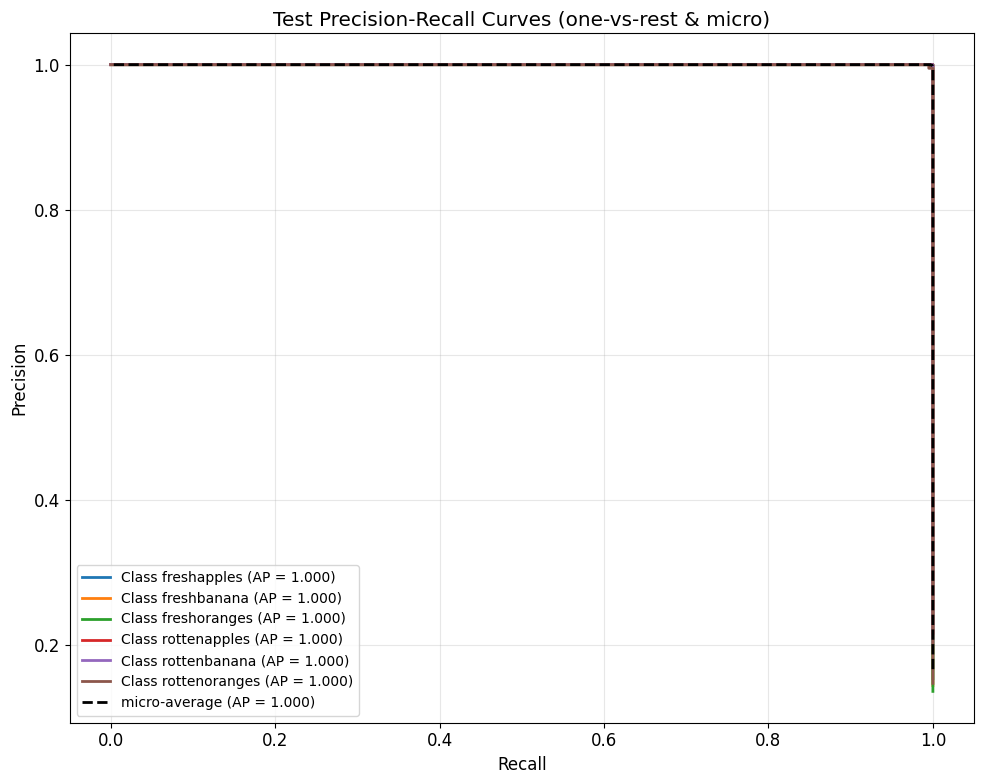



        TIME & MEMORY
Total training time (s): 391.2033634185791
Avg time / epoch (s): 65.20056056976318
Max GPU memory allocated (GB): 1.56444928
Max GPU memory reserved  (GB): 1.979711488
CPU RSS (GB): 2.55696896
Inference time per image (ms): 5.450248718261719
Best checkpoint saved at: /kaggle/working/checkpoints/resnet34_best.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,8

In [9]:
import os, time, copy, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, cohen_kappa_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import psutil

# ---------- CONFIG ----------
SPLIT_ROOT = "/kaggle/working/split_dataset" 
CKPT_DIR = Path("/kaggle/working/checkpoints"); CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUT_WEIGHTS = CKPT_DIR/"resnet34_best.pth"

MODEL_NAME = "resnet34"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4
WD = 1e-4
DROPOUT = 0.5
SEED = 42
NUM_WORKERS = 4
BOOTSTRAP_SAMPLES = 500  

# Reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Data paths & leakage check ---
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")

def list_files(root):
    exts = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff'); s=set()
    if not os.path.isdir(root): return s
    for cls in os.listdir(root):
        cls_dir=os.path.join(root,cls)
        if not os.path.isdir(cls_dir): continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(exts):
                s.add(os.path.abspath(os.path.join(cls_dir,f)))
    return s

train_files = list_files(TRAIN_DIR); val_files = list_files(VAL_DIR); test_files = list_files(TEST_DIR)
print("Split counts (train,val,test):", len(train_files), len(val_files), len(test_files))
if len(train_files & val_files) or len(train_files & test_files) or len(val_files & test_files):
    raise RuntimeError("DATA LEAKAGE DETECTED: overlapping files between splits. Fix Task-05 first.")

# --- Transforms (ImageNet normalisation) ---
imagenet_mean = [0.485,0.456,0.406]; imagenet_std=[0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85,1.0)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.08,0.08,0.08,0.03),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# --- Datasets & Loaders ---
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

class_names = train_ds.classes; num_classes = len(class_names)
print("Classes:", class_names)

# --- Model build (resnet34) ---
weights = models.ResNet34_Weights.IMAGENET1K_V1  
model = models.resnet34(weights=weights)
in_feats = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(in_feats, num_classes))
model = model.to(device)

# --- Loss, Optimizer, Scheduler ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

# --- Training Loop ---
best_val = float('inf')
best_val_epoch = -1
best_acc_val = -1.0
best_acc_epoch = -1
best_wts = copy.deepcopy(model.state_dict())
no_improve = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        running_correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            vcorrect += (out.argmax(1) == yb).sum().item()
            vtotal += xb.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={time.time()-t0:.1f}s")

    if val_loss < best_val:
        best_val = val_loss
        best_val_epoch = epoch
        best_wts = copy.deepcopy(model.state_dict())
        no_improve = 0
        torch.save({"model":MODEL_NAME,"epoch":epoch,"state_dict":best_wts,"val_loss":best_val,"classes":class_names},
                   str(OUT_WEIGHTS))
        print(" -> Saved best model to:", OUT_WEIGHTS)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping.")
            break

    if val_acc > best_acc_val:
        best_acc_val = val_acc
        best_acc_epoch = epoch

total_training_time = time.time() - train_start_time
model.load_state_dict(best_wts)
model = model.to(device)

best_epoch = best_val_epoch if best_val_epoch > 0 else best_acc_epoch

# --- Plot training curves ---
plot_dir = Path(OUT_WEIGHTS).parent
plot_dir.mkdir(parents=True, exist_ok=True)
epochs = np.arange(1, len(train_losses) + 1)
plt.rcParams.update({'font.size': 12})
marker_size = 7

# ---------- LOSS PLOT ----------
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(epochs, train_losses, label="Train Loss", marker='o', linewidth=1.8, markersize=marker_size, color='#2b7bba')  # blue
ax.plot(epochs, val_losses,   label="Val Loss",   marker='s', linewidth=1.8, markersize=marker_size, color='#ff7f0e')  # orange

# vertical dashed best-epoch (red) and highlight marker — NO numeric annotation shown
if best_epoch and 1 <= best_epoch <= len(epochs):
    ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2.0, label="Best Epoch")
    bx = best_epoch
    by = val_losses[best_epoch-1]
    ax.scatter([bx], [by], s=140, facecolors='none', edgecolors='red', linewidths=2.0, marker='s', zorder=6)
    ax.scatter([bx], [by], s=60, color='red', marker='*', zorder=7)

ax.set_title("Loss Curve", fontsize=16, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
ax.set_ylabel("Loss", fontsize=14, fontweight='bold')
ax.set_xticks(epochs)
ax.grid(alpha=0.3)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
loss_plot_path = plot_dir / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

# ---------- ACCURACY PLOT ----------
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(epochs, train_accs, label="Train Acc", marker='o', linewidth=1.8, markersize=marker_size, color='#2b7bba')
ax.plot(epochs, val_accs,   label="Val Acc",   marker='s', linewidth=1.8, markersize=marker_size, color='#ff7f0e')

# same best_epoch vertical line + highlight marker (no numeric annotation)
if best_epoch and 1 <= best_epoch <= len(epochs):
    ax.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2.0, label="Best Epoch")
    bx = best_epoch
    by = val_accs[best_epoch-1]
    ax.scatter([bx], [by], s=140, facecolors='none', edgecolors='red', linewidths=2.0, marker='s', zorder=6)
    ax.scatter([bx], [by], s=60, color='red', marker='*', zorder=7)

ax.set_title("Accuracy Curve", fontsize=16, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=14, fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=14, fontweight='bold')
ax.set_ylim(0.0, 1.02)
ax.set_xticks(epochs)
ax.grid(alpha=0.3)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
acc_plot_path = plot_dir / "accuracy_curve.png"
plt.savefig(acc_plot_path, dpi=150)
plt.show()

print("Saved plots:", loss_plot_path, acc_plot_path)

# --- Evaluation helpers ---
def get_preds(model, loader):
    model.eval()
    y_true=[]; y_pred=[]
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(yb.numpy())
    return np.array(y_true), np.array(y_pred)

def get_preds_and_probs(model, loader):
    model.eval()
    y_true=[]; y_pred=[]; y_score=[]
    total_images = 0
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)   # logits
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            y_score.append(probs)
            y_pred.extend(preds)
            y_true.extend(yb.numpy())
            total_images += xb.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed / total_images) * 1000.0 if total_images>0 else 0.0
    y_score = np.vstack(y_score) if len(y_score)>0 else np.zeros((len(y_true), num_classes))
    return np.array(y_true), np.array(y_pred), y_score, time_per_image_ms

def plot_confusion(cm, labels, title):
    fig, ax = plt.subplots(figsize=(6.5,6.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

print("\n\n===================")
print("        METRICS")
print("======================")
def accuracy_ci(y_true, y_pred, alpha=0.05):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    z = 1.96  # for 95%
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

print("\n=== TRAIN REPORT ===")
yt_train, yp_train, yscore_tr, time_per_image_train = get_preds_and_probs(model, train_loader)
print(classification_report(yt_train, yp_train, target_names=class_names, digits=4))
plot_confusion(confusion_matrix(yt_train, yp_train), class_names, "Train CM")
mean_ppv_train = precision_score(yt_train, yp_train, average='macro', zero_division=0)
cohens_kappa_train = cohen_kappa_score(yt_train, yp_train)
try:
    roc_auc_train_macro = roc_auc_score(np.eye(num_classes)[yt_train], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_train_micro = roc_auc_score(np.eye(num_classes)[yt_train], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_train_macro = float('nan'); roc_auc_train_micro = float('nan')
try:
    pr_auc_train_macro = average_precision_score(np.eye(num_classes)[yt_train], yscore_tr, average='macro')
    pr_auc_train_micro = average_precision_score(np.eye(num_classes)[yt_train], yscore_tr, average='micro')
except Exception:
    pr_auc_train_macro = float('nan'); pr_auc_train_micro = float('nan')

acc_train, lo_train, hi_train = accuracy_ci(yt_train, yp_train)

print(f"Mean PPV (Precision, macro): {mean_ppv_train:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_train:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_train_macro:.4f} / {roc_auc_train_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_train_macro:.4f} / {pr_auc_train_micro:.4f}")
print(f"Inference time per image (train set): {time_per_image_train:.3f} ms")
print(f"Accuracy: {acc_train:.4f}  95% CI: [{lo_train:.4f}, {hi_train:.4f}]")

print("\n=== VAL REPORT ===")
yt_val, yp_val, yscore_val, time_per_image_val = get_preds_and_probs(model, val_loader)
print(classification_report(yt_val, yp_val, target_names=class_names, digits=4))
plot_confusion(confusion_matrix(yt_val, yp_val), class_names, "Val CM")

mean_ppv_val = precision_score(yt_val, yp_val, average='macro', zero_division=0)
cohens_kappa_val = cohen_kappa_score(yt_val, yp_val)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(num_classes)[yt_val], yscore_val, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(num_classes)[yt_val], yscore_val, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(num_classes)[yt_val], yscore_val, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(num_classes)[yt_val], yscore_val, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_val, lo_val, hi_val = accuracy_ci(yt_val, yp_val)

print(f"Mean PPV (Precision, macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_val:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_val_macro:.4f} / {roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_val_macro:.4f} / {pr_auc_val_micro:.4f}")
print(f"Inference time per image (val set): {time_per_image_val:.3f} ms")
print(f"Accuracy: {acc_val:.4f}  95% CI: [{lo_val:.4f}, {hi_val:.4f}]")

if len(test_ds) > 0:
    print("\n=== TEST REPORT ===")
    yt_test, yp_test, yscore_test, time_per_image_test = get_preds_and_probs(model, test_loader)
    print(classification_report(yt_test, yp_test, target_names=class_names, digits=4))
    plot_confusion(confusion_matrix(yt_test, yp_test), class_names, "Test CM")

    # Extra metrics for test
    mean_ppv_test = precision_score(yt_test, yp_test, average='macro', zero_division=0)
    cohens_kappa_test = cohen_kappa_score(yt_test, yp_test)
    try:
        roc_auc_test_macro = roc_auc_score(np.eye(num_classes)[yt_test], yscore_test, average='macro', multi_class='ovr')
        roc_auc_test_micro = roc_auc_score(np.eye(num_classes)[yt_test], yscore_test, average='micro', multi_class='ovr')
    except Exception:
        roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
    try:
        pr_auc_test_macro = average_precision_score(np.eye(num_classes)[yt_test], yscore_test, average='macro')
        pr_auc_test_micro = average_precision_score(np.eye(num_classes)[yt_test], yscore_test, average='micro')
    except Exception:
        pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

    acc_test, lo_test, hi_test = accuracy_ci(yt_test, yp_test)

    print(f"Mean PPV (Precision, macro): {mean_ppv_test:.4f}")
    print(f"Cohen's Kappa: {cohens_kappa_test:.4f}")
    print(f"ROC AUC (macro / micro): {roc_auc_test_macro:.4f} / {roc_auc_test_micro:.4f}")
    print(f"PR AUC  (macro / micro): {pr_auc_test_macro:.4f} / {pr_auc_test_micro:.4f}")
    print(f"Inference time per image (test set): {time_per_image_test:.3f} ms")
    print(f"Accuracy: {acc_test:.4f}  95% CI: [{lo_test:.4f}, {hi_test:.4f}]")

    y_true_onehot = np.eye(num_classes)[yt_test] 
    # ROC curves per class + micro
    plt.figure(figsize=(10, 8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(num_classes):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_test[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {class_names[i]} (AUC = {roc_auc[i]:.3f})")
    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_test.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(num_classes):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_test[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_test[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"Class {class_names[i]} (AP = {ap[i]:.3f})")

    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_test.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_test, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AP = {ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")
print("Total training time (s):", total_training_time)
print("Avg time / epoch (s):", total_training_time / (epoch if 'epoch' in locals() else 1))
if torch.cuda.is_available():
    try:
        print("Max GPU memory allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU memory reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        pass
print("CPU RSS (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference probe
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0=time.time(); out = model(sample); 
    if device.type=='cuda': torch.cuda.synchronize()
    t1=time.time()
    infer_ms = (t1-t0)*1000.0
print("Inference time per image (ms):", infer_ms)

print("Best checkpoint saved at:", OUT_WEIGHTS)
print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total_params:,}  Trainable: {trainable_params:,}")

# **Gradcam Visualization for Resnet34**

Device: cuda
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Creating resnet34 model (num_classes = 6 )


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded checkpoint. Missing keys count: 0 Unexpected keys count: 0
Using target layer for Grad-CAM: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Collected 10 samples covering classes: [0, 1, 2, 3, 4, 5]


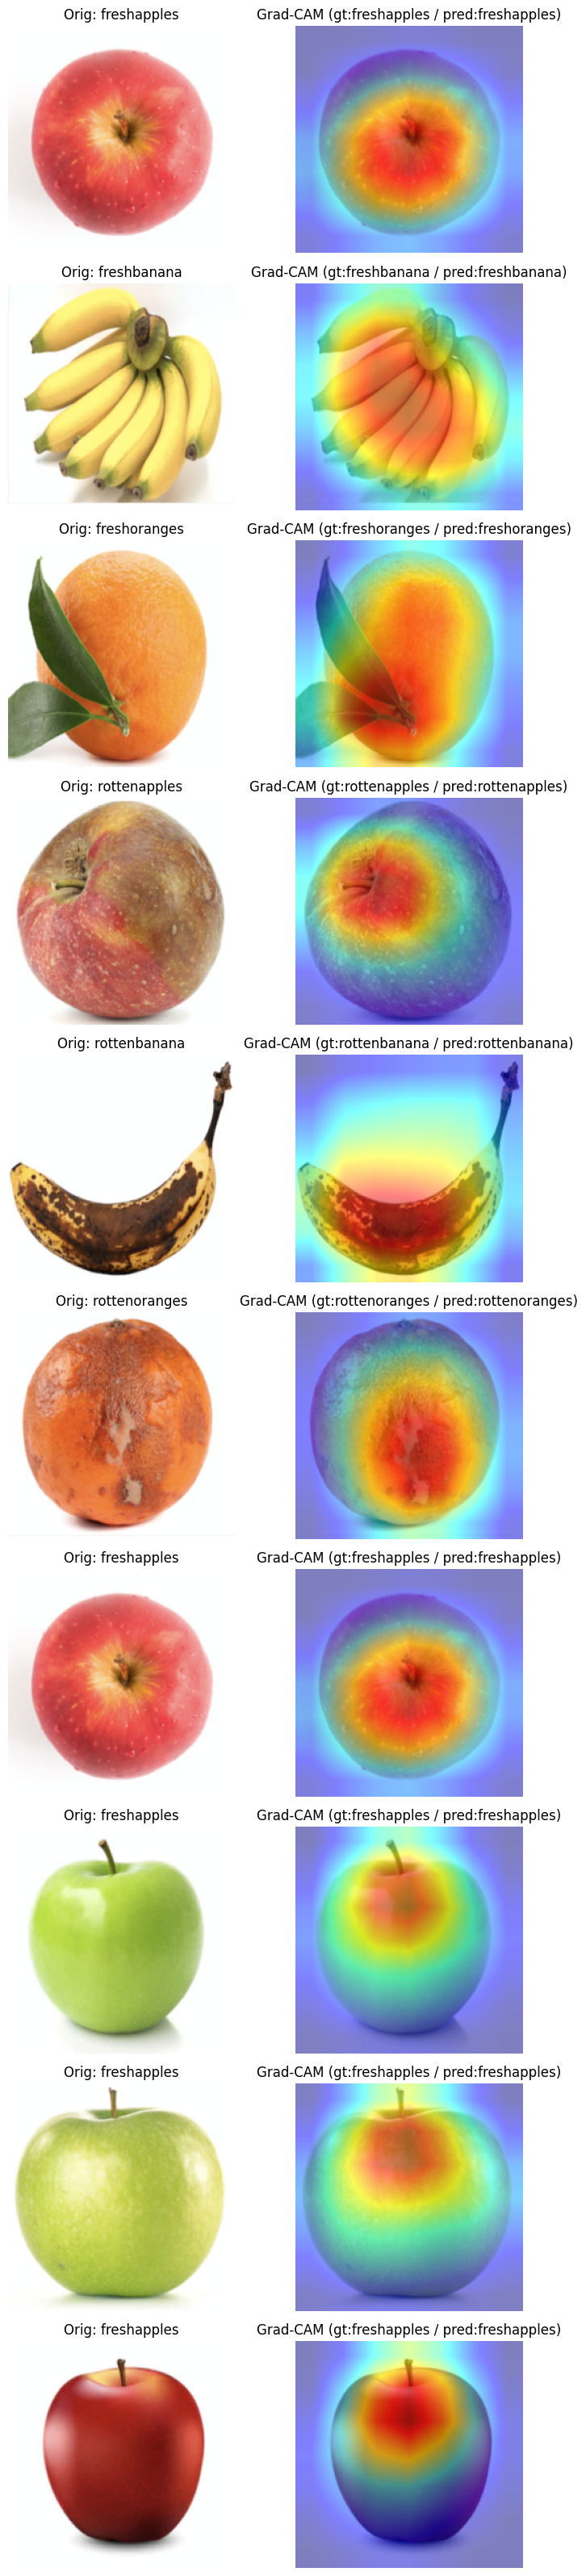

Saved side-by-side Grad-CAM image to: /kaggle/working/checkpoints/eval/gradcam_side_by_side.png


In [9]:
import os, random, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import torchvision.models as models
import cv2

# ---------- USER / ENV CONFIG ----------
SPLIT_ROOT = "/kaggle/working/split_dataset"   
CKPT_PATH = "/kaggle/working/checkpoints/resnet34_best.pth"   
OUT_DIR = os.path.dirname(CKPT_PATH)
EVAL_DIR = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

OUT_IMAGE = os.path.join(EVAL_DIR, "gradcam_side_by_side.png") 

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42

IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')

# reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------------- Data helpers ----------------
def gather_class_image_pairs(root):
    pairs = []
    classes = []
    if not os.path.isdir(root):
        return pairs, classes
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir): continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                pairs.append((os.path.join(cls_dir, fn), cls))
    return pairs, classes

class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        if isinstance(lbl, str):
            lbl = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

# eval transforms (same normalization used during training)
imagenet_mean = [0.485,0.456,0.406]; imagenet_std=[0.229,0.224,0.225]
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# load splits
train_dir = os.path.join(SPLIT_ROOT, "train")
val_dir   = os.path.join(SPLIT_ROOT, "val")
test_dir  = os.path.join(SPLIT_ROOT, "test")
if not os.path.isdir(test_dir):
    raise RuntimeError("Test split not found at: " + test_dir)

train_pairs, train_classes = gather_class_image_pairs(train_dir)
val_pairs, val_classes = gather_class_image_pairs(val_dir)
test_pairs, test_classes = gather_class_image_pairs(test_dir)
classes = sorted(list(set(train_classes + val_classes + test_classes)))
class_to_idx = {c:i for i,c in enumerate(classes)}
NUM_CLASSES = len(classes)
print("Classes:", classes)

# create test loader
test_ds = ImagePathDataset(test_pairs, class_to_idx, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

# ---------------- Build model & load checkpoint ----------------
print("Creating resnet34 model (num_classes =", NUM_CLASSES, ")")
model = models.resnet34(pretrained=False)
in_feats = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_feats, NUM_CLASSES))
model = model.to(device)

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(f"Checkpoint not found at: {CKPT_PATH}")
ckpt = torch.load(CKPT_PATH, map_location=device)
# ckpt may be dict with "state_dict"
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

def strip_prefix_if_present(state_dict, prefix="module."):
    if any(k.startswith(prefix) for k in state_dict.keys()):
        return {k[len(prefix):]:v for k,v in state_dict.items()}
    return state_dict
state = strip_prefix_if_present(state, "module.")
missing, unexpected = model.load_state_dict(state, strict=False)
print("Loaded checkpoint. Missing keys count:", len(missing), "Unexpected keys count:", len(unexpected))
model.eval()

# ---------------- Grad-CAM ----------------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            # grad_output might be tuple
            self.gradients = grad_output[0].detach()
        try:
            self.target_layer.register_forward_hook(forward_hook)
            if hasattr(self.target_layer, "register_full_backward_hook"):
                self.target_layer.register_full_backward_hook(backward_hook)
            else:
                self.target_layer.register_backward_hook(backward_hook)
        except Exception as e:
            raise RuntimeError(f"Failed to register hooks on target layer: {e}")

    def __call__(self, x, class_idx=None):
        """
        x: tensor batch (B,3,H,W)
        class_idx: if None, uses predicted class of the first sample
        returns: cam mask (H, W) numpy normalized 0..1 for first image of batch
        """
        self.model.eval()
        x = x.to(next(self.model.parameters()).device)
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1)[0].item()
        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward(retain_graph=True)
        if self.gradients is None or self.activations is None:
            raise RuntimeError("Gradients or activations not captured. Check target_layer selection.")
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # (B, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (B, 1, H, W)
        cam = torch.nn.functional.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=(x.size(2), x.size(3)), mode='bilinear', align_corners=False)
        cam = cam.squeeze(0).squeeze(0).cpu().numpy()   # (H, W)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def find_target_layer_for_resnet(model):
   
    try:
        return model.layer4[-1].conv2
    except Exception:
     
        last_conv = None
        for m in model.modules():
            if isinstance(m, nn.Conv2d):
                last_conv = m
        if last_conv is None:
            raise RuntimeError("Could not find a target conv layer for Grad-CAM in this model.")
        return last_conv

target_layer = find_target_layer_for_resnet(model)
print("Using target layer for Grad-CAM:", target_layer)
grad_cam = GradCAM(model, target_layer)

# ---------------- Utilities for display ----------------
mean = np.array(imagenet_mean)
std  = np.array(imagenet_std)
def tensor_to_display(img_tensor):
    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    img_np = (img_np * std.reshape(1,1,3)) + mean.reshape(1,1,3)
    img_np = np.clip(img_np, 0.0, 1.0)
    return img_np

# ---------------- Collect samples (10 samples ensuring all classes appear) ----------------
DESIRED_SAMPLES = 10
samples = []   
seen_classes = set()

for imgs, labels in test_loader:
    for i in range(len(imgs)):
        lab = int(labels[i].item())
        if lab not in seen_classes:
            samples.append((imgs[i].cpu(), lab))
            seen_classes.add(lab)
        if len(seen_classes) >= NUM_CLASSES or len(samples) >= DESIRED_SAMPLES:
            break
    if len(seen_classes) >= NUM_CLASSES or len(samples) >= DESIRED_SAMPLES:
        break

if len(samples) < DESIRED_SAMPLES:
    for imgs, labels in test_loader:
        for i in range(len(imgs)):
            if len(samples) >= DESIRED_SAMPLES:
                break
            samples.append((imgs[i].cpu(), int(labels[i].item())))
        if len(samples) >= DESIRED_SAMPLES:
            break

if len(samples) < DESIRED_SAMPLES:
    raise RuntimeError(f"Could only collect {len(samples)} samples; expected {DESIRED_SAMPLES}.")

print(f"Collected {len(samples)} samples covering classes: {sorted(list(seen_classes))}")

# ---------------- Create side-by-side figure (10 rows x 2 cols = 20 images) ----------------
cols = 2
rows = DESIRED_SAMPLES
plt.figure(figsize=(cols * 4.0, rows * 3.2))

for idx, (img_cpu, label) in enumerate(samples):
    img_display = tensor_to_display(img_cpu) 
    img_batch = img_cpu.unsqueeze(0).to(device)

    try:
        mask = grad_cam(img_batch, class_idx=label)
    except Exception:
        mask = grad_cam(img_batch, class_idx=None)

    # Create heatmap overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = 0.5 * heatmap + 0.5 * img_display
    overlay = np.clip(overlay, 0.0, 1.0)

    plt.subplot(rows, cols, idx * 2 + 1)
    plt.imshow(img_display)
    plt.title(f"Orig: {classes[label]}")
    plt.axis('off')

    # Right: grad-cam overlay + predicted label
    plt.subplot(rows, cols, idx * 2 + 2)
    plt.imshow(overlay)
    with torch.no_grad():
        model.eval()
        out = model(img_batch.to(device))
        pred = int(out.argmax(dim=1).item())
    plt.title(f"Grad-CAM (gt:{classes[label]} / pred:{classes[pred]})")
    plt.axis('off')

plt.tight_layout()
plt.savefig(OUT_IMAGE, dpi=200, bbox_inches='tight')
plt.show()

print("Saved side-by-side Grad-CAM image to:", OUT_IMAGE)


# **Mobilelevit_s Model Training**

Using device: cuda
Split counts (train,val,test): 10879 1360 1360
Using on-disk split at /kaggle/working/split_dataset
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Creating model: mobilevit_s


/tmp/ipykernel_47/689210569.py:211: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/689210569.py:229: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  TrainLoss=0.66025 TrainAcc=0.9043  ValLoss=0.60702 ValAcc=0.9169  epoch_time=62.8s
 -> Saved best checkpoint: /kaggle/working/mobilevit/mobilevit_s_best_singlegpu.pth
Epoch 2/40  TrainLoss=0.53845 TrainAcc=0.9600  ValLoss=0.48941 ValAcc=0.9787  epoch_time=60.3s
 -> Saved best checkpoint: /kaggle/working/mobilevit/mobilevit_s_best_singlegpu.pth
Epoch 3/40  TrainLoss=0.50845 TrainAcc=0.9702  ValLoss=0.47326 ValAcc=0.9882  epoch_time=59.9s
 -> Saved best checkpoint: /kaggle/working/mobilevit/mobilevit_s_best_singlegpu.pth
Epoch 4/40  TrainLoss=0.50392 TrainAcc=0.9728  ValLoss=0.49240 ValAcc=0.9772  epoch_time=59.6s
Epoch 5/40  TrainLoss=0.50280 TrainAcc=0.9712  ValLoss=0.44130 ValAcc=0.9971  epoch_time=59.4s
 -> Saved best checkpoint: /kaggle/working/mobilevit/mobilevit_s_best_singlegpu.pth
Epoch 6/40  TrainLoss=0.48357 TrainAcc=0.9806  ValLoss=0.53407 ValAcc=0.9537  epoch_time=59.6s
Epoch 7/40  TrainLoss=0.48264 TrainAcc=0.9816  ValLoss=0.44997 ValAcc=0.9941  epoch_time=59.9s

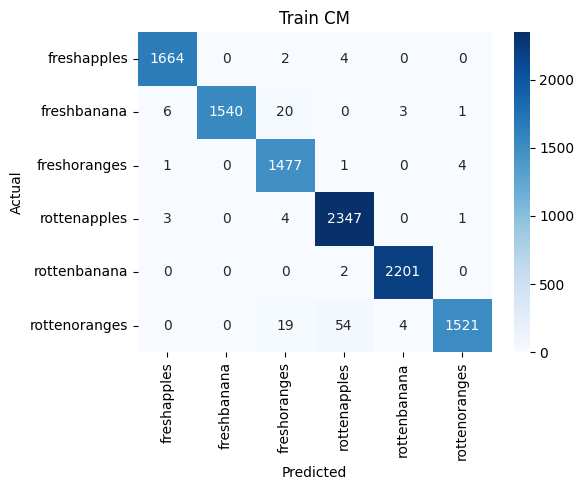

Mean PPV (Precision, macro): 0.9887
Cohen's Kappa: 0.9857
ROC AUC (macro / micro): 0.9999 / 0.9998
PR AUC  (macro / micro): 0.9994 / 0.9991
Inference time per image (train): 4.483 ms
Accuracy: 0.9881  95% CI: [0.9861, 0.9902]
Bootstrap Accuracy Mean=0.9882, Std=0.0010

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    1.0000    1.0000       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9946    0.9946    0.9946       186
 rottenapples     0.9932    1.0000    0.9966       294
 rottenbanana     1.0000    1.0000    1.0000       275
rottenoranges     0.9949    0.9850    0.9899       200

     accuracy                         0.9971      1360
    macro avg     0.9971    0.9966    0.9969      1360
 weighted avg     0.9971    0.9971    0.9971      1360



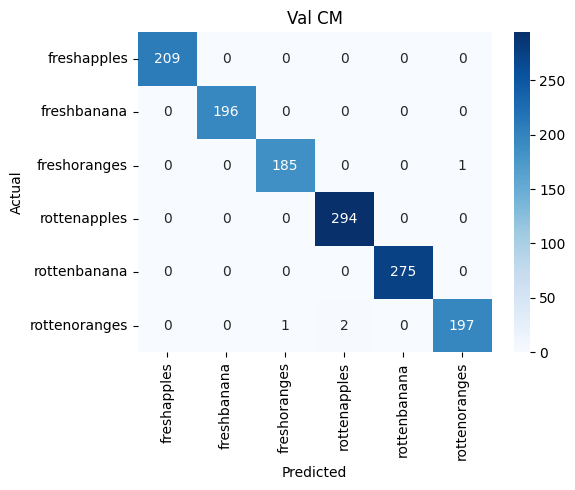

Mean PPV (Precision, macro): 0.9971
Cohen's Kappa: 0.9964
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 0.9998 / 0.9998
Inference time per image (val): 3.021 ms
Accuracy: 0.9971  95% CI: [0.9942, 0.9999]
Bootstrap Accuracy Mean=0.9972, Std=0.0013

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    1.0000    1.0000       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9893    1.0000    0.9946       185
 rottenapples     0.9966    1.0000    0.9983       294
 rottenbanana     1.0000    1.0000    1.0000       276
rottenoranges     1.0000    0.9850    0.9924       200

     accuracy                         0.9978      1360
    macro avg     0.9977    0.9975    0.9976      1360
 weighted avg     0.9978    0.9978    0.9978      1360



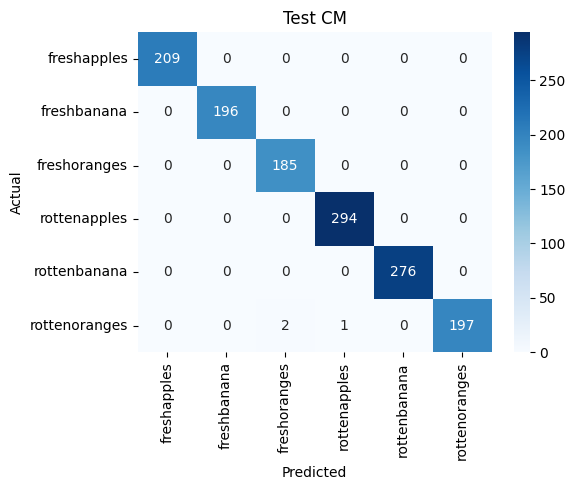

Mean PPV (Precision, macro): 0.9977
Cohen's Kappa: 0.9973
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 0.9998 / 0.9998
Inference time per image (test): 2.941 ms
Accuracy: 0.9978  95% CI: [0.9953, 1.0000]
Bootstrap Accuracy Mean=0.9979, Std=0.0014

Saved evaluation artifacts to: /kaggle/working/mobilevit/eval/eval_artifacts_mobilevit.joblib


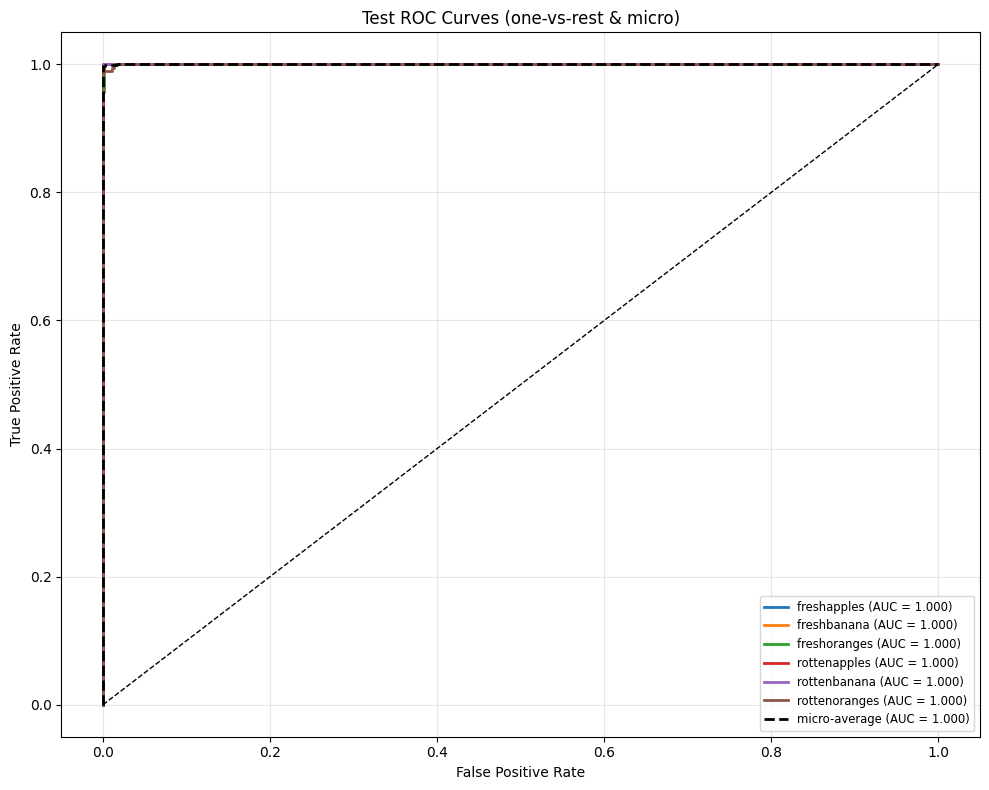

Saved ROC curves to: /kaggle/working/mobilevit/eval/test_roc_curves.png


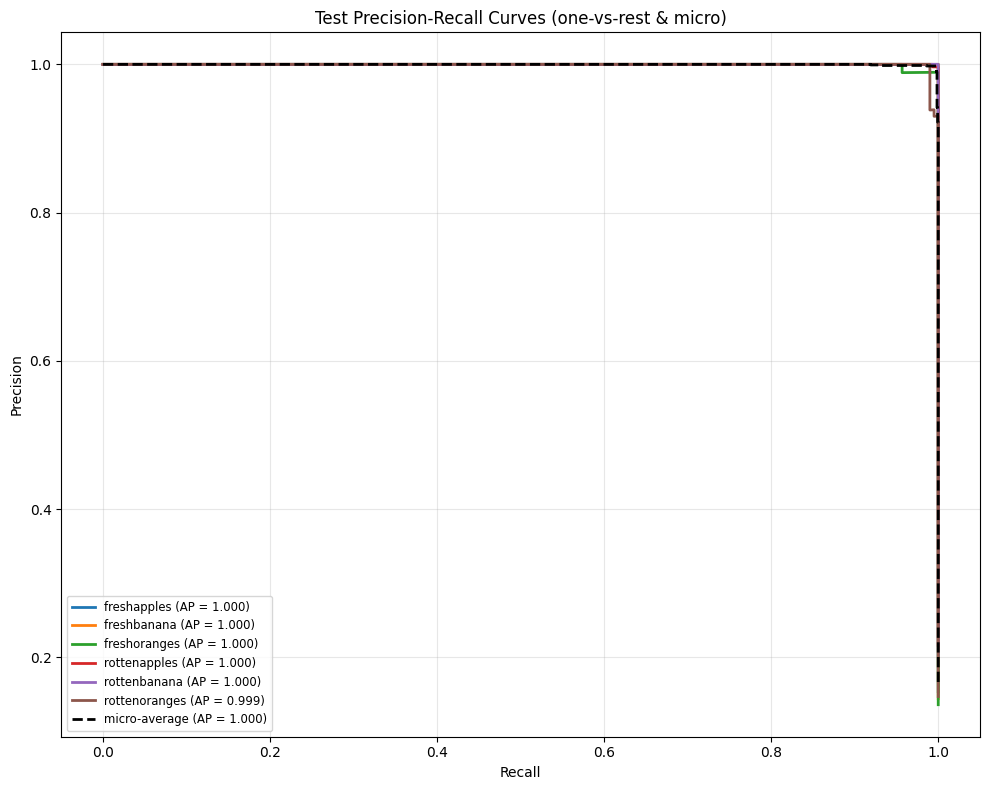

Saved PR curves to: /kaggle/working/mobilevit/eval/test_pr_curves.png


        TIME & MEMORY
Total Training Time: 481.22 sec
Average Time per Epoch: 60.15 sec
Max GPU Memory Allocated (GB): 2.971281408
Max GPU Memory Reserved  (GB): 3.531603968
CPU RAM Used (GB): 3.067080704
Inference Time per Image (single sample): 172.149 ms

Best checkpoint saved to: /kaggle/working/mobilevit/mobilevit_s_best_singlegpu.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
          Identity-2         [-1, 16, 112, 112]               0
              SiLU-3         [-1, 16, 112, 112]               0
    BatchNormAct2d-4         [-1, 16, 112, 112]              32
       ConvNormAct-5         [-1, 16, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]           1,024
          Identity-7         [-1, 64, 112, 112]  

In [8]:
import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_score, cohen_kappa_score
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
import psutil, joblib, cv2

# ---------- CONFIG ----------
MODEL_NAME = "mobilevit_s"
BASE_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
SPLIT_DIR = "/kaggle/working/split_dataset"   
OUT_DIR = "/kaggle/working/mobilevit"
EVAL_DIR = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
LABEL_SMOOTHING = 0.1

IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
BOOTSTRAP_SAMPLES = 500  

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this cell. Select GPU runtime.")
device = torch.device("cuda")
print("Using device:", device)
torch.backends.cudnn.benchmark = True

# --- Data paths & leakage check ---
TRAIN_DIR = os.path.join(SPLIT_ROOT, "train")
VAL_DIR   = os.path.join(SPLIT_ROOT, "val")
TEST_DIR  = os.path.join(SPLIT_ROOT, "test")

def list_files(root):
    exts = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff'); s=set()
    if not os.path.isdir(root): return s
    for cls in os.listdir(root):
        cls_dir=os.path.join(root,cls)
        if not os.path.isdir(cls_dir): continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(exts):
                s.add(os.path.abspath(os.path.join(cls_dir,f)))
    return s

train_files = list_files(TRAIN_DIR); val_files = list_files(VAL_DIR); test_files = list_files(TEST_DIR)
print("Split counts (train,val,test):", len(train_files), len(val_files), len(test_files))
if len(train_files & val_files) or len(train_files & test_files) or len(val_files & test_files):
    raise RuntimeError("DATA LEAKAGE DETECTED: overlapping files between splits. Fix Task-05 first.")
    
# -------- Transforms --------
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.25))
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def gather_class_image_pairs(root):
    pairs = []
    classes = []
    if not os.path.isdir(root):
        return pairs, classes
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir): continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                pairs.append((os.path.join(cls_dir, fn), cls))
    return pairs, classes

# -------- Dataset wrapper --------
class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        if isinstance(lbl, str):
            lbl = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

def list_files(folder):
    res = []
    if not os.path.isdir(folder):
        return res
    for root,_,files in os.walk(folder):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                res.append(os.path.join(root,f))
    return res

if os.path.isdir(SPLIT_DIR) and os.path.isdir(os.path.join(SPLIT_DIR,"train")):
    print("Using on-disk split at", SPLIT_DIR)
    train_pairs, classes_train = gather_class_image_pairs(os.path.join(SPLIT_DIR,"train"))
    val_pairs,   classes_val   = gather_class_image_pairs(os.path.join(SPLIT_DIR,"val"))
    test_pairs,  classes_test  = gather_class_image_pairs(os.path.join(SPLIT_DIR,"test"))
    classes = sorted(list(set(classes_train + classes_val + classes_test)))
    class_to_idx = {c:i for i,c in enumerate(classes)}
    train_items = train_pairs
    val_items   = val_pairs
    test_items  = test_pairs
else:
    print("split_dataset not found; building deterministic 80/10/10 from", BASE_DIR)
    all_items = []
    all_classes = set()
    for cand in (BASE_DIR, os.path.join(BASE_DIR,"train"), os.path.join(BASE_DIR,"test")):
        if not os.path.isdir(cand): continue
        for cls in sorted(os.listdir(cand)):
            cls_dir = os.path.join(cand, cls)
            if not os.path.isdir(cls_dir): continue
            for fn in sorted(os.listdir(cls_dir)):
                if fn.lower().endswith(IMG_EXTS):
                    all_items.append((os.path.join(cls_dir, fn), cls))
                    all_classes.add(cls)
    if len(all_items)==0:
        raise RuntimeError("No images found under BASE_DIR")
    classes = sorted(list(all_classes))
    class_to_idx = {c:i for i,c in enumerate(classes)}
    rnd = random.Random(SEED)
    rnd.shuffle(all_items)
    N = len(all_items)
    n_train = int(0.80 * N)
    n_val = int(0.10 * N)
    n_test = N - n_train - n_val
    train_items = all_items[:n_train]
    val_items   = all_items[n_train:n_train+n_val]
    test_items  = all_items[n_train+n_val:]
    print(f"Combined total images: {N} -> train {len(train_items)}, val {len(val_items)}, test {len(test_items)}")

# Create datasets & loaders
train_ds = ImagePathDataset(train_items, class_to_idx, transform=train_tfms)
val_ds   = ImagePathDataset(val_items,   class_to_idx, transform=eval_tfms)
test_ds  = ImagePathDataset(test_items,  class_to_idx, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

NUM_CLASSES = len(classes)
print("Classes:", classes)

# Quick leakage check
def _list_files_in(items):
    return set([os.path.abspath(p) for p,l in items])
train_files = _list_files_in(train_items); val_files = _list_files_in(val_items); test_files = _list_files_in(test_items)
if (train_files & val_files) or (train_files & test_files) or (val_files & test_files):
    raise RuntimeError("DATA LEAKAGE DETECTED: overlapping files between splits. Fix Task-05 first.")

# -------- Model creation with dropout injection --------
def inject_dropout_head(model, p=DROPOUT):
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Sequential(nn.Dropout(p), model.fc)
    elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Sequential(nn.Dropout(p), model.classifier)
    elif hasattr(model, "head"):
        h = model.head
        if isinstance(h, nn.Linear):
            model.head = nn.Sequential(nn.Dropout(p), h)
        elif isinstance(h, nn.Sequential):
            model.head = nn.Sequential(nn.Dropout(p), *list(h))

print("Creating model:", MODEL_NAME)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES, drop_rate=DROPOUT)
inject_dropout_head(model, p=DROPOUT)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5, verbose=True)
scaler = GradScaler()

# ---- Training loop ----
best_val_loss = float("inf")
early_cnt = 0
best_path = os.path.join(OUT_DIR, f"{MODEL_NAME}_best_singlegpu.pth")
os.makedirs(OUT_DIR, exist_ok=True)

epoch_times = []
train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = outputs.argmax(1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    # validation
    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            vloss += loss.item() * imgs.size(0)
            vcorrect += (preds == labels).sum().item()
            vtotal += imgs.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  "
          f"ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={epoch_time:.1f}s")

    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        early_cnt = 0
        torch.save({
            "model": MODEL_NAME,
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_loss": best_val_loss,
            "classes": classes,
            "cfg": {"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "dropout": DROPOUT, "lr": LR}
        }, best_path)
        print(" -> Saved best checkpoint:", best_path)
    else:
        early_cnt += 1
        if early_cnt >= PATIENCE:
            print("Early stopping triggered.")
            break

epochs_run = epoch
total_training_time = time.time() - train_start_time

# -------- Evaluation helpers --------
def infer(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), (np.array(y_prob) if len(y_prob)>0 else None)

def get_preds_and_probs(model, loader):
    model.eval()
    y_true=[]; y_pred=[]; y_score=[]
    total_images = 0
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)  
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            y_score.append(probs)
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            total_images += imgs.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed / total_images) * 1000.0 if total_images>0 else 0.0
    y_score = np.vstack(y_score) if len(y_score)>0 else np.zeros((len(y_true), NUM_CLASSES))
    return np.array(y_true), np.array(y_pred), y_score, time_per_image_ms

def plot_cm(cm, title, savefile):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(savefile, dpi=150); plt.show()

# Load best weights (single-gpu)
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
    print("Loaded checkpoint:", best_path, "epoch", ckpt.get("epoch", "N/A"))
else:
    print("Best checkpoint not found, using last weights.")
    
print("\n\n======================")
print("        METRICS")
print("======================")

# accuracy 95% CI 
def accuracy_ci(y_true, y_pred, alpha=0.05):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    z = 1.96  
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

print("\n=== TRAIN REPORT ===")
y_tr, p_tr, yscore_tr, time_per_image_tr = get_preds_and_probs(model, train_loader)
cm_tr = confusion_matrix(y_tr, p_tr)
print(classification_report(y_tr, p_tr, target_names=classes, digits=4))
plot_cm(cm_tr, "Train CM", os.path.join(EVAL_DIR,"cm_train.png"))

mean_ppv_train = precision_score(y_tr, p_tr, average='macro', zero_division=0)
cohens_kappa_train = cohen_kappa_score(y_tr, p_tr)
try:
    roc_auc_train_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_train_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_train_macro = float('nan'); roc_auc_train_micro = float('nan')
try:
    pr_auc_train_macro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro')
    pr_auc_train_micro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro')
except Exception:
    pr_auc_train_macro = float('nan'); pr_auc_train_micro = float('nan')

acc_tr, lo_tr, hi_tr = accuracy_ci(y_tr, p_tr)
boot_mean_tr, boot_std_tr = 0.0, 0.0
if len(y_tr)>0:
    accs = []
    n = len(y_tr)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_tr[idx] == p_tr[idx]))
    boot_mean_tr, boot_std_tr = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (Precision, macro): {mean_ppv_train:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_train:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_train_macro:.4f} / {roc_auc_train_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_train_macro:.4f} / {pr_auc_train_micro:.4f}")
print(f"Inference time per image (train): {time_per_image_tr:.3f} ms")
print(f"Accuracy: {acc_tr:.4f}  95% CI: [{lo_tr:.4f}, {hi_tr:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_tr:.4f}, Std={boot_std_tr:.4f}")

print("\n=== VAL REPORT ===")
y_v, p_v, yscore_v, time_per_image_v = get_preds_and_probs(model, val_loader)
cm_v = confusion_matrix(y_v, p_v)
print(classification_report(y_v, p_v, target_names=classes, digits=4))
plot_cm(cm_v, "Val CM", os.path.join(EVAL_DIR,"cm_val.png"))

mean_ppv_val = precision_score(y_v, p_v, average='macro', zero_division=0)
cohens_kappa_val = cohen_kappa_score(y_v, p_v)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_v, lo_v, hi_v = accuracy_ci(y_v, p_v)
boot_mean_v, boot_std_v = 0.0, 0.0
if len(y_v)>0:
    accs = []
    n = len(y_v)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_v[idx] == p_v[idx]))
    boot_mean_v, boot_std_v = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (Precision, macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_val:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_val_macro:.4f} / {roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_val_macro:.4f} / {pr_auc_val_micro:.4f}")
print(f"Inference time per image (val): {time_per_image_v:.3f} ms")
print(f"Accuracy: {acc_v:.4f}  95% CI: [{lo_v:.4f}, {hi_v:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_v:.4f}, Std={boot_std_v:.4f}")

print("\n=== TEST REPORT ===")
y_t, p_t, yscore_t, time_per_image_t = get_preds_and_probs(model, test_loader)
cm_t = confusion_matrix(y_t, p_t)
print(classification_report(y_t, p_t, target_names=classes, digits=4))
plot_cm(cm_t, "Test CM", os.path.join(EVAL_DIR,"cm_test.png"))

mean_ppv_test = precision_score(y_t, p_t, average='macro', zero_division=0)
cohens_kappa_test = cohen_kappa_score(y_t, p_t)
try:
    roc_auc_test_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro', multi_class='ovr')
    roc_auc_test_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro', multi_class='ovr')
except Exception:
    roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
try:
    pr_auc_test_macro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro')
    pr_auc_test_micro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro')
except Exception:
    pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

acc_t, lo_t, hi_t = accuracy_ci(y_t, p_t)
boot_mean_t, boot_std_t = 0.0, 0.0
if len(y_t)>0:
    accs = []
    n = len(y_t)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_t[idx] == p_t[idx]))
    boot_mean_t, boot_std_t = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (Precision, macro): {mean_ppv_test:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_test:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_test_macro:.4f} / {roc_auc_test_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_test_macro:.4f} / {pr_auc_test_micro:.4f}")
print(f"Inference time per image (test): {time_per_image_t:.3f} ms")
print(f"Accuracy: {acc_t:.4f}  95% CI: [{lo_t:.4f}, {hi_t:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_t:.4f}, Std={boot_std_t:.4f}")

artifacts = {
    "train": {"y": y_tr, "p": p_tr, "cm": cm_tr, "y_score": yscore_tr},
    "val":   {"y": y_v, "p": p_v, "cm": cm_v, "y_score": yscore_v},
    "test":  {"y": y_t, "p": p_t, "cm": cm_t, "y_score": yscore_t},
    "classes": classes
}
joblib.dump(artifacts, os.path.join(EVAL_DIR, "eval_artifacts_mobilevit.joblib"))
print("\nSaved evaluation artifacts to:", os.path.join(EVAL_DIR, "eval_artifacts_mobilevit.joblib"))

if len(y_t) > 0:
    y_true_onehot = np.eye(NUM_CLASSES)[y_t]  

    # ROC curves per class + micro
    plt.figure(figsize=(10, 8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(NUM_CLASSES):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_t[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC = {roc_auc[i]:.3f})")
   
    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_t.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    roc_out = os.path.join(EVAL_DIR, "test_roc_curves.png")
    plt.tight_layout(); plt.savefig(roc_out, dpi=150); plt.show()
    print("Saved ROC curves to:", roc_out)

    # Precision-Recall curves per class + micro-average
    plt.figure(figsize=(10, 8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(NUM_CLASSES):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_t[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_t[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"{classes[i]} (AP = {ap[i]:.3f})")
    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_t.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_t, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AP = {ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    pr_out = os.path.join(EVAL_DIR, "test_pr_curves.png")
    plt.tight_layout(); plt.savefig(pr_out, dpi=150); plt.show()
    print("Saved PR curves to:", pr_out)

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epochs_run:.2f} sec")

if torch.cuda.is_available():
    try:
        print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        print("Could not query CUDA memory stats via torch.cuda.")

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference time probe 
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0 = time.time()
    _ = model(sample)
    if device.type == 'cuda': torch.cuda.synchronize()
    infer_time = time.time() - t0
print(f"Inference Time per Image (single sample): {infer_time*1000:.3f} ms")

print("\nBest checkpoint saved to:", best_path)
print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))
    import pandas as pd
    df = pd.DataFrame(rows, columns=['name','shape','n_params','trainable'])
    display(df.head(200))

# **Levit_128s Model Training**

Using device: cuda
Using on-disk split at /kaggle/working/split_dataset
Split counts (train,val,test): 10879 1360 1360
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Creating model: levit_128s


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/336413044.py:204: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/336413044.py:222: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  TrainLoss=0.52230 TrainAcc=0.8179  ValLoss=0.32147 ValAcc=0.8956  epoch_time=52.7s
 -> Saved best checkpoint: /kaggle/working/levit_128s/levit_128s_best_singlegpu.pth
Epoch 2/40  TrainLoss=0.19714 TrainAcc=0.9331  ValLoss=0.10870 ValAcc=0.9625  epoch_time=52.7s
 -> Saved best checkpoint: /kaggle/working/levit_128s/levit_128s_best_singlegpu.pth
Epoch 3/40  TrainLoss=0.15346 TrainAcc=0.9474  ValLoss=0.15003 ValAcc=0.9397  epoch_time=52.8s
Epoch 4/40  TrainLoss=0.10915 TrainAcc=0.9602  ValLoss=0.04555 ValAcc=0.9824  epoch_time=53.0s
 -> Saved best checkpoint: /kaggle/working/levit_128s/levit_128s_best_singlegpu.pth
Epoch 5/40  TrainLoss=0.14214 TrainAcc=0.9518  ValLoss=0.06462 ValAcc=0.9824  epoch_time=53.3s
Epoch 6/40  TrainLoss=0.08835 TrainAcc=0.9708  ValLoss=0.10848 ValAcc=0.9603  epoch_time=53.1s
Epoch 7/40  TrainLoss=0.06809 TrainAcc=0.9778  ValLoss=0.09277 ValAcc=0.9699  epoch_time=53.0s
Early stopping triggered.
Loaded checkpoint: /kaggle/working/levit_128s/levit_128s_

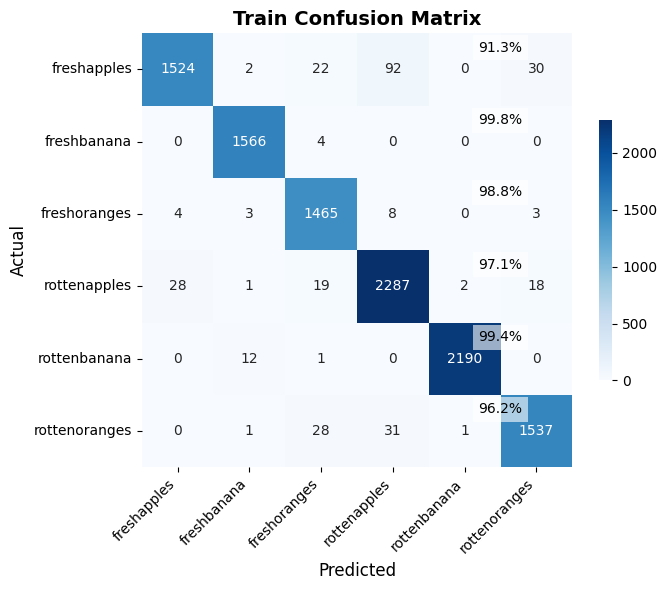

Mean PPV (Precision, macro): 0.9720
Cohen's Kappa: 0.9656
ROC AUC (macro / micro): 0.9993 / 0.9993
PR AUC  (macro / micro): 0.9968 / 0.9968
Inference time per image (train): 4.204 ms
Accuracy: 0.9715  95% CI: [0.9684, 0.9746]
Bootstrap Accuracy Mean=0.9716, Std=0.0015

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9899    0.9378    0.9631       209
  freshbanana     0.9949    0.9949    0.9949       196
 freshoranges     0.9684    0.9892    0.9787       186
 rottenapples     0.9574    0.9932    0.9750       294
 rottenbanana     0.9964    0.9964    0.9964       275
rottenoranges     0.9898    0.9700    0.9798       200

     accuracy                         0.9816      1360
    macro avg     0.9828    0.9803    0.9813      1360
 weighted avg     0.9819    0.9816    0.9816      1360



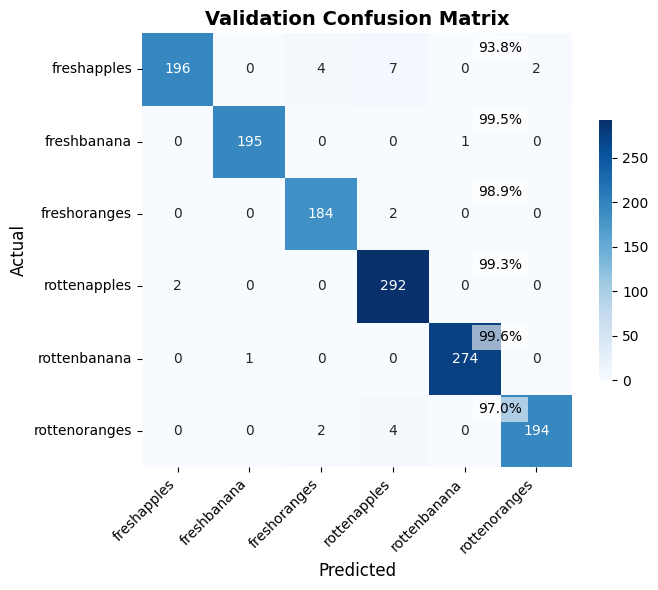

Mean PPV (Precision, macro): 0.9828
Cohen's Kappa: 0.9778
ROC AUC (macro / micro): 0.9999 / 0.9998
PR AUC  (macro / micro): 0.9992 / 0.9989
Inference time per image (val): 2.665 ms
Accuracy: 0.9816  95% CI: [0.9745, 0.9888]
Bootstrap Accuracy Mean=0.9818, Std=0.0035

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9949    0.9426    0.9681       209
  freshbanana     0.9898    0.9949    0.9924       196
 freshoranges     0.9733    0.9838    0.9785       185
 rottenapples     0.9541    0.9898    0.9716       294
 rottenbanana     1.0000    0.9964    0.9982       276
rottenoranges     0.9848    0.9750    0.9799       200

     accuracy                         0.9816      1360
    macro avg     0.9828    0.9804    0.9814      1360
 weighted avg     0.9820    0.9816    0.9816      1360



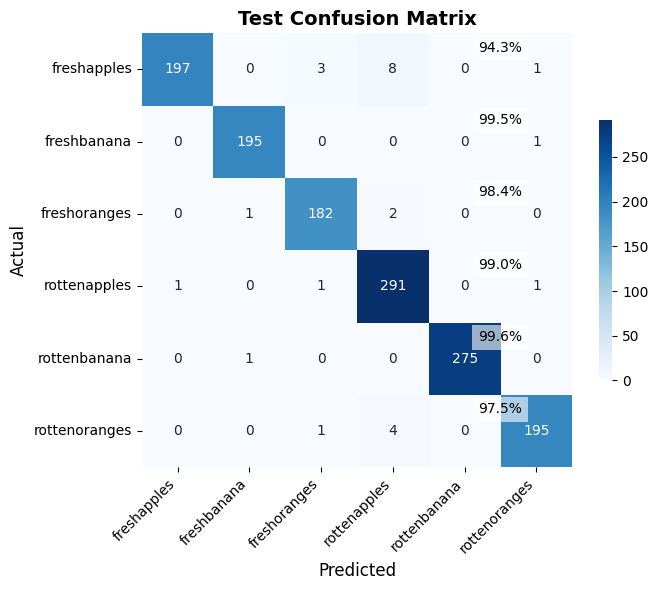

Mean PPV (Precision, macro): 0.9828
Cohen's Kappa: 0.9778
ROC AUC (macro / micro): 0.9998 / 0.9998
PR AUC  (macro / micro): 0.9992 / 0.9989
Inference time per image (test): 2.597 ms
Accuracy: 0.9816  95% CI: [0.9745, 0.9888]
Bootstrap Accuracy Mean=0.9818, Std=0.0036

Saved evaluation artifacts to: /kaggle/working/levit_128s/eval/eval_artifacts_levit128s.joblib


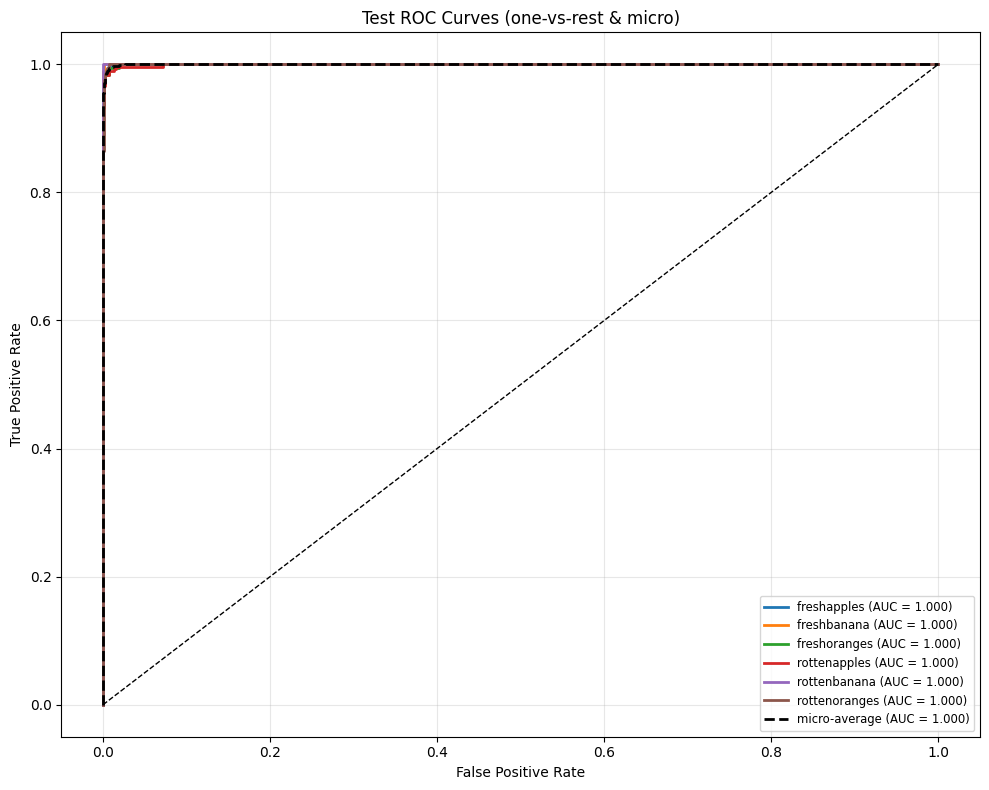

Saved ROC curves to: /kaggle/working/levit_128s/eval/test_roc_curves_levit128s.png


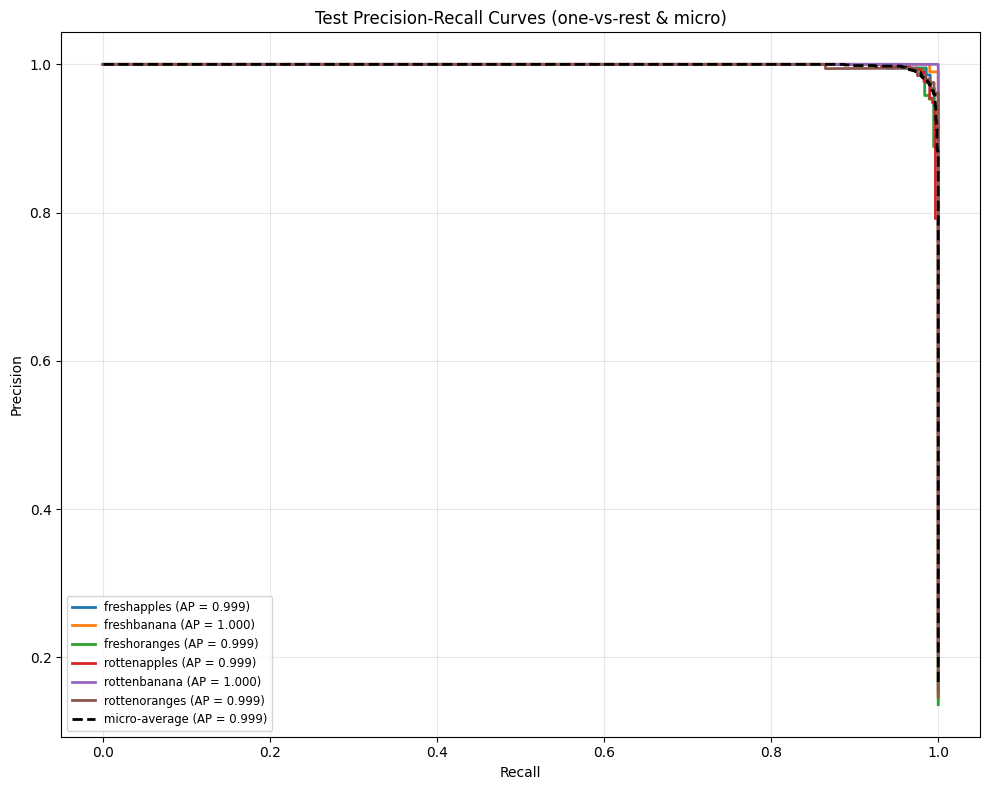

Saved PR curves to: /kaggle/working/levit_128s/eval/test_pr_curves_levit128s.png


        TIME & MEMORY
Total Training Time: 370.84 sec
Average Time per Epoch: 52.98 sec
Max GPU Memory Allocated (GB): 0.676410368
Max GPU Memory Reserved  (GB): 0.864026624
CPU RAM Used (GB): 3.363221504
Inference Time per Image (single sample): 11.343 ms

Best checkpoint saved to: /kaggle/working/levit_128s/levit_128s_best_singlegpu.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             432
       BatchNorm2d-2         [-1, 16, 112, 112]              32
          ConvNorm-3         [-1, 16, 112, 112]               0
         Hardswish-4         [-1, 16, 112, 112]               0
            Conv2d-5           [-1, 32, 56, 56]           4,608
       BatchNorm2d-6           [-1, 32, 56, 56]              64
          ConvNorm-7           [-1, 32,

In [11]:
import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
# metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_score, cohen_kappa_score
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
import psutil, joblib, cv2

# ---------- CONFIG ----------
MODEL_NAME = "levit_128s"
BASE_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
SPLIT_DIR = "/kaggle/working/split_dataset"  
OUT_DIR = "/kaggle/working/levit_128s"
EVAL_DIR = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4             
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5

IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
BOOTSTRAP_SAMPLES = 500 

# Reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this cell. Select GPU runtime.")
device = torch.device("cuda")
print("Using device:", device)
torch.backends.cudnn.benchmark = True

# -------- Transforms --------
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.25))
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------- Helpers --------
def gather_class_image_pairs(root):
    items = []
    classes = []
    if not os.path.isdir(root):
        return items, classes
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                items.append((os.path.join(cls_dir, fn), cls))
    return items, classes

def list_files(folder):
    """Return a set of absolute image file paths under folder (non-recursive per-class layout)."""
    s = set()
    if not os.path.isdir(folder):
        return s
    for cls in os.listdir(folder):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fn in os.listdir(cls_dir):
            if fn.lower().endswith(IMG_EXTS):
                s.add(os.path.abspath(os.path.join(cls_dir, fn)))
    return s

class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        if isinstance(lbl, str):
            lbl = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

# -------- Build dataset splits --------
TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")

if os.path.isdir(TRAIN_DIR) and os.path.isdir(VAL_DIR) and os.path.isdir(TEST_DIR):
    print("Using on-disk split at", SPLIT_DIR)
    train_items, train_classes = gather_class_image_pairs(TRAIN_DIR)
    val_items, val_classes     = gather_class_image_pairs(VAL_DIR)
    test_items, test_classes   = gather_class_image_pairs(TEST_DIR)
    classes = sorted(list(set(train_classes + val_classes + test_classes)))
    class_to_idx = {c:i for i,c in enumerate(classes)}
else:
    print("split_dataset not found; building deterministic 80/10/10 from", BASE_DIR)
    all_items = []
    all_classes = set()
    for cand in (BASE_DIR, os.path.join(BASE_DIR,"train"), os.path.join(BASE_DIR,"test")):
        if not os.path.isdir(cand):
            continue
        for cls in sorted(os.listdir(cand)):
            cls_dir = os.path.join(cand, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fn in sorted(os.listdir(cls_dir)):
                if fn.lower().endswith(IMG_EXTS):
                    all_items.append((os.path.join(cls_dir, fn), cls))
                    all_classes.add(cls)
    if len(all_items)==0:
        raise RuntimeError("No images found under BASE_DIR")
    classes = sorted(list(all_classes))
    class_to_idx = {c:i for i,c in enumerate(classes)}
    rnd = random.Random(SEED)
    rnd.shuffle(all_items)
    N = len(all_items)
    n_train = int(0.80 * N)
    n_val = int(0.10 * N)
    train_items = all_items[:n_train]
    val_items   = all_items[n_train:n_train+n_val]
    test_items  = all_items[n_train+n_val:]
    print(f"Combined total images: {N} -> train {len(train_items)}, val {len(val_items)}, test {len(test_items)}")

try:
    train_files = list_files(TRAIN_DIR) if os.path.isdir(TRAIN_DIR) else set([p for p,_ in train_items])
    val_files = list_files(VAL_DIR) if os.path.isdir(VAL_DIR) else set([p for p,_ in val_items])
    test_files = list_files(TEST_DIR) if os.path.isdir(TEST_DIR) else set([p for p,_ in test_items])
    print("Split counts (train,val,test):", len(train_files), len(val_files), len(test_files))
except Exception:
    pass

def _file_set(items): return set([os.path.abspath(p) for p,l in items])
tset, vset, teset = _file_set(train_items), _file_set(val_items), _file_set(test_items)
if (tset & vset) or (tset & teset) or (vset & teset):
    raise RuntimeError("DATA LEAKAGE DETECTED between splits — fix Task-05 split and retry.")

# Create datasets & loaders
train_ds = ImagePathDataset(train_items, class_to_idx, transform=train_tfms)
val_ds   = ImagePathDataset(val_items,   class_to_idx, transform=eval_tfms)
test_ds  = ImagePathDataset(test_items,  class_to_idx, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

NUM_CLASSES = len(classes)
print("Classes:", classes)

# -------- Model creation --------
def inject_dropout_head(model, p=DROPOUT):
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Sequential(nn.Dropout(p), model.fc)
    elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Sequential(nn.Dropout(p), model.classifier)
    elif hasattr(model, "head"):
        h = model.head
        if isinstance(h, nn.Linear):
            model.head = nn.Sequential(nn.Dropout(p), h)
        elif isinstance(h, nn.Sequential):
            model.head = nn.Sequential(nn.Dropout(p), *list(h))

print("Creating model:", MODEL_NAME)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES, drop_rate=DROPOUT)
inject_dropout_head(model, p=DROPOUT)
model = model.to(device)

# optimizer / scheduler / scaler / loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode= "min", patience=2, factor=0.5, verbose=True)
scaler = GradScaler()

# ---- Training loop ----
best_val_loss = float("inf")
early_cnt = 0
best_path = os.path.join(OUT_DIR, f"{MODEL_NAME}_best_singlegpu.pth")
os.makedirs(OUT_DIR, exist_ok=True)

epoch_times = []
train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = outputs.argmax(1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    # validation
    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            vloss += loss.item() * imgs.size(0)
            vcorrect += (preds == labels).sum().item()
            vtotal += imgs.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  "
          f"ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={epoch_time:.1f}s")

    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        early_cnt = 0
        torch.save({
            "model": MODEL_NAME,
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_loss": best_val_loss,
            "classes": classes,
            "cfg": {"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "dropout": DROPOUT, "lr": LR}
        }, best_path)
        print(" -> Saved best checkpoint:", best_path)
    else:
        early_cnt += 1
        if early_cnt >= PATIENCE:
            print("Early stopping triggered.")
            break

epochs_run = epoch
total_training_time = time.time() - train_start_time

# -------- Evaluation helpers --------
def infer(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), (np.array(y_prob) if len(y_prob)>0 else None)

def get_preds_and_probs(model, loader):
    model.eval()
    y_true=[]; y_pred=[]; y_score=[]
    total_images = 0
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)  
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            y_score.append(probs)
            y_pred.extend(preds)
            y_true.extend(labels.numpy())
            total_images += imgs.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed / total_images) * 1000.0 if total_images>0 else 0.0
    y_score = np.vstack(y_score) if len(y_score)>0 else np.zeros((len(y_true), NUM_CLASSES))
    return np.array(y_true), np.array(y_pred), y_score, time_per_image_ms

def plot_confusion(cm, labels, title, savefile=None):
    fig, ax = plt.subplots(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels, cbar_kws={"shrink":.6})
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        pct = (cm.diagonal() / (row_sums.squeeze()) * 100.0).round(2)
    for i, p in enumerate(pct):
        ax.text(cm.shape[1]-0.7, i+0.2, f"{p:.1f}%", color='black', fontsize=10, ha='right', va='center',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def compute_extra_metrics(cm):
    specificity = []
    npv = []
    for i in range(len(cm)):
        TP = cm[i,i]
        FN = cm[i,:].sum() - TP
        FP = cm[:,i].sum() - TP
        TN = cm.sum() - (TP+FP+FN)
        spec = TN / (TN + FP) if (TN+FP) > 0 else 0.0
        nv   = TN / (TN + FN) if (TN+FN) > 0 else 0.0
        specificity.append(spec)
        npv.append(nv)
    return specificity, npv, float(np.mean(specificity)), float(np.mean(npv))

def bootstrap_accuracy(y_true, y_pred, samples=BOOTSTRAP_SAMPLES):
    accs = []
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0
    for _ in range(samples):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_true[idx] == y_pred[idx]))
    return float(np.mean(accs)), float(np.std(accs))

# Load best weights (single-gpu)
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
    print("Loaded checkpoint:", best_path, "epoch", ckpt.get("epoch", "N/A"))
else:
    print("Best checkpoint not found, using last weights.")

print("\n\n======================")
print("        METRICS")
print("======================")

# accuracy 95% CI 
def accuracy_ci(y_true, y_pred, alpha=0.05):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    z = 1.96  
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

print("\n=== TRAIN REPORT ===")
y_tr, p_tr, yscore_tr, time_per_image_tr = get_preds_and_probs(model, train_loader)
cm_tr = confusion_matrix(y_tr, p_tr)
print(classification_report(y_tr, p_tr, target_names=classes, digits=4))
plot_confusion(cm_tr, classes, "Train Confusion Matrix", os.path.join(EVAL_DIR,"cm_train.png"))

mean_ppv_train = precision_score(y_tr, p_tr, average='macro', zero_division=0)
cohens_kappa_train = cohen_kappa_score(y_tr, p_tr)
try:
    roc_auc_train_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_train_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_train_macro = float('nan'); roc_auc_train_micro = float('nan')
try:
    pr_auc_train_macro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro')
    pr_auc_train_micro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro')
except Exception:
    pr_auc_train_macro = float('nan'); pr_auc_train_micro = float('nan')

acc_tr, lo_tr, hi_tr = accuracy_ci(y_tr, p_tr)
boot_mean_tr, boot_std_tr = bootstrap_accuracy(y_tr, p_tr, samples=min(BOOTSTRAP_SAMPLES,200))

print(f"Mean PPV (Precision, macro): {mean_ppv_train:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_train:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_train_macro:.4f} / {roc_auc_train_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_train_macro:.4f} / {pr_auc_train_micro:.4f}")
print(f"Inference time per image (train): {time_per_image_tr:.3f} ms")
print(f"Accuracy: {acc_tr:.4f}  95% CI: [{lo_tr:.4f}, {hi_tr:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_tr:.4f}, Std={boot_std_tr:.4f}")

print("\n=== VAL REPORT ===")
y_v, p_v, yscore_v, time_per_image_v = get_preds_and_probs(model, val_loader)
cm_v = confusion_matrix(y_v, p_v)
print(classification_report(y_v, p_v, target_names=classes, digits=4))
plot_confusion(cm_v, classes, "Validation Confusion Matrix", os.path.join(EVAL_DIR,"cm_val.png"))

mean_ppv_val = precision_score(y_v, p_v, average='macro', zero_division=0)
cohens_kappa_val = cohen_kappa_score(y_v, p_v)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_v, lo_v, hi_v = accuracy_ci(y_v, p_v)
boot_mean_v, boot_std_v = bootstrap_accuracy(y_v, p_v, samples=min(BOOTSTRAP_SAMPLES,200))

print(f"Mean PPV (Precision, macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_val:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_val_macro:.4f} / {roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_val_macro:.4f} / {pr_auc_val_micro:.4f}")
print(f"Inference time per image (val): {time_per_image_v:.3f} ms")
print(f"Accuracy: {acc_v:.4f}  95% CI: [{lo_v:.4f}, {hi_v:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_v:.4f}, Std={boot_std_v:.4f}")

print("\n=== TEST REPORT ===")
y_t, p_t, yscore_t, time_per_image_t = get_preds_and_probs(model, test_loader)
cm_t = confusion_matrix(y_t, p_t)
print(classification_report(y_t, p_t, target_names=classes, digits=4))
plot_confusion(cm_t, classes, "Test Confusion Matrix", os.path.join(EVAL_DIR,"cm_test.png"))

mean_ppv_test = precision_score(y_t, p_t, average='macro', zero_division=0)
cohens_kappa_test = cohen_kappa_score(y_t, p_t)
try:
    roc_auc_test_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro', multi_class='ovr')
    roc_auc_test_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro', multi_class='ovr')
except Exception:
    roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
try:
    pr_auc_test_macro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro')
    pr_auc_test_micro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro')
except Exception:
    pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

acc_t, lo_t, hi_t = accuracy_ci(y_t, p_t)
boot_mean_t, boot_std_t = bootstrap_accuracy(y_t, p_t, samples=min(BOOTSTRAP_SAMPLES,200))

print(f"Mean PPV (Precision, macro): {mean_ppv_test:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_test:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_test_macro:.4f} / {roc_auc_test_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_test_macro:.4f} / {pr_auc_test_micro:.4f}")
print(f"Inference time per image (test): {time_per_image_t:.3f} ms")
print(f"Accuracy: {acc_t:.4f}  95% CI: [{lo_t:.4f}, {hi_t:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_t:.4f}, Std={boot_std_t:.4f}")

artifacts = {
    "train": {"y": y_tr, "p": p_tr, "cm": cm_tr, "y_score": yscore_tr},
    "val":   {"y": y_v, "p": p_v, "cm": cm_v, "y_score": yscore_v},
    "test":  {"y": y_t, "p": p_t, "cm": cm_t, "y_score": yscore_t},
    "classes": classes
}
joblib.dump(artifacts, os.path.join(EVAL_DIR, "eval_artifacts_levit128s.joblib"))
print("\nSaved evaluation artifacts to:", os.path.join(EVAL_DIR, "eval_artifacts_levit128s.joblib"))

# === Test ROC and PR curves (multiclass One-vs-Rest + micro-average) ===
if len(y_t) > 0:
    y_true_onehot = np.eye(NUM_CLASSES)[y_t] 

    # ROC curves per class + micro
    plt.figure(figsize=(10, 8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(NUM_CLASSES):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_t[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC = {roc_auc[i]:.3f})")

    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_t.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    roc_out = os.path.join(EVAL_DIR, "test_roc_curves_levit128s.png")
    plt.tight_layout(); plt.savefig(roc_out, dpi=150); plt.show()
    print("Saved ROC curves to:", roc_out)

    # Precision-Recall curves per class + micro-average
    plt.figure(figsize=(10, 8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(NUM_CLASSES):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_t[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_t[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"{classes[i]} (AP = {ap[i]:.3f})")
   
    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_t.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_t, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AP = {ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    pr_out = os.path.join(EVAL_DIR, "test_pr_curves_levit128s.png")
    plt.tight_layout(); plt.savefig(pr_out, dpi=150); plt.show()
    print("Saved PR curves to:", pr_out)

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epochs_run:.2f} sec")

if torch.cuda.is_available():
    try:
        print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        print("Could not query CUDA memory stats via torch.cuda.")

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference time probe (single sample)
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0 = time.time()
    _ = model(sample)
    if device.type == 'cuda': torch.cuda.synchronize()
    infer_time = time.time() - t0
print(f"Inference Time per Image (single sample): {infer_time*1000:.3f} ms")

print("\nBest checkpoint saved to:", best_path)
print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))
    import pandas as pd
    df = pd.DataFrame(rows, columns=['name','shape','n_params','trainable'])
    display(df.head(200))

# **Deit_tiny_patch16_224 Model Training**

Device: cuda CUDA_VISIBLE_DEVICES: None
Using split_dataset at /kaggle/working/split_dataset
Classes detected: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Split Count -> train: 10879 val: 1360 test: 1360
Creating model: deit_tiny_patch16_224


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/907536901.py:174: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/907536901.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  TrainLoss=0.60061 TrainAcc=0.9293  ValLoss=0.55212 ValAcc=0.9390  epoch_time=52.0s
 -> Saved best checkpoint: /kaggle/working/deit_tiny_patch16_224_run/deit_tiny_patch16_224_best.pth
Epoch 2/40  TrainLoss=0.50742 TrainAcc=0.9691  ValLoss=0.48593 ValAcc=0.9691  epoch_time=51.9s
 -> Saved best checkpoint: /kaggle/working/deit_tiny_patch16_224_run/deit_tiny_patch16_224_best.pth
Epoch 3/40  TrainLoss=0.49280 TrainAcc=0.9762  ValLoss=0.44182 ValAcc=0.9926  epoch_time=51.3s
 -> Saved best checkpoint: /kaggle/working/deit_tiny_patch16_224_run/deit_tiny_patch16_224_best.pth
Epoch 4/40  TrainLoss=0.48949 TrainAcc=0.9770  ValLoss=0.45434 ValAcc=0.9838  epoch_time=51.0s
Epoch 5/40  TrainLoss=0.48719 TrainAcc=0.9767  ValLoss=0.46335 ValAcc=0.9853  epoch_time=50.7s
Epoch 6/40  TrainLoss=0.46733 TrainAcc=0.9859  ValLoss=0.46198 ValAcc=0.9801  epoch_time=50.9s
Early stopping triggered.
Loaded checkpoint: /kaggle/working/deit_tiny_patch16_224_run/deit_tiny_patch16_224_best.pth epoch 3


  

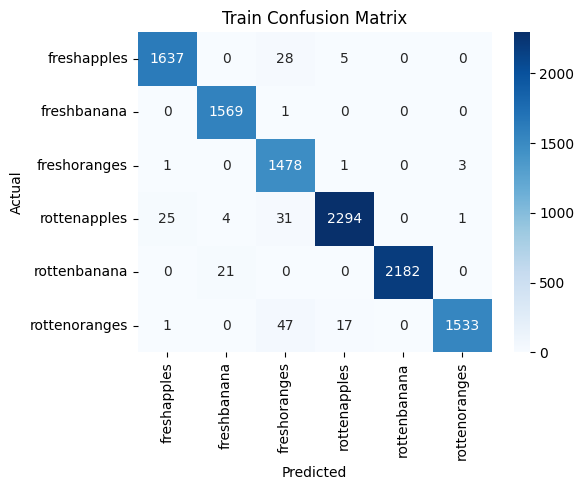

Mean PPV (macro): 0.9813
Cohen's Kappa: 0.9794
ROC AUC (macro/micro): 0.9997/0.9996
PR AUC  (macro/micro): 0.9985/0.9978
Inference time per image (train): 4.236 ms
Accuracy: 0.9829 95% CI: [0.9805, 0.9853]
Bootstrap Accuracy mean/std: 0.9828/0.0011

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9952    0.9856    0.9904       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9538    1.0000    0.9764       186
 rottenapples     1.0000    0.9966    0.9983       294
 rottenbanana     1.0000    1.0000    1.0000       275
rottenoranges     1.0000    0.9700    0.9848       200

     accuracy                         0.9926      1360
    macro avg     0.9915    0.9920    0.9916      1360
 weighted avg     0.9929    0.9926    0.9927      1360



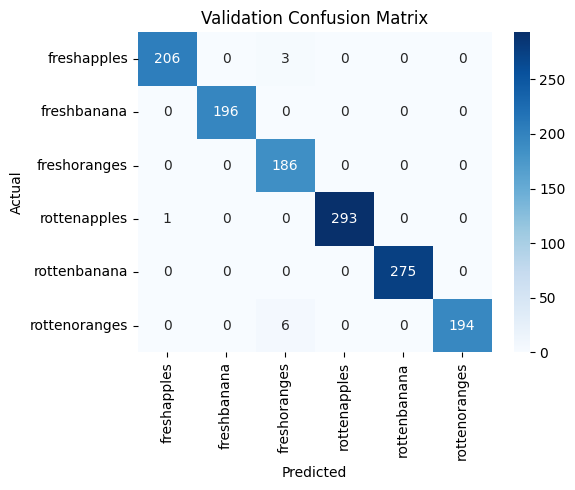

Mean PPV (macro): 0.9915
Cohen's Kappa: 0.9911
ROC AUC (macro/micro): 0.9999/0.9998
PR AUC  (macro/micro): 0.9995/0.9986
Inference time per image (val): 2.613 ms
Accuracy: 0.9926 95% CI: [0.9881, 0.9972]
Bootstrap Accuracy mean/std: 0.9928/0.0023

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9854    0.9665    0.9758       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9487    1.0000    0.9737       185
 rottenapples     0.9966    0.9864    0.9915       294
 rottenbanana     1.0000    1.0000    1.0000       276
rottenoranges     1.0000    0.9850    0.9924       200

     accuracy                         0.9897      1360
    macro avg     0.9884    0.9897    0.9889      1360
 weighted avg     0.9900    0.9897    0.9897      1360



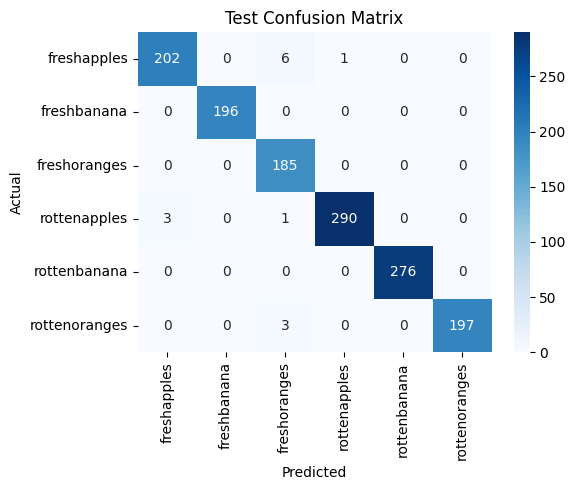

Mean PPV (macro): 0.9884
Cohen's Kappa: 0.9876
ROC AUC (macro/micro): 0.9997/0.9995
PR AUC  (macro/micro): 0.9981/0.9966
Inference time per image (test): 2.665 ms
Accuracy: 0.9897 95% CI: [0.9843, 0.9951]
Bootstrap Accuracy mean/std: 0.9897/0.0028

Saved evaluation artifacts to: /kaggle/working/deit_tiny_patch16_224_run/eval/eval_artifacts_deit.joblib


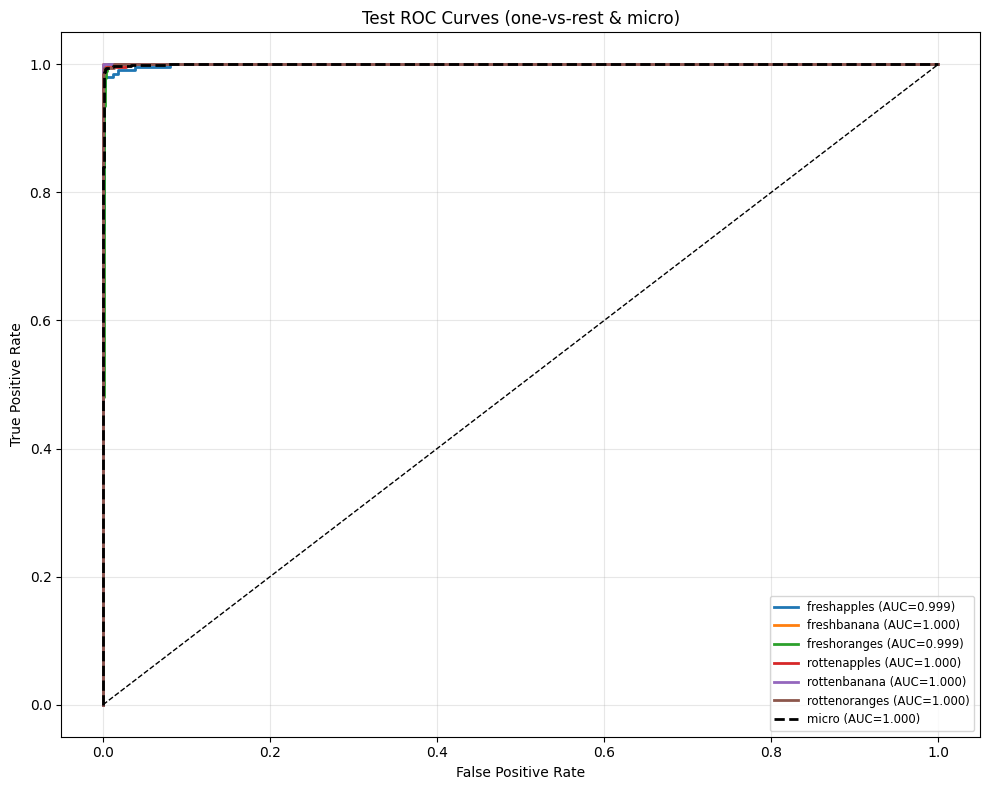

Saved ROC curves to: /kaggle/working/deit_tiny_patch16_224_run/eval/test_roc_deit.png


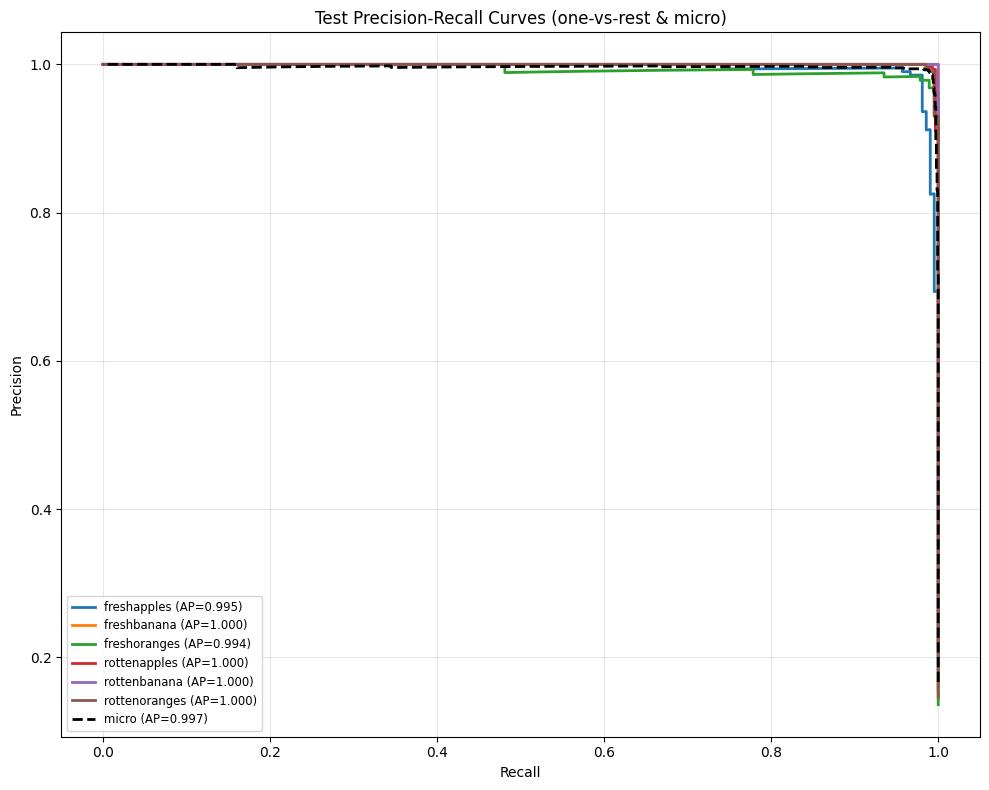

Saved PR curves to: /kaggle/working/deit_tiny_patch16_224_run/eval/test_pr_deit.png


        TIME & MEMORY
Total Training Time: 307.92 sec
Average Time per Epoch: 51.32 sec
Max GPU Memory Allocated (GB): 0.720952832
Max GPU Memory Reserved  (GB): 0.864026624
CPU RAM Used (GB): 2.706522112
Inference Time per Image (single sample): 6.105 ms

Best weights saved to: /kaggle/working/deit_tiny_patch16_224_run/deit_tiny_patch16_224_best.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 192, 14, 14]         147,648
          Identity-2             [-1, 196, 192]               0
        PatchEmbed-3             [-1, 196, 192]               0
           Dropout-4             [-1, 197, 192]               0
          Identity-5             [-1, 197, 192]               0
          Identity-6             [-1, 197, 192]               0
         LayerNorm-7    

In [7]:
import os, time, random
from pathlib import Path
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import psutil, joblib, pandas as pd
from sklearn.metrics import precision_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

# ---------- USER CONFIG ----------
MODEL_NAME = "deit_tiny_patch16_224"
SPLIT_DIR = "/kaggle/working/split_dataset"     
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_run"
EVAL_DIR = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
LABEL_SMOOTHING = 0.1
IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
BOOTSTRAP_SAMPLES = 500

# Reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this cell. Make sure a GPU runtime is selected.")
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print("Device:", device, "CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

# ---- Transforms ----
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.25))
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ---- Dataset gatherer ----
def gather_pairs(folder):
    items, classes = [], []
    if not os.path.isdir(folder):
        return items, classes
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir): continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                items.append((os.path.join(cls_dir, fn), cls))
    return items, classes

# ---- Build train/val/test lists ----
if os.path.isdir(os.path.join(SPLIT_DIR, "train")):
    print("Using split_dataset at", SPLIT_DIR)
    train_items, train_classes = gather_pairs(os.path.join(SPLIT_DIR, "train"))
    val_items, val_classes     = gather_pairs(os.path.join(SPLIT_DIR, "val"))
    test_items, test_classes   = gather_pairs(os.path.join(SPLIT_DIR, "test"))
    classes = sorted(list(set(train_classes + val_classes + test_classes)))
    class_to_idx = {c:i for i,c in enumerate(classes)}
else:
    BASE_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
    print("split_dataset not found — building deterministic 80/10/10 from", BASE_DIR)
    all_items = []
    all_classes = set()
    for cand in (BASE_DIR, os.path.join(BASE_DIR,"train"), os.path.join(BASE_DIR,"test")):
        if not os.path.isdir(cand): continue
        for cls in sorted(os.listdir(cand)):
            cls_dir = os.path.join(cand, cls)
            if not os.path.isdir(cls_dir): continue
            for fn in sorted(os.listdir(cls_dir)):
                if fn.lower().endswith(IMG_EXTS):
                    all_items.append((os.path.join(cls_dir, fn), cls))
                    all_classes.add(cls)
    if len(all_items) == 0:
        raise RuntimeError("No images found under dataset base path.")
    classes = sorted(list(all_classes))
    class_to_idx = {c:i for i,c in enumerate(classes)}
    rnd = random.Random(SEED)
    rnd.shuffle(all_items)
    N = len(all_items)
    n_train = int(0.80 * N)
    n_val = int(0.10 * N)
    train_items = all_items[:n_train]
    val_items   = all_items[n_train:n_train+n_val]
    test_items  = all_items[n_train+n_val:]

print("Classes detected:", classes)
print("Split Count -> train:", len(train_items), "val:", len(val_items), "test:", len(test_items))

def _file_set(items): return set([os.path.abspath(p) for p,l in items])
tset, vset, teset = _file_set(train_items), _file_set(val_items), _file_set(test_items)
if (tset & vset) or (tset & teset) or (vset & teset):
    raise RuntimeError("DATA LEAKAGE DETECTED between splits — fix Task-05 split and retry.")

# ---- Dataset wrapper ----
class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        if isinstance(lbl, str):
            lbl = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

train_ds = ImagePathDataset(train_items, class_to_idx, transform=train_tfms)
val_ds   = ImagePathDataset(val_items,   class_to_idx, transform=eval_tfms)
test_ds  = ImagePathDataset(test_items,  class_to_idx, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

# ---- Create model ----
def inject_dropout_head(model, p=DROPOUT):
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Sequential(nn.Dropout(p), model.head)
    elif hasattr(model, "classifier"):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Sequential(nn.Dropout(p), c)
        elif isinstance(c, nn.Sequential):
            model.classifier = nn.Sequential(nn.Dropout(p), *list(c))
    elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Sequential(nn.Dropout(p), model.fc)
    else:
        try:
            if hasattr(model, "head") and isinstance(model.head, nn.Sequential):
                model.head = nn.Sequential(nn.Dropout(p), *list(model.head))
        except Exception:
            pass

print("Creating model:", MODEL_NAME)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(classes), drop_rate=DROPOUT)
inject_dropout_head(model, p=DROPOUT)
model = model.to(device)

# ---- optimizer / scheduler / AMP scaler / loss ----
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5, verbose=True)
scaler = GradScaler()

# ---- Training loop ----
best_val_loss = float("inf")
early_cnt = 0
best_path = os.path.join(OUT_DIR, f"{MODEL_NAME}_best.pth")
os.makedirs(OUT_DIR, exist_ok=True)

epoch_times = []
train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = outputs.argmax(1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    # validation
    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            vloss += loss.item() * imgs.size(0)
            vcorrect += (preds == labels).sum().item()
            vtotal += imgs.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  "
          f"ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={epoch_time:.1f}s")

    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        early_cnt = 0
        torch.save({
            "model": MODEL_NAME,
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_loss": best_val_loss,
            "classes": classes,
            "cfg": {"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "dropout": DROPOUT, "lr": LR}
        }, best_path)
        print(" -> Saved best checkpoint:", best_path)
    else:
        early_cnt += 1
        if early_cnt >= PATIENCE:
            print("Early stopping triggered.")
            break

epochs_run = epoch
total_training_time = time.time() - train_start_time

# ---- Evaluation helpers + report enhancements ----
NUM_CLASSES = len(classes)

def get_preds_and_probs(model, loader):
    """Return y_true, y_pred, y_score(probabilities), time_per_image_ms"""
    model.eval()
    ys, ps, scores = [], [], []
    total = 0
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            scores.append(probs)
            ps.extend(preds)
            ys.extend(labels.numpy())
            total += imgs.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed/total)*1000.0 if total>0 else 0.0
    y_score = np.vstack(scores) if len(scores)>0 else np.zeros((len(ys), NUM_CLASSES))
    return np.array(ys), np.array(ps), y_score, time_per_image_ms

def plot_confusion(cm, title, savefile):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(savefile, dpi=150); plt.show()

def accuracy_ci(y_true, y_pred, z=1.96):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

# load best weights
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["state_dict"] if "state_dict" in ckpt else ckpt)
    print("Loaded checkpoint:", best_path, "epoch", ckpt.get("epoch", "N/A"))
else:
    print("Best checkpoint not found; using last epoch weights.")

print("\n\n======================")
print("        METRICS")
print("======================")

print("\n=== TRAIN REPORT ===")
y_tr, p_tr, yscore_tr, tpi_tr = get_preds_and_probs(model, train_loader)
cm_tr = confusion_matrix(y_tr, p_tr)
print(classification_report(y_tr, p_tr, target_names=classes, digits=4))
plot_confusion(cm_tr, "Train Confusion Matrix", os.path.join(EVAL_DIR, "cm_train.png"))

mean_ppv_tr = precision_score(y_tr, p_tr, average='macro', zero_division=0)
kappa_tr = cohen_kappa_score(y_tr, p_tr)
try:
    roc_auc_tr_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_tr_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_tr_macro = float('nan'); roc_auc_tr_micro = float('nan')
try:
    pr_auc_tr_macro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro')
    pr_auc_tr_micro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro')
except Exception:
    pr_auc_tr_macro = float('nan'); pr_auc_tr_micro = float('nan')

acc_tr, lo_tr, hi_tr = accuracy_ci(y_tr, p_tr)
boot_mean_tr, boot_std_tr = 0.0, 0.0
if len(y_tr) > 0:
    accs = []
    n = len(y_tr)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_tr[idx] == p_tr[idx]))
    boot_mean_tr, boot_std_tr = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_tr:.4f}")
print(f"Cohen's Kappa: {kappa_tr:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_tr_macro:.4f}/{roc_auc_tr_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_tr_macro:.4f}/{pr_auc_tr_micro:.4f}")
print(f"Inference time per image (train): {tpi_tr:.3f} ms")
print(f"Accuracy: {acc_tr:.4f} 95% CI: [{lo_tr:.4f}, {hi_tr:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_tr:.4f}/{boot_std_tr:.4f}")

print("\n=== VAL REPORT ===")
y_val, p_val, yscore_val, tpi_val = get_preds_and_probs(model, val_loader)
cm_val = confusion_matrix(y_val, p_val)
print(classification_report(y_val, p_val, target_names=classes, digits=4))
plot_confusion(cm_val, "Validation Confusion Matrix", os.path.join(EVAL_DIR, "cm_val.png"))

mean_ppv_val = precision_score(y_val, p_val, average='macro', zero_division=0)
kappa_val = cohen_kappa_score(y_val, p_val)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_val, lo_val, hi_val = accuracy_ci(y_val, p_val)
boot_mean_val, boot_std_val = 0.0, 0.0
if len(y_val) > 0:
    accs = []
    n = len(y_val)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_val[idx] == p_val[idx]))
    boot_mean_val, boot_std_val = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {kappa_val:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_val_macro:.4f}/{roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_val_macro:.4f}/{pr_auc_val_micro:.4f}")
print(f"Inference time per image (val): {tpi_val:.3f} ms")
print(f"Accuracy: {acc_val:.4f} 95% CI: [{lo_val:.4f}, {hi_val:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_val:.4f}/{boot_std_val:.4f}")

print("\n=== TEST REPORT ===")
y_test, p_test, yscore_test, tpi_test = get_preds_and_probs(model, test_loader)
cm_test = confusion_matrix(y_test, p_test)
print(classification_report(y_test, p_test, target_names=classes, digits=4))
plot_confusion(cm_test, "Test Confusion Matrix", os.path.join(EVAL_DIR, "cm_test.png"))

mean_ppv_test = precision_score(y_test, p_test, average='macro', zero_division=0)
kappa_test = cohen_kappa_score(y_test, p_test)
try:
    roc_auc_test_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='macro', multi_class='ovr')
    roc_auc_test_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='micro', multi_class='ovr')
except Exception:
    roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
try:
    pr_auc_test_macro = average_precision_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='macro')
    pr_auc_test_micro = average_precision_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='micro')
except Exception:
    pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

acc_test, lo_test, hi_test = accuracy_ci(y_test, p_test)
boot_mean_test, boot_std_test = 0.0, 0.0
if len(y_test) > 0:
    accs = []
    n = len(y_test)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_test[idx] == p_test[idx]))
    boot_mean_test, boot_std_test = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_test:.4f}")
print(f"Cohen's Kappa: {kappa_test:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_test_macro:.4f}/{roc_auc_test_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_test_macro:.4f}/{pr_auc_test_micro:.4f}")
print(f"Inference time per image (test): {tpi_test:.3f} ms")
print(f"Accuracy: {acc_test:.4f} 95% CI: [{lo_test:.4f}, {hi_test:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_test:.4f}/{boot_std_test:.4f}")

# Save evaluation artifacts 
artifacts = {
    "train": {"y": y_tr, "p": p_tr, "cm": cm_tr, "y_score": yscore_tr},
    "val":   {"y": y_val, "p": p_val, "cm": cm_val, "y_score": yscore_val},
    "test":  {"y": y_test, "p": p_test, "cm": cm_test, "y_score": yscore_test},
    "classes": classes
}
joblib.dump(artifacts, os.path.join(EVAL_DIR, "eval_artifacts_deit.joblib"))
print("\nSaved evaluation artifacts to:", os.path.join(EVAL_DIR, "eval_artifacts_deit.joblib"))

# === Test ROC and PR curves (multiclass One-vs-Rest + micro-average) ===
if len(y_test) > 0:
    y_true_onehot = np.eye(NUM_CLASSES)[y_test]

    # ROC per class
    plt.figure(figsize=(10,8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(NUM_CLASSES):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_test[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")
    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_test.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro (AUC={roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    roc_path = os.path.join(EVAL_DIR, "test_roc_deit.png")
    plt.tight_layout(); plt.savefig(roc_path, dpi=150); plt.show()
    print("Saved ROC curves to:", roc_path)

    # PR curves
    plt.figure(figsize=(10,8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(NUM_CLASSES):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_test[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_test[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"{classes[i]} (AP={ap[i]:.3f})")
    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_test.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_test, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro (AP={ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    pr_path = os.path.join(EVAL_DIR, "test_pr_deit.png")
    plt.tight_layout(); plt.savefig(pr_path, dpi=150); plt.show()
    print("Saved PR curves to:", pr_path)

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epochs_run:.2f} sec")

if torch.cuda.is_available():
    try:
        print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        print("Could not query CUDA memory stats via torch.cuda.")

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference time (single sample)
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0 = time.time(); _ = model(sample)
    if device.type=='cuda': torch.cuda.synchronize()
    infer_time = time.time() - t0
print(f"Inference Time per Image (single sample): {infer_time*1000:.3f} ms")

print("\nBest weights saved to:", best_path)
print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))
    df = pd.DataFrame(rows, columns=['name','shape','n_params','trainable'])
    display(df.head(200))

# **Efficientnet_b0 Model Training**

Using device: cuda
Classes detected: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Split counts (train,val,test): 10879 1360 1360
Creating model: efficientnet_b0


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/4186969298.py:150: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/4186969298.py:168: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  TrainLoss=1.05856 TrainAcc=0.8574  ValLoss=0.52255 ValAcc=0.9713  epoch_time=55.6s
 -> Saved best checkpoint: /kaggle/working/efficientnet_b0_run/efficientnet_b0_best_singlegpu.pth
Epoch 2/40  TrainLoss=0.52674 TrainAcc=0.9737  ValLoss=0.44046 ValAcc=0.9985  epoch_time=55.7s
 -> Saved best checkpoint: /kaggle/working/efficientnet_b0_run/efficientnet_b0_best_singlegpu.pth
Epoch 3/40  TrainLoss=0.48503 TrainAcc=0.9856  ValLoss=0.45077 ValAcc=0.9934  epoch_time=54.6s
Epoch 4/40  TrainLoss=0.47336 TrainAcc=0.9871  ValLoss=0.45344 ValAcc=0.9904  epoch_time=55.9s
Epoch 5/40  TrainLoss=0.47307 TrainAcc=0.9847  ValLoss=0.45917 ValAcc=0.9816  epoch_time=55.6s
Early stopping triggered.
Loaded checkpoint: /kaggle/working/efficientnet_b0_run/efficientnet_b0_best_singlegpu.pth epoch 2


        METRICS

=== TRAIN REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9988    0.9970    0.9979      1670
  freshbanana     1.0000    1.0000    1.0000      1570

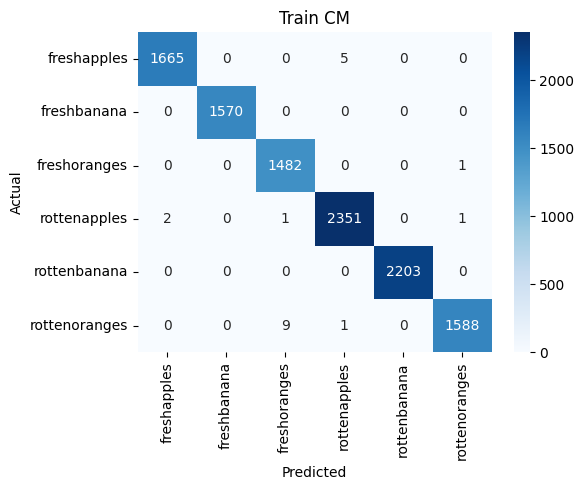

Mean PPV (Precision, macro): 0.9980
Cohen's Kappa: 0.9978
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 0.9998 / 0.9999
Inference time per image (train): 4.393 ms
Accuracy: 0.9982  95% CI: [0.9974, 0.9990]
Bootstrap Accuracy Mean=0.9982, Std=0.0004

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    1.0000    1.0000       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     0.9947    1.0000    0.9973       186
 rottenapples     1.0000    0.9966    0.9983       294
 rottenbanana     1.0000    1.0000    1.0000       275
rottenoranges     0.9950    0.9950    0.9950       200

     accuracy                         0.9985      1360
    macro avg     0.9983    0.9986    0.9984      1360
 weighted avg     0.9985    0.9985    0.9985      1360



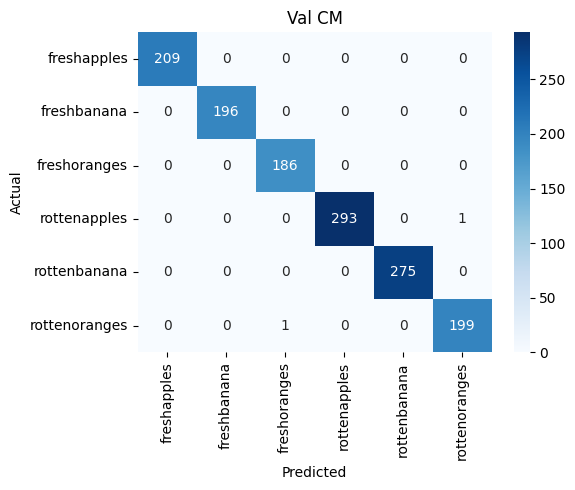

Mean PPV (Precision, macro): 0.9983
Cohen's Kappa: 0.9982
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 0.9999 / 1.0000
Inference time per image (val): 2.685 ms
Accuracy: 0.9985  95% CI: [0.9965, 1.0000]
Bootstrap Accuracy Mean=0.9985, Std=0.0010

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     1.0000    1.0000    1.0000       209
  freshbanana     0.9849    1.0000    0.9924       196
 freshoranges     0.9890    0.9730    0.9809       185
 rottenapples     1.0000    1.0000    1.0000       294
 rottenbanana     1.0000    1.0000    1.0000       276
rottenoranges     0.9900    0.9900    0.9900       200

     accuracy                         0.9949      1360
    macro avg     0.9940    0.9938    0.9939      1360
 weighted avg     0.9949    0.9949    0.9948      1360



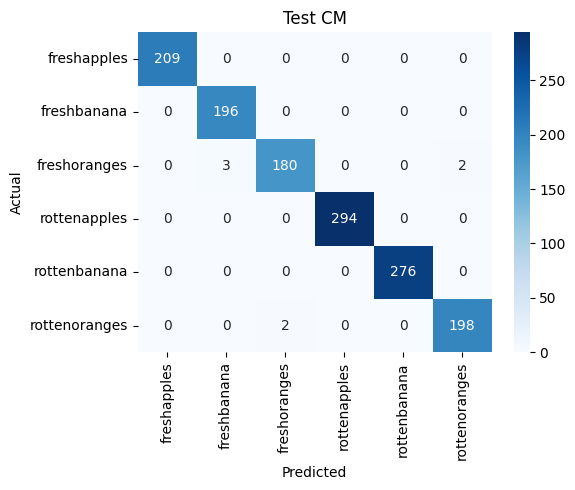

Mean PPV (Precision, macro): 0.9940
Cohen's Kappa: 0.9938
ROC AUC (macro / micro): 1.0000 / 1.0000
PR AUC  (macro / micro): 0.9998 / 0.9999
Inference time per image (test): 2.760 ms
Accuracy: 0.9949  95% CI: [0.9910, 0.9987]
Bootstrap Accuracy Mean=0.9947, Std=0.0019

Saved evaluation artifacts to: /kaggle/working/efficientnet_b0_run/eval/eval_artifacts_efficientnet_b0.joblib


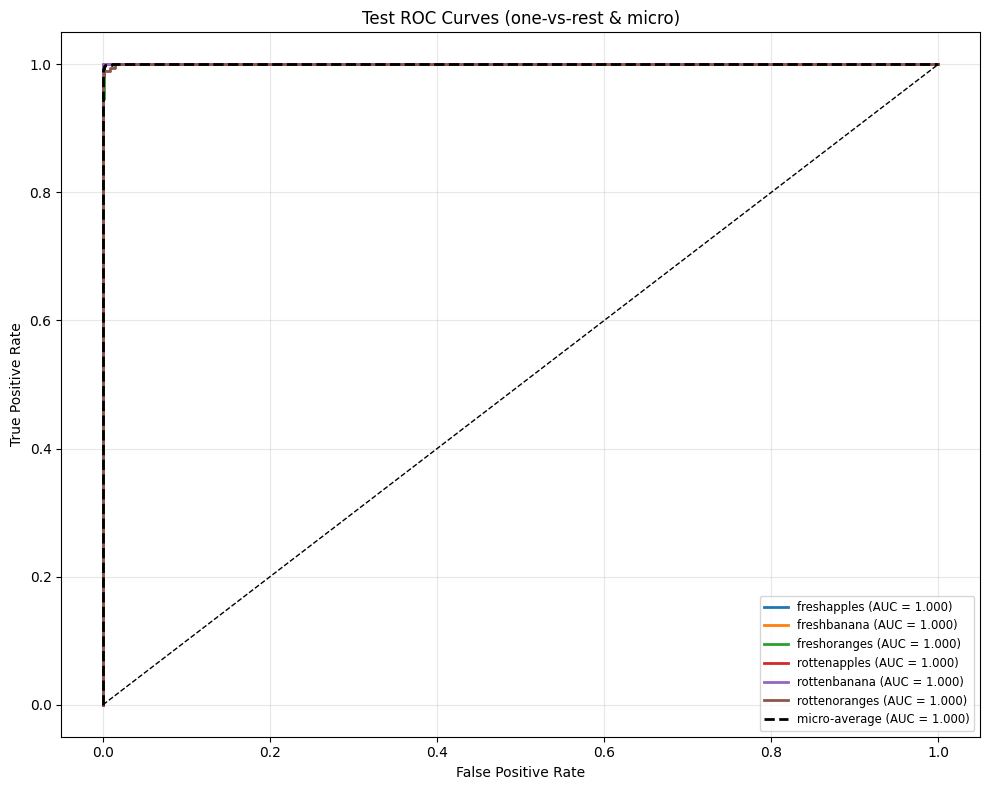

Saved ROC curves to: /kaggle/working/efficientnet_b0_run/eval/test_roc_curves_efficientnet_b0.png


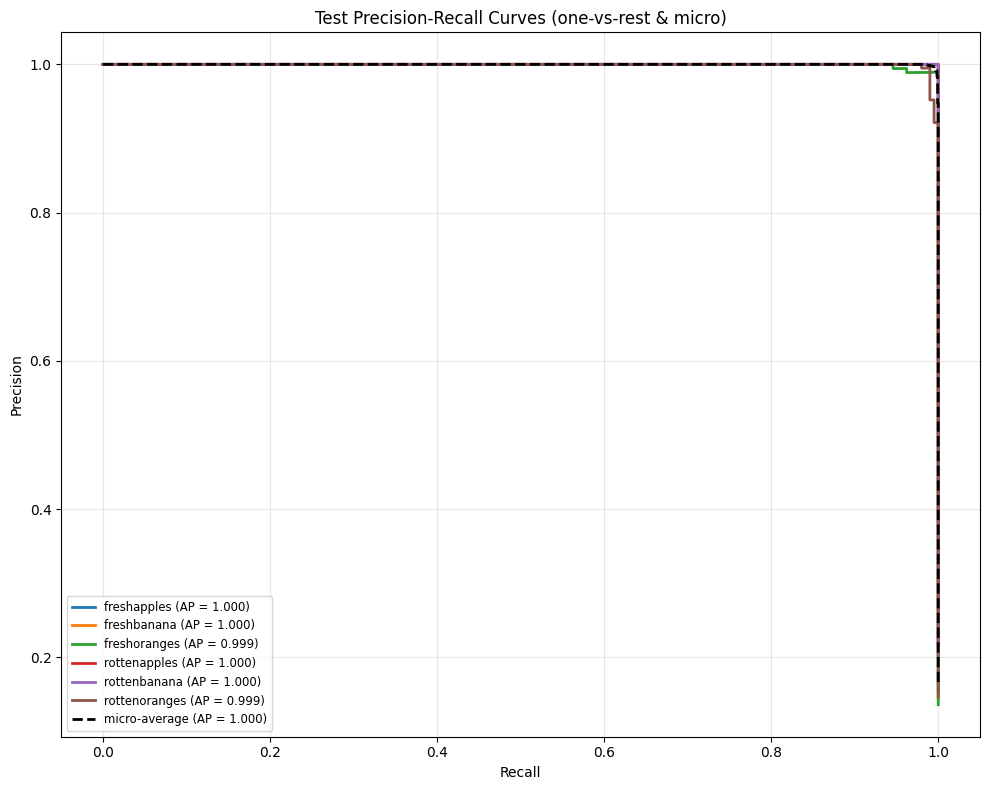

Saved PR curves to: /kaggle/working/efficientnet_b0_run/eval/test_pr_curves_efficientnet_b0.png


        TIME & MEMORY
Total Training Time: 277.37 sec
Average Time per Epoch: 55.47 sec
Max GPU Memory Allocated (GB): 3.065875968
Max GPU Memory Reserved  (GB): 3.598712832
CPU RAM Used (GB): 3.421884416
Inference Time per Image: 10.475 ms

Best checkpoint saved to: /kaggle/working/efficientnet_b0_run/efficientnet_b0_best_singlegpu.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
          Identity-2         [-1, 32, 112, 112]               0
              SiLU-3         [-1, 32, 112, 112]               0
    BatchNormAct2d-4         [-1, 32, 112, 112]              64
            Conv2d-5         [-1, 32, 112, 112]             288
          Identity-6         [-1, 32, 112, 112]               0
              SiLU-7      

In [15]:
import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score
from sklearn.metrics import precision_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
import psutil, joblib

# ---------- USER CONFIG ----------
MODEL_NAME = "efficientnet_b0"
SPLIT_DIR  = "/kaggle/working/split_dataset"   
OUT_DIR    = f"/kaggle/working/{MODEL_NAME}_run"
EVAL_DIR   = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
LABEL_SMOOTHING = 0.1       

IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
BOOTSTRAP_SAMPLES = 500

# reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this cell. Select GPU runtime.")
device = torch.device("cuda")
print("Using device:", device)
torch.backends.cudnn.benchmark = True

# ---- Transforms ----
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.25))
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def gather_pairs(folder):
    items, classes = [], []
    if not os.path.isdir(folder):
        return items, classes
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir): continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                items.append((os.path.join(cls_dir, fn), cls))
    return items, classes

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR   = os.path.join(SPLIT_DIR, "val")
TEST_DIR  = os.path.join(SPLIT_DIR, "test")
if not (os.path.isdir(TRAIN_DIR) and os.path.isdir(VAL_DIR) and os.path.isdir(TEST_DIR)):
    raise RuntimeError(f"split_dataset not found at {SPLIT_DIR}. Run Task-05 and re-run this cell.")

train_items, train_classes = gather_pairs(TRAIN_DIR)
val_items,   val_classes   = gather_pairs(VAL_DIR)
test_items,  test_classes  = gather_pairs(TEST_DIR)
classes = sorted(list(set(train_classes + val_classes + test_classes)))
class_to_idx = {c:i for i,c in enumerate(classes)}

print("Classes detected:", classes)

def _list_files(items):
    return set([os.path.abspath(p) for p,l in items])
train_files = _list_files(train_items); val_files = _list_files(val_items); test_files = _list_files(test_items)
print("Split counts (train,val,test):", len(train_files), len(val_files), len(test_files))
if (train_files & val_files) or (train_files & test_files) or (val_files & test_files):
    raise RuntimeError("DATA LEAKAGE DETECTED: overlapping files between splits. Fix Task-05 first.")

# ---- Dataset wrapper ----
class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        lbl_idx = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl_idx

train_ds = ImagePathDataset(train_items, class_to_idx, transform=train_tfms)
val_ds   = ImagePathDataset(val_items,   class_to_idx, transform=eval_tfms)
test_ds  = ImagePathDataset(test_items,  class_to_idx, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

# ---- Create model ----
def inject_dropout_head(model, p=DROPOUT):
   
    if hasattr(model, "classifier"):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Sequential(nn.Dropout(p), c)
        elif isinstance(c, nn.Sequential):
            model.classifier = nn.Sequential(nn.Dropout(p), *list(c))
    elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Sequential(nn.Dropout(p), model.fc)
    else:
        if hasattr(model, "head") and isinstance(model.head, nn.Linear):
            model.head = nn.Sequential(nn.Dropout(p), model.head)

print("Creating model:", MODEL_NAME)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(classes), drop_rate=DROPOUT)
inject_dropout_head(model, p=DROPOUT)
model = model.to(device)

# ---- optimizer / scheduler / AMP scaler / loss with label smoothing ----
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5, verbose=True)
scaler = GradScaler()

# ---- training loop with early stopping ----
best_val_loss = float("inf")
early_cnt = 0
best_path = os.path.join(OUT_DIR, f"{MODEL_NAME}_best_singlegpu.pth")
os.makedirs(OUT_DIR, exist_ok=True)

epoch_times = []
train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = outputs.argmax(1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    # validation
    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            vloss += loss.item() * imgs.size(0)
            vcorrect += (preds == labels).sum().item()
            vtotal += imgs.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  "
          f"ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={epoch_time:.1f}s")

    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        early_cnt = 0
        torch.save({
            "model": MODEL_NAME,
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_loss": best_val_loss,
            "classes": classes,
            "cfg": {"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "dropout": DROPOUT, "lr": LR,
                    "label_smoothing": LABEL_SMOOTHING}
        }, best_path)
        print(" -> Saved best checkpoint:", best_path)
    else:
        early_cnt += 1
        if early_cnt >= PATIENCE:
            print("Early stopping triggered.")
            break

epochs_run = epoch
total_training_time = time.time() - train_start_time

# ---- evaluation helpers ----
NUM_CLASSES = len(classes)

def get_preds_and_probs(model, loader):
    """Return y_true, y_pred, y_score(probabilities), time_per_image_ms"""
    model.eval()
    ys, ps, scores = [], [], []
    total = 0
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            scores.append(probs)
            ps.extend(preds)
            ys.extend(labels.numpy())
            total += imgs.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed/total)*1000.0 if total>0 else 0.0
    y_score = np.vstack(scores) if len(scores)>0 else np.zeros((len(ys), NUM_CLASSES))
    return np.array(ys), np.array(ps), y_score, time_per_image_ms

def plot_cm(cm, title, savefile):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(savefile, dpi=150); plt.show()

def accuracy_ci(y_true, y_pred, z=1.96):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

# load best weights and evaluate
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt.get("state_dict", ckpt))
    print("Loaded checkpoint:", best_path, "epoch", ckpt.get("epoch", "N/A"))
else:
    print("Best checkpoint not found; using last epoch weights.")
    
print("\n\n======================")
print("        METRICS")
print("======================")

print("\n=== TRAIN REPORT ===")
y_tr, p_tr, yscore_tr, tpi_tr = get_preds_and_probs(model, train_loader)
cm_tr = confusion_matrix(y_tr, p_tr)
print(classification_report(y_tr, p_tr, target_names=classes, digits=4))
plot_cm(cm_tr, "Train CM", os.path.join(EVAL_DIR,"cm_train.png"))

mean_ppv_train = precision_score(y_tr, p_tr, average='macro', zero_division=0)
cohens_kappa_train = cohen_kappa_score(y_tr, p_tr)
try:
    roc_auc_train_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_train_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_train_macro = float('nan'); roc_auc_train_micro = float('nan')
try:
    pr_auc_train_macro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro')
    pr_auc_train_micro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro')
except Exception:
    pr_auc_train_macro = float('nan'); pr_auc_train_micro = float('nan')

acc_tr, lo_tr, hi_tr = accuracy_ci(y_tr, p_tr)
boot_mean_tr, boot_std_tr = 0.0, 0.0
if len(y_tr)>0:
    accs = []
    n = len(y_tr)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_tr[idx] == p_tr[idx]))
    boot_mean_tr, boot_std_tr = float(np.mean(accs)), float(np.std(accs))
    
print(f"Mean PPV (Precision, macro): {mean_ppv_train:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_train:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_train_macro:.4f} / {roc_auc_train_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_train_macro:.4f} / {pr_auc_train_micro:.4f}")
print(f"Inference time per image (train): {tpi_tr:.3f} ms")
print(f"Accuracy: {acc_tr:.4f}  95% CI: [{lo_tr:.4f}, {hi_tr:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_tr:.4f}, Std={boot_std_tr:.4f}")

print("\n=== VAL REPORT ===")
y_v, p_v, yscore_v, tpi_v = get_preds_and_probs(model, val_loader)
cm_v = confusion_matrix(y_v, p_v)
print(classification_report(y_v, p_v, target_names=classes, digits=4))
plot_cm(cm_v, "Val CM", os.path.join(EVAL_DIR,"cm_val.png"))

mean_ppv_val = precision_score(y_v, p_v, average='macro', zero_division=0)
cohens_kappa_val = cohen_kappa_score(y_v, p_v)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(NUM_CLASSES)[y_v], yscore_v, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_v, lo_v, hi_v = accuracy_ci(y_v, p_v)
boot_mean_v, boot_std_v = 0.0, 0.0
if len(y_v)>0:
    accs = []
    n = len(y_v)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_v[idx] == p_v[idx]))
    boot_mean_v, boot_std_v = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (Precision, macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_val:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_val_macro:.4f} / {roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_val_macro:.4f} / {pr_auc_val_micro:.4f}")
print(f"Inference time per image (val): {tpi_v:.3f} ms")
print(f"Accuracy: {acc_v:.4f}  95% CI: [{lo_v:.4f}, {hi_v:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_v:.4f}, Std={boot_std_v:.4f}")

print("\n=== TEST REPORT ===")
y_t, p_t, yscore_t, tpi_t = get_preds_and_probs(model, test_loader)
cm_t = confusion_matrix(y_t, p_t)
print(classification_report(y_t, p_t, target_names=classes, digits=4))
plot_cm(cm_t, "Test CM", os.path.join(EVAL_DIR,"cm_test.png"))

mean_ppv_test = precision_score(y_t, p_t, average='macro', zero_division=0)
cohens_kappa_test = cohen_kappa_score(y_t, p_t)
try:
    roc_auc_test_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro', multi_class='ovr')
    roc_auc_test_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro', multi_class='ovr')
except Exception:
    roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
try:
    pr_auc_test_macro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='macro')
    pr_auc_test_micro = average_precision_score(np.eye(NUM_CLASSES)[y_t], yscore_t, average='micro')
except Exception:
    pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

acc_t, lo_t, hi_t = accuracy_ci(y_t, p_t)
boot_mean_t, boot_std_t = 0.0, 0.0
if len(y_t)>0:
    accs = []
    n = len(y_t)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_t[idx] == p_t[idx]))
    boot_mean_t, boot_std_t = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (Precision, macro): {mean_ppv_test:.4f}")
print(f"Cohen's Kappa: {cohens_kappa_test:.4f}")
print(f"ROC AUC (macro / micro): {roc_auc_test_macro:.4f} / {roc_auc_test_micro:.4f}")
print(f"PR AUC  (macro / micro): {pr_auc_test_macro:.4f} / {pr_auc_test_micro:.4f}")
print(f"Inference time per image (test): {tpi_t:.3f} ms")
print(f"Accuracy: {acc_t:.4f}  95% CI: [{lo_t:.4f}, {hi_t:.4f}]")
print(f"Bootstrap Accuracy Mean={boot_mean_t:.4f}, Std={boot_std_t:.4f}")

# Save evaluation artifacts
artifacts = {
    "train": {"y": y_tr, "p": p_tr, "cm": cm_tr, "y_score": yscore_tr},
    "val":   {"y": y_v, "p": p_v, "cm": cm_v, "y_score": yscore_v},
    "test":  {"y": y_t, "p": p_t, "cm": cm_t, "y_score": yscore_t},
    "classes": classes
}
joblib.dump(artifacts, os.path.join(EVAL_DIR, f"eval_artifacts_{MODEL_NAME}.joblib"))
print("\nSaved evaluation artifacts to:", os.path.join(EVAL_DIR, f"eval_artifacts_{MODEL_NAME}.joblib"))

# === Test ROC and PR curves (multiclass One-vs-Rest + micro-average) ===
if len(y_t) > 0:
    y_true_onehot = np.eye(NUM_CLASSES)[y_t]  

    # ROC curves per class + micro
    plt.figure(figsize=(10, 8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(NUM_CLASSES):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_t[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC = {roc_auc[i]:.3f})")
    # micro-average ROC
    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_t.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    roc_out = os.path.join(EVAL_DIR, f"test_roc_curves_{MODEL_NAME}.png")
    plt.tight_layout(); plt.savefig(roc_out, dpi=150); plt.show()
    print("Saved ROC curves to:", roc_out)

    # Precision-Recall curves per class + micro-average
    plt.figure(figsize=(10, 8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(NUM_CLASSES):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_t[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_t[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"{classes[i]} (AP = {ap[i]:.3f})")
  
    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_t.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_t, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro-average (AP = {ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    pr_out = os.path.join(EVAL_DIR, f"test_pr_curves_{MODEL_NAME}.png")
    plt.tight_layout(); plt.savefig(pr_out, dpi=150); plt.show()
    print("Saved PR curves to:", pr_out)

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epochs_run:.2f} sec")

if torch.cuda.is_available():
    try:
        print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        print("Could not query CUDA memory stats via torch.cuda.")

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference time probe
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0 = time.time()
    _ = model(sample)
    if device.type == 'cuda': torch.cuda.synchronize()
    infer_time = time.time() - t0
print(f"Inference Time per Image: {infer_time*1000:.3f} ms")

print("\nBest checkpoint saved to:", best_path)
print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))
    import pandas as pd
    df = pd.DataFrame(rows, columns=['name','shape','n_params','trainable'])
    display(df.head(200))

print("\nAll done — Task 9, 10, 11 completed for", MODEL_NAME, ". Evaluation saved to:", EVAL_DIR)

# **Tiny_vit_5m_224 Model Training**

Device: cuda
Using on-disk split at /kaggle/working/split_dataset
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Split counts (train,val,test): 10879 1360 1360
Creating model: tiny_vit_5m_224 num_classes: 6


model.safetensors:   0%|          | 0.00/48.4M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_47/1533222458.py:180: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_47/1533222458.py:198: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/40  TrainLoss=1.08992 TrainAcc=0.6517  ValLoss=1.53758 ValAcc=0.5338  epoch_time=57.1s
 -> Saved best checkpoint: /kaggle/working/tiny_vit_5m_224_run/tiny_vit_5m_224_best_singlegpu.pth
Epoch 2/40  TrainLoss=0.58868 TrainAcc=0.9243  ValLoss=1.41597 ValAcc=0.6206  epoch_time=57.2s
 -> Saved best checkpoint: /kaggle/working/tiny_vit_5m_224_run/tiny_vit_5m_224_best_singlegpu.pth
Epoch 3/40  TrainLoss=0.53526 TrainAcc=0.9456  ValLoss=0.94666 ValAcc=0.7868  epoch_time=57.3s
 -> Saved best checkpoint: /kaggle/working/tiny_vit_5m_224_run/tiny_vit_5m_224_best_singlegpu.pth
Epoch 4/40  TrainLoss=0.50327 TrainAcc=0.9614  ValLoss=0.87808 ValAcc=0.8103  epoch_time=57.3s
 -> Saved best checkpoint: /kaggle/working/tiny_vit_5m_224_run/tiny_vit_5m_224_best_singlegpu.pth
Epoch 5/40  TrainLoss=0.49295 TrainAcc=0.9679  ValLoss=0.99362 ValAcc=0.8007  epoch_time=56.7s
Epoch 6/40  TrainLoss=0.48115 TrainAcc=0.9721  ValLoss=0.63998 ValAcc=0.9118  epoch_time=56.6s
 -> Saved best checkpoint: /kaggle/wor

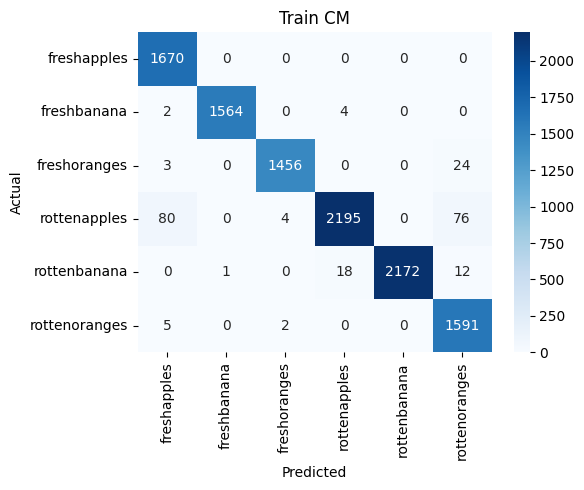

Mean PPV (macro): 0.9781
Cohen's Kappa: 0.9744
ROC AUC (macro/micro): 0.9994/0.9989
PR AUC  (macro/micro): 0.9971/0.9958
Inference time per image (train): 4.354 ms
Accuracy: 0.9788 95% CI: [0.9761, 0.9815]
Bootstrap Accuracy mean/std: 0.9788/0.0014

=== VAL REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9858    1.0000    0.9929       209
  freshbanana     1.0000    1.0000    1.0000       196
 freshoranges     1.0000    0.9892    0.9946       186
 rottenapples     0.9965    0.9762    0.9863       294
 rottenbanana     1.0000    0.9964    0.9982       275
rottenoranges     0.9709    1.0000    0.9852       200

     accuracy                         0.9926      1360
    macro avg     0.9922    0.9936    0.9929      1360
 weighted avg     0.9928    0.9926    0.9927      1360



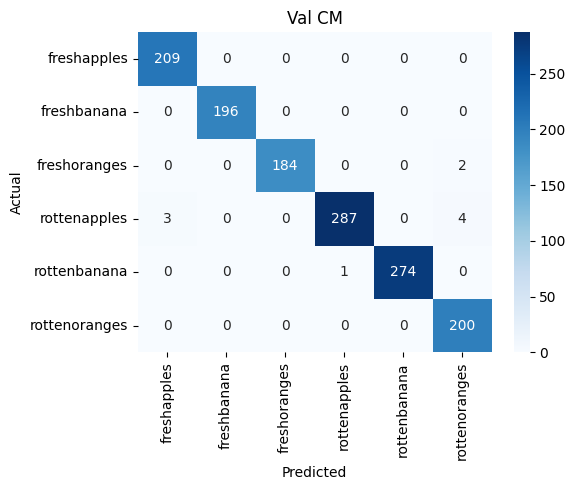

Mean PPV (macro): 0.9922
Cohen's Kappa: 0.9911
ROC AUC (macro/micro): 1.0000/1.0000
PR AUC  (macro/micro): 0.9999/0.9998
Inference time per image (val): 2.740 ms
Accuracy: 0.9926 95% CI: [0.9881, 0.9972]
Bootstrap Accuracy mean/std: 0.9927/0.0025

=== TEST REPORT ===
               precision    recall  f1-score   support

  freshapples     0.9858    1.0000    0.9929       209
  freshbanana     0.9949    0.9898    0.9923       196
 freshoranges     1.0000    0.9946    0.9973       185
 rottenapples     0.9932    0.9864    0.9898       294
 rottenbanana     1.0000    0.9964    0.9982       276
rottenoranges     0.9901    1.0000    0.9950       200

     accuracy                         0.9941      1360
    macro avg     0.9940    0.9945    0.9942      1360
 weighted avg     0.9941    0.9941    0.9941      1360



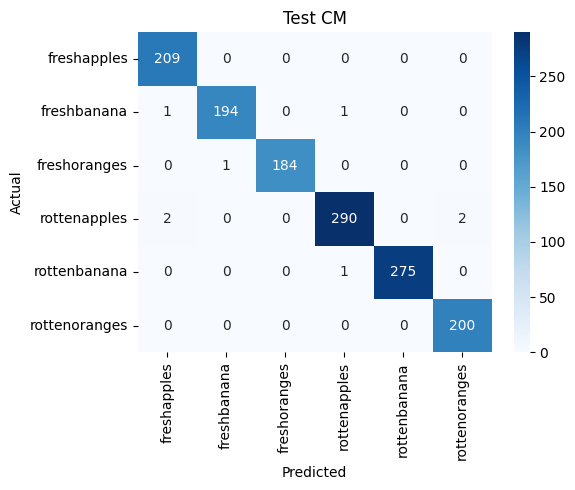

Mean PPV (macro): 0.9940
Cohen's Kappa: 0.9929
ROC AUC (macro/micro): 1.0000/1.0000
PR AUC  (macro/micro): 0.9999/0.9999
Inference time per image (test): 2.903 ms
Accuracy: 0.9941 95% CI: [0.9901, 0.9982]
Bootstrap Accuracy mean/std: 0.9942/0.0022

Saved evaluation artifacts to: /kaggle/working/tiny_vit_5m_224_run/eval/eval_artifacts_tiny_vit_5m_224.joblib


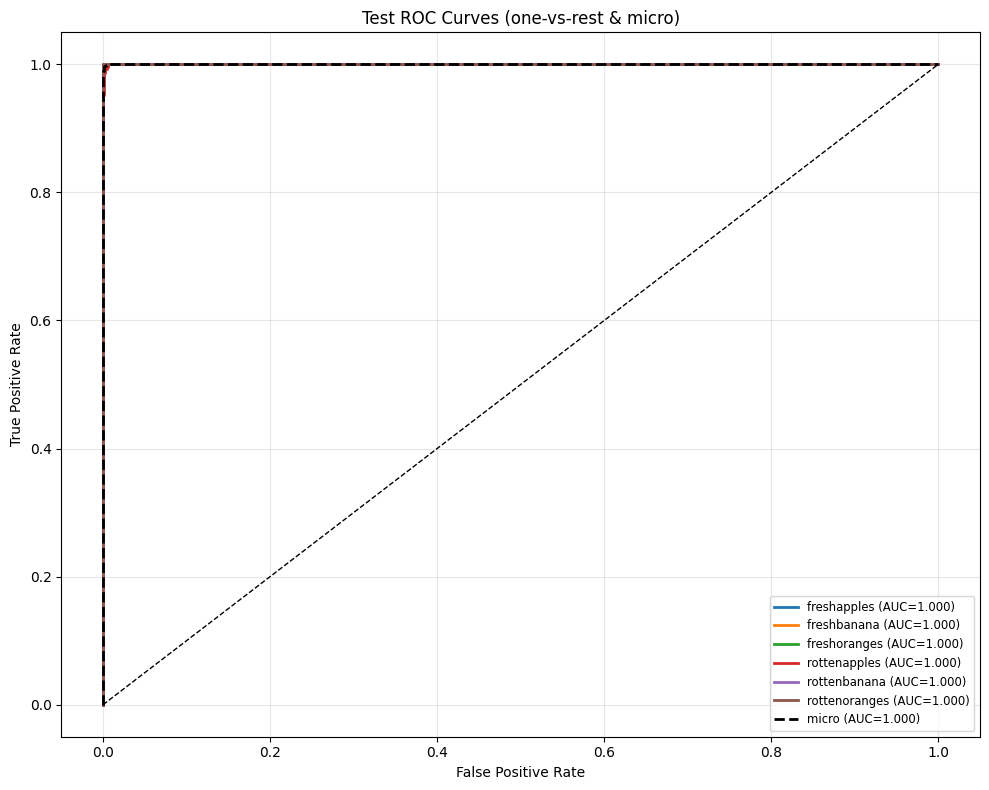

Saved ROC curves to: /kaggle/working/tiny_vit_5m_224_run/eval/test_roc_tiny_vit_5m_224.png


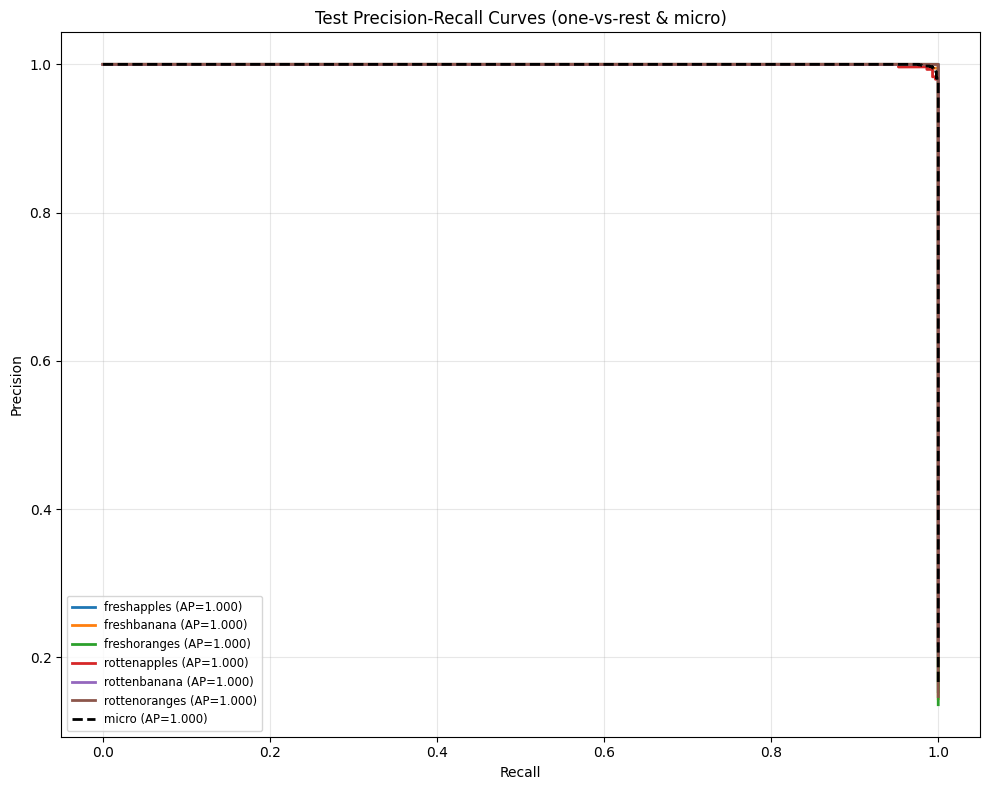

Saved PR curves to: /kaggle/working/tiny_vit_5m_224_run/eval/test_pr_tiny_vit_5m_224.png


        TIME & MEMORY
Total Training Time: 1007.02 sec
Average Time per Epoch: 55.95 sec
Max GPU Memory Allocated (GB): 3.25809664
Max GPU Memory Reserved  (GB): 3.896508416
CPU RAM Used (GB): 3.45360384
Inference Time per Image: 36.841 ms

Best checkpoint saved to: /kaggle/working/tiny_vit_5m_224_run/tiny_vit_5m_224_best_singlegpu.pth


        MODEL SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              GELU-3         [-1, 32, 112, 112]               0
            Conv2d-4           [-1, 64, 56, 56]          18,432
       BatchNorm2d-5           [-1, 64, 56, 56]             128
        PatchEmbed-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1,

In [16]:
import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch, torch.nn as nn, torch.optim as optim_SD
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef, cohen_kappa_score
from sklearn.metrics import precision_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
import psutil, joblib, pandas as pd

# ---------- USER CONFIG ----------
MODEL_NAME = "tiny_vit_5m_224"
SPLIT_DIR  = "/kaggle/working/split_dataset"   
OUT_DIR    = f"/kaggle/working/{MODEL_NAME}_run"
EVAL_DIR   = os.path.join(OUT_DIR, "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
SEED = 42
NUM_EPOCHS = 40
PATIENCE = 3
LR = 3e-4                 
WEIGHT_DECAY = 1e-4
DROPOUT = 0.5
LABEL_SMOOTHING = 0.1

IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
BOOTSTRAP_SAMPLES = 500

# reproducibility & device
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for this cell. Make sure a GPU runtime is selected.")
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print("Device:", device)

# ---- Transforms ----
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02,0.25))
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def gather_pairs(folder):
    items, classes = [], []
    if not os.path.isdir(folder):
        return items, classes
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir): continue
        classes.append(cls)
        for fn in sorted(os.listdir(cls_dir)):
            if fn.lower().endswith(IMG_EXTS):
                items.append((os.path.join(cls_dir, fn), cls))
    return items, classes

if os.path.isdir(os.path.join(SPLIT_DIR, "train")):
    print("Using on-disk split at", SPLIT_DIR)
    train_items, train_classes = gather_pairs(os.path.join(SPLIT_DIR,"train"))
    val_items, val_classes     = gather_pairs(os.path.join(SPLIT_DIR,"val"))
    test_items, test_classes   = gather_pairs(os.path.join(SPLIT_DIR,"test"))
    classes = sorted(list(set(train_classes + val_classes + test_classes)))
    class_to_idx = {c:i for i,c in enumerate(classes)}
else:
   
    BASE_DIR = "/kaggle/input/fruits-fresh-and-rotten-for-classification/dataset"
    print("split_dataset not found — building deterministic 80/10/10 from", BASE_DIR)
    all_items = []
    all_classes = set()
    for cand in (BASE_DIR, os.path.join(BASE_DIR,"train"), os.path.join(BASE_DIR,"test")):
        if not os.path.isdir(cand): continue
        for cls in sorted(os.listdir(cand)):
            cls_dir = os.path.join(cand, cls)
            if not os.path.isdir(cls_dir): continue
            for fn in sorted(os.listdir(cls_dir)):
                if fn.lower().endswith(IMG_EXTS):
                    all_items.append((os.path.join(cls_dir, fn), cls))
                    all_classes.add(cls)
    if len(all_items) == 0:
        raise RuntimeError("No images found under dataset base path.")
    classes = sorted(list(all_classes))
    class_to_idx = {c:i for i,c in enumerate(classes)}
    rnd = random.Random(SEED)
    rnd.shuffle(all_items)
    N = len(all_items)
    n_train = int(0.80 * N)
    n_val = int(0.10 * N)
    train_items = all_items[:n_train]
    val_items   = all_items[n_train:n_train+n_val]
    test_items  = all_items[n_train+n_val:]
    print(f"Combined total images: {N} -> train {len(train_items)}, val {len(val_items)}, test {len(test_items)}")

total_images = len(train_items) + len(val_items) + len(test_items)
print("Classes:", classes)
print("Split counts (train,val,test):", len(train_items), len(val_items), len(test_items))

def _file_set(items): return set([os.path.abspath(p) for p,l in items])
tset, vset, teset = _file_set(train_items), _file_set(val_items), _file_set(test_items)
if (tset & vset) or (tset & teset) or (vset & teset):
    raise RuntimeError("DATA LEAKAGE DETECTED between splits — fix Task-05 split and retry.")

# ---- Dataset wrapper ----
class ImagePathDataset(Dataset):
    def __init__(self, items, class_to_idx, transform=None):
        self.items = list(items)
        self.transform = transform
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p, lbl = self.items[idx]
        if isinstance(lbl, str):
            lbl = self.class_to_idx[lbl]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, lbl

train_ds = ImagePathDataset(train_items, class_to_idx, transform=train_tfms)
val_ds   = ImagePathDataset(val_items,   class_to_idx, transform=eval_tfms)
test_ds  = ImagePathDataset(test_items,  class_to_idx, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

# ---- Build model ----
def inject_dropout_head(model, p=DROPOUT):
    # many timm ViT-like architectures expose .head, .classifier or .fc
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Sequential(nn.Dropout(p), model.head)
    elif hasattr(model, "classifier"):
        c = model.classifier
        if isinstance(c, nn.Linear):
            model.classifier = nn.Sequential(nn.Dropout(p), c)
        elif isinstance(c, nn.Sequential):
            model.classifier = nn.Sequential(nn.Dropout(p), *list(c))
    elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc = nn.Sequential(nn.Dropout(p), model.fc)
    else:
     
        pass

NUM_CLASSES = len(classes)
print("Creating model:", MODEL_NAME, "num_classes:", NUM_CLASSES)
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES, drop_rate=DROPOUT)
inject_dropout_head(model, p=DROPOUT)
model = model.to(device)

# ---- optimizer / scheduler / loss / scaler ----
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5, verbose=True)
scaler = GradScaler()

# ---- Training loop ----
best_val_loss = float("inf")
early_cnt = 0
best_path = os.path.join(OUT_DIR, f"{MODEL_NAME}_best_singlegpu.pth")
os.makedirs(OUT_DIR, exist_ok=True)

epoch_times = []
train_start_time = time.time()
for epoch in range(1, NUM_EPOCHS+1):
    t0 = time.time()
    model.train()
    running_loss = 0.0; running_correct = 0; total = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = outputs.argmax(1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        total += imgs.size(0)

    train_loss = running_loss / (total if total>0 else 1)
    train_acc = running_correct / (total if total>0 else 1)

    # validation
    model.eval()
    vloss = 0.0; vcorrect = 0; vtotal = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(1)
            vloss += loss.item() * imgs.size(0)
            vcorrect += (preds == labels).sum().item()
            vtotal += imgs.size(0)
    val_loss = vloss / (vtotal if vtotal>0 else 1)
    val_acc = vcorrect / (vtotal if vtotal>0 else 1)

    scheduler.step(val_loss)
    epoch_time = time.time() - t0
    epoch_times.append(epoch_time)
    print(f"Epoch {epoch}/{NUM_EPOCHS}  TrainLoss={train_loss:.5f} TrainAcc={train_acc:.4f}  "
          f"ValLoss={val_loss:.5f} ValAcc={val_acc:.4f}  epoch_time={epoch_time:.1f}s")

    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        early_cnt = 0
        torch.save({
            "model": MODEL_NAME,
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "val_loss": best_val_loss,
            "classes": classes,
            "cfg": {"img_size": IMG_SIZE, "batch_size": BATCH_SIZE, "dropout": DROPOUT, "lr": LR}
        }, best_path)
        print(" -> Saved best checkpoint:", best_path)
    else:
        early_cnt += 1
        if early_cnt >= PATIENCE:
            print("Early stopping triggered.")
            break

epochs_run = epoch
total_training_time = time.time() - train_start_time

# ---- Evaluation helpers ----
def get_preds_and_probs(model, loader):
    """Return y_true, y_pred, y_score(probabilities), time_per_image_ms"""
    model.eval()
    ys, ps, scores = [], [], []
    total = 0
    t0 = time.time()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            scores.append(probs)
            ps.extend(preds)
            ys.extend(labels.numpy())
            total += imgs.size(0)
    t_elapsed = time.time() - t0
    time_per_image_ms = (t_elapsed/total)*1000.0 if total>0 else 0.0
    y_score = np.vstack(scores) if len(scores)>0 else np.zeros((len(ys), NUM_CLASSES))
    return np.array(ys), np.array(ps), y_score, time_per_image_ms

def plot_cm(cm, title, savefile):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.savefig(savefile, dpi=150); plt.show()

def accuracy_ci(y_true, y_pred, z=1.96):
    n = len(y_true)
    if n == 0:
        return 0.0, 0.0, 0.0
    acc = np.mean(y_true == y_pred)
    se = np.sqrt(acc*(1-acc)/n)
    lower = max(0.0, acc - z*se)
    upper = min(1.0, acc + z*se)
    return acc, lower, upper

# load best weights and evaluate
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt.get("state_dict", ckpt))
    print("Loaded checkpoint:", best_path, "epoch", ckpt.get("epoch", "N/A"))
else:
    print("Best checkpoint not found; using last epoch weights.")

print("\n\n======================")
print("        METRICS")
print("======================")

print("\n=== TRAIN REPORT ===")
y_tr, p_tr, yscore_tr, tpi_tr = get_preds_and_probs(model, train_loader)
cm_tr = confusion_matrix(y_tr, p_tr)
print(classification_report(y_tr, p_tr, target_names=classes, digits=4))
plot_cm(cm_tr, "Train CM", os.path.join(EVAL_DIR,"cm_train.png"))

mean_ppv_tr = precision_score(y_tr, p_tr, average='macro', zero_division=0)
kappa_tr = cohen_kappa_score(y_tr, p_tr)
try:
    roc_auc_tr_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro', multi_class='ovr')
    roc_auc_tr_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro', multi_class='ovr')
except Exception:
    roc_auc_tr_macro = float('nan'); roc_auc_tr_micro = float('nan')
try:
    pr_auc_tr_macro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='macro')
    pr_auc_tr_micro = average_precision_score(np.eye(NUM_CLASSES)[y_tr], yscore_tr, average='micro')
except Exception:
    pr_auc_tr_macro = float('nan'); pr_auc_tr_micro = float('nan')

acc_tr, lo_tr, hi_tr = accuracy_ci(y_tr, p_tr)
boot_mean_tr, boot_std_tr = 0.0, 0.0
if len(y_tr) > 0:
    accs = []
    n = len(y_tr)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_tr[idx] == p_tr[idx]))
    boot_mean_tr, boot_std_tr = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_tr:.4f}")
print(f"Cohen's Kappa: {kappa_tr:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_tr_macro:.4f}/{roc_auc_tr_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_tr_macro:.4f}/{pr_auc_tr_micro:.4f}")
print(f"Inference time per image (train): {tpi_tr:.3f} ms")
print(f"Accuracy: {acc_tr:.4f} 95% CI: [{lo_tr:.4f}, {hi_tr:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_tr:.4f}/{boot_std_tr:.4f}")

print("\n=== VAL REPORT ===")
y_val, p_val, yscore_val, tpi_val = get_preds_and_probs(model, val_loader)
cm_val = confusion_matrix(y_val, p_val)
print(classification_report(y_val, p_val, target_names=classes, digits=4))
plot_cm(cm_val, "Val CM", os.path.join(EVAL_DIR,"cm_val.png"))

mean_ppv_val = precision_score(y_val, p_val, average='macro', zero_division=0)
kappa_val = cohen_kappa_score(y_val, p_val)
try:
    roc_auc_val_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='macro', multi_class='ovr')
    roc_auc_val_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='micro', multi_class='ovr')
except Exception:
    roc_auc_val_macro = float('nan'); roc_auc_val_micro = float('nan')
try:
    pr_auc_val_macro = average_precision_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='macro')
    pr_auc_val_micro = average_precision_score(np.eye(NUM_CLASSES)[y_val], yscore_val, average='micro')
except Exception:
    pr_auc_val_macro = float('nan'); pr_auc_val_micro = float('nan')

acc_val, lo_val, hi_val = accuracy_ci(y_val, p_val)
boot_mean_val, boot_std_val = 0.0, 0.0
if len(y_val) > 0:
    accs = []
    n = len(y_val)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_val[idx] == p_val[idx]))
    boot_mean_val, boot_std_val = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_val:.4f}")
print(f"Cohen's Kappa: {kappa_val:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_val_macro:.4f}/{roc_auc_val_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_val_macro:.4f}/{pr_auc_val_micro:.4f}")
print(f"Inference time per image (val): {tpi_val:.3f} ms")
print(f"Accuracy: {acc_val:.4f} 95% CI: [{lo_val:.4f}, {hi_val:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_val:.4f}/{boot_std_val:.4f}")

print("\n=== TEST REPORT ===")
y_test, p_test, yscore_test, tpi_test = get_preds_and_probs(model, test_loader)
cm_test = confusion_matrix(y_test, p_test)
print(classification_report(y_test, p_test, target_names=classes, digits=4))
plot_cm(cm_test, "Test CM", os.path.join(EVAL_DIR,"cm_test.png"))

mean_ppv_test = precision_score(y_test, p_test, average='macro', zero_division=0)
kappa_test = cohen_kappa_score(y_test, p_test)
try:
    roc_auc_test_macro = roc_auc_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='macro', multi_class='ovr')
    roc_auc_test_micro = roc_auc_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='micro', multi_class='ovr')
except Exception:
    roc_auc_test_macro = float('nan'); roc_auc_test_micro = float('nan')
try:
    pr_auc_test_macro = average_precision_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='macro')
    pr_auc_test_micro = average_precision_score(np.eye(NUM_CLASSES)[y_test], yscore_test, average='micro')
except Exception:
    pr_auc_test_macro = float('nan'); pr_auc_test_micro = float('nan')

acc_test, lo_test, hi_test = accuracy_ci(y_test, p_test)
boot_mean_test, boot_std_test = 0.0, 0.0
if len(y_test) > 0:
    accs = []
    n = len(y_test)
    for _ in range(min(BOOTSTRAP_SAMPLES, 200)):
        idx = np.random.randint(0, n, n)
        accs.append(np.mean(y_test[idx] == p_test[idx]))
    boot_mean_test, boot_std_test = float(np.mean(accs)), float(np.std(accs))

print(f"Mean PPV (macro): {mean_ppv_test:.4f}")
print(f"Cohen's Kappa: {kappa_test:.4f}")
print(f"ROC AUC (macro/micro): {roc_auc_test_macro:.4f}/{roc_auc_test_micro:.4f}")
print(f"PR AUC  (macro/micro): {pr_auc_test_macro:.4f}/{pr_auc_test_micro:.4f}")
print(f"Inference time per image (test): {tpi_test:.3f} ms")
print(f"Accuracy: {acc_test:.4f} 95% CI: [{lo_test:.4f}, {hi_test:.4f}]")
print(f"Bootstrap Accuracy mean/std: {boot_mean_test:.4f}/{boot_std_test:.4f}")

artifacts = {
    "train": {"y": y_tr, "p": p_tr, "cm": cm_tr, "y_score": yscore_tr},
    "val":   {"y": y_val, "p": p_val, "cm": cm_val, "y_score": yscore_val},
    "test":  {"y": y_test, "p": p_test, "cm": cm_test, "y_score": yscore_test},
    "classes": classes
}
joblib.dump(artifacts, os.path.join(EVAL_DIR, f"eval_artifacts_{MODEL_NAME}.joblib"))
print("\nSaved evaluation artifacts to:", os.path.join(EVAL_DIR, f"eval_artifacts_{MODEL_NAME}.joblib"))

# === Test ROC and PR curves (multiclass One-vs-Rest + micro-average) ===
if len(y_test) > 0:
    y_true_onehot = np.eye(NUM_CLASSES)[y_test]

    plt.figure(figsize=(10,8))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(NUM_CLASSES):
        try:
            fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], yscore_test[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        except Exception:
            fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), float('nan')
        plt.plot(fpr[i], tpr[i], lw=2, label=f"{classes[i]} (AUC={roc_auc[i]:.3f})")
    try:
        fpr["micro"], tpr["micro"], _ = roc_curve(y_true_onehot.ravel(), yscore_test.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        plt.plot(fpr["micro"], tpr["micro"], color='k', lw=2, linestyle='--', label=f"micro (AUC={roc_auc['micro']:.3f})")
    except Exception:
        pass
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Test ROC Curves (one-vs-rest & micro)")
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(alpha=0.3)
    roc_path = os.path.join(EVAL_DIR, f"test_roc_{MODEL_NAME}.png")
    plt.tight_layout(); plt.savefig(roc_path, dpi=150); plt.show()
    print("Saved ROC curves to:", roc_path)

    plt.figure(figsize=(10,8))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(NUM_CLASSES):
        try:
            precision[i], recall[i], _ = precision_recall_curve(y_true_onehot[:, i], yscore_test[:, i])
            ap[i] = average_precision_score(y_true_onehot[:, i], yscore_test[:, i])
        except Exception:
            precision[i], recall[i], ap[i] = np.array([0,1]), np.array([1,0]), float('nan')
        plt.plot(recall[i], precision[i], lw=2, label=f"{classes[i]} (AP={ap[i]:.3f})")
    try:
        precision["micro"], recall["micro"], _ = precision_recall_curve(y_true_onehot.ravel(), yscore_test.ravel())
        ap["micro"] = average_precision_score(y_true_onehot, yscore_test, average='micro')
        plt.plot(recall["micro"], precision["micro"], color='k', lw=2, linestyle='--', label=f"micro (AP={ap['micro']:.3f})")
    except Exception:
        pass
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Test Precision-Recall Curves (one-vs-rest & micro)")
    plt.legend(loc='lower left', fontsize='small')
    plt.grid(alpha=0.3)
    pr_path = os.path.join(EVAL_DIR, f"test_pr_{MODEL_NAME}.png")
    plt.tight_layout(); plt.savefig(pr_path, dpi=150); plt.show()
    print("Saved PR curves to:", pr_path)

print("\n\n============================")
print("        TIME & MEMORY")
print("============================")

print(f"Total Training Time: {total_training_time:.2f} sec")
print(f"Average Time per Epoch: {total_training_time/epochs_run:.2f} sec")

if torch.cuda.is_available():
    try:
        print("Max GPU Memory Allocated (GB):", torch.cuda.max_memory_allocated() / 1e9)
        print("Max GPU Memory Reserved  (GB):", torch.cuda.max_memory_reserved() / 1e9)
    except Exception:
        print("Could not query CUDA memory stats via torch.cuda.")

print("CPU RAM Used (GB):", psutil.Process(os.getpid()).memory_info().rss / 1e9)

# Inference time probe
model.eval()
with torch.no_grad():
    sample = torch.randn(1,3,IMG_SIZE,IMG_SIZE).to(device)
    t0 = time.time()
    _ = model(sample)
    if device.type == 'cuda': torch.cuda.synchronize()
    infer_time = time.time() - t0
print(f"Inference Time per Image: {infer_time*1000:.3f} ms")

print("\nBest checkpoint saved to:", best_path)

print("\n\n============================")
print("        MODEL SUMMARY")
print("============================")
try:
    from torchsummary import summary
    summary(model, (3, IMG_SIZE, IMG_SIZE))
except Exception:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    rows = []
    for name, param in model.named_parameters():
        rows.append((name, tuple(param.shape), param.numel(), param.requires_grad))
    df = pd.DataFrame(rows, columns=['name','shape','n_params','trainable'])
    display(df.head(200))

# **Cross Validation for Best Model (Resnet34)**

In [9]:
import os, time, random, json
from pathlib import Path
from collections import defaultdict
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
from PIL import Image

# ---------------- CONFIG ----------------
MODEL_NAME = "resnet34"
SPLIT_DIR = "/kaggle/working/split_dataset"
OUT_DIR = "/kaggle/working/resnet34_cv_clean"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4
NUM_EPOCHS = 40
PATIENCE = 3
SEED = 42
LR = 3e-4
WD = 1e-4
DROPOUT = 0.5
IMG_EXTS = ('.jpg','.jpeg','.png','.bmp','.tif','.tiff')
N_SPLITS = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda': torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ----------------------------------------------------
# DATA TRANSFORMS
# ----------------------------------------------------
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------
# LOAD SPLIT DATA 
# -------------------
def gather(root):
    items, classes = [], []
    if not os.path.isdir(root): return items, classes
    for c in sorted(os.listdir(root)):
        cdir = os.path.join(root,c)
        if not os.path.isdir(cdir): continue
        classes.append(c)
        for fn in os.listdir(cdir):
            if fn.lower().endswith(IMG_EXTS):
                items.append((os.path.join(cdir,fn), c))
    return items, classes

all_items, all_cls = [], []
for s in ("train","val","test"):
    p = os.path.join(SPLIT_DIR, s)
    items, cls = gather(p)
    all_items.extend(items)
    all_cls.extend(cls)

classes = sorted(list(set(all_cls)))
class_to_idx = {c:i for i,c in enumerate(classes)}
labels_all = np.array([class_to_idx[c] for _,c in all_items])

print(f"Total images: {len(all_items)}, Classes={classes}")

# ----------------------------------------------------
# DATASET CLASS
# ----------------------------------------------------
class ImageSet(Dataset):
    def __init__(self, items, class_to_idx, tfm):
        self.items = items
        self.tfm = tfm
        self.class_to_idx = class_to_idx
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        path, lbl = self.items[idx]
        img = Image.open(path).convert("RGB")
        return self.tfm(img), self.class_to_idx[lbl]

# ----------------------------------------------------
# TRAINING FUNCTION
# ----------------------------------------------------
def train_one_fold(model, train_loader, val_loader):

    criterion = nn.CrossEntropyLoss()
    optimz = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_loss = float("inf")
    patience = 0
    best_state = None

    for ep in range(1, NUM_EPOCHS+1):

        model.train()
        for x,y in train_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            optimz.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimz.step()

        # VAL
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            patience = 0
        else:
            patience += 1
            if patience >= PATIENCE:
                break

    return best_state


# ----------------------------------------------------
# STRATIFIED 5-FOLD CV
# ----------------------------------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_metrics = defaultdict(list)

fold_no = 0
for train_idx, val_idx in skf.split(np.zeros(len(labels_all)), labels_all):
    fold_no += 1
    print(f"\n========== Fold {fold_no} ==========")

    train_items = [all_items[i] for i in train_idx]
    val_items   = [all_items[i] for i in val_idx]

    train_loader = DataLoader(
        ImageSet(train_items, class_to_idx, train_tf),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    val_loader = DataLoader(
        ImageSet(val_items, class_to_idx, eval_tf),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

 
    weights = models.ResNet34_Weights.IMAGENET1K_V1 
    model = models.resnet34(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(DROPOUT),
        nn.Linear(in_features, len(classes))
    )
    model = model.to(DEVICE)

    # train
    best_state = train_one_fold(model, train_loader, val_loader)
    model.load_state_dict(best_state)
    model.eval()

    # metrics
    y_true, y_pred = [], []
    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(DEVICE)
            out = model(x)
            preds = out.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(y.numpy())

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Fold {fold_no} - Acc: {acc:.4f}, Prec: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    fold_metrics["accuracy"].append(acc)
    fold_metrics["precision"].append(prec)
    fold_metrics["recall"].append(rec)
    fold_metrics["f1"].append(f1)

# ----------------------------------------------------
# SUMMARY
# ----------------------------------------------------
print("\n===== Cross-Validation Results =====")
for metric, vals in fold_metrics.items():
    mean, std = np.mean(vals), np.std(vals)
    print(f"{metric.capitalize()}: {mean:.4f} ± {std:.4f}")


Device: cuda
Total images: 13599, Classes=['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']

========== Fold 1 ==========
Fold 1 - Acc: 0.9904, Prec: 0.9916, Recall: 0.9906, F1: 0.9911

========== Fold 2 ==========
Fold 2 - Acc: 0.9996, Prec: 0.9996, Recall: 0.9997, F1: 0.9997

========== Fold 3 ==========
Fold 3 - Acc: 0.9915, Prec: 0.9920, Recall: 0.9910, F1: 0.9914

========== Fold 4 ==========
Fold 4 - Acc: 0.9996, Prec: 0.9997, Recall: 0.9996, F1: 0.9997

========== Fold 5 ==========
Fold 5 - Acc: 0.9993, Prec: 0.9994, Recall: 0.9994, F1: 0.9994

===== Cross-Validation Results =====
Accuracy: 0.9961 ± 0.0042
Precision: 0.9965 ± 0.0038
Recall: 0.9961 ± 0.0043
F1: 0.9962 ± 0.0041
